# Sionna 0.19 — Main Ray Tracing Simulation

**Kernel:** `sionna019` · Python 3.10 · Sionna 0.19.2 · TensorFlow 2.15

**City:** Nottingham, UK · 800 MHz · TX: Mast at city centre

**Scene:** OSM-derived 3D mesh (~5 km radius) · ITU-R P.2040-2 materials · LambertianPattern scattering

**Receivers:** 4000 Ofcom drive-test points (0–5 km from TX) from `nottingham3602.csv`
IDs: `RX_XXXXXX` = original CSV row number for traceability

**GPU:** Tesla V100-SXM2-16GB · `cuda_ad_rgb` · `FORCE_CPU_RT=False`

**Key parameters:**
- `NUM_SAMPLES_CM = 100M` rays (10 × 10M runs)
- `NUM_SAMPLES_PS = 4M` base / `10M` cap · `MAX_DEPTH = 12`
- `BATCH_SIZE = 20` receivers per path-solver call
- `NOISE_FLOOR = -115 dBm` · `EIRP = 54 dBm` · `SYS_GAIN = 16 dB`

**Run order:** CELL 0 → 0b → 0c → 1 → 2 → 3 [→ 3b optional] → 4 → 5 → 6 → 6b → 6c → 7 → 8 → 9 → 9b → 9c → 9d → 9e → 9f → 10+

## CELL 0 · Environment Setup & GPU Configuration

Imports, GPU/CUDA setup, Mitsuba variant selection, and DLPack fix.

**What's set here:**
- `FORCE_CPU_RT=False` → GPU mode (`cuda_ad_rgb`)
- `set_memory_growth` only — no `VirtualDeviceConfiguration` (fixes DLPack GPU index crash)
- `CUDA_VISIBLE_DEVICES=''` only when `FORCE_CPU_RT=True`

In [1]:
import os, sys

import sys, json, csv, time, warnings, glob, re

# ── CPU/GPU mode — must be set before TF and Mitsuba imports ─────────────────
FORCE_CPU_RT = False  # False = GPU (cuda_ad_rgb); True = CPU (llvm_ad_rgb)
import xml.etree.ElementTree as ET
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib; matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 100})
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy import stats
from scipy.stats import spearmanr
from scipy.constants import speed_of_light as C
from pyproj import Transformer
from datetime import datetime

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except ImportError:
    pass

import tensorflow as tf
# ── GPU strategy ──────────────────────────────────────────────────────────────
# Root cause of DLPack "GPU:0 unknown device" error:
#   Sionna/DrJit creates DLPack capsules referencing the physical GPU.
#   If TF can't see the GPU it crashes consuming those capsules.
#
# Permanent fix for FORCE_CPU_RT=True:
#   Hide GPU from CUDA/Mitsuba (CUDA_VISIBLE_DEVICES='') BEFORE mitsuba import.
#   Mitsuba then has no CUDA device → uses llvm_ad_rgb, creates CPU DLPack only.
#   TF keeps seeing the GPU for its own ops (no OOM, no DLPack conflict).
#
# For FORCE_CPU_RT=False (GPU ray tracing):
#   TF capped at 1 GB so Mitsuba/DrJit gets remaining VRAM.
# ──────────────────────────────────────────────────────────────────────────────
if FORCE_CPU_RT:
    os.environ['CUDA_VISIBLE_DEVICES'] = ''   # hide GPU from CUDA/Mitsuba
    print('CUDA    : GPU hidden from CUDA (FORCE_CPU_RT=True) — Mitsuba will use llvm_ad_rgb')

gpus = tf.config.list_physical_devices('GPU')
if gpus and not FORCE_CPU_RT:
    # IMPORTANT: use memory_growth only — VirtualDeviceConfiguration creates
    # a virtual GPU with a different device index than the physical GPU.
    # DrJit DLPack capsules reference physical GPU:0; if TF's virtual GPU:0
    # doesn't match, consuming those capsules crashes with 'unknown device'.
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f'TF GPU  : {gpus[0].name} — memory growth enabled (DLPack-safe)')
    except RuntimeError as _e:
        print(f'TF GPU  : memory growth failed ({_e}) — already initialised')
elif gpus:
    print(f'TF GPU  : {gpus[0].name} visible to TF (CUDA hidden from Mitsuba)')
else:
    print('TF GPU  : not detected')
tf.get_logger().setLevel('ERROR')
tf.random.set_seed(42)

_HAS_MI = False
try:
    import mitsuba as mi
    if FORCE_CPU_RT:
        _MI_VARIANTS = ['llvm_ad_rgb', 'scalar_rgb']
    else:
        _MI_VARIANTS = ['cuda_ad_rgb', 'llvm_ad_rgb', 'scalar_rgb']
    for _var in _MI_VARIANTS:
        try:
            mi.set_variant(_var)
            _HAS_MI = True
            print(f'Mitsuba : {mi.variant()}  (FORCE_CPU_RT={FORCE_CPU_RT})')
            break
        except Exception:
            continue
    if not _HAS_MI:
        print(f'Mitsuba : imported but no usable variant found')
except ImportError:
    print('Mitsuba : NOT installed')

import sionna
from sionna.rt import load_scene, RadioMaterial, PlanarArray, Transmitter, Receiver, Camera

_HAS_OFDM = False
try:
    from sionna.channel import cir_to_ofdm_channel, subcarrier_frequencies
    _HAS_OFDM = True; print('OFDM    : OK  (sionna.channel)')
except (ImportError, AttributeError):
    try:
        from sionna.channel.ofdm import cir_to_ofdm_channel, subcarrier_frequencies
        _HAS_OFDM = True; print('OFDM    : OK  (sionna.channel.ofdm)')
    except: print('OFDM    : NOT found – power fallback will be used')

# ── Mitsuba – set variant BEFORE importing sionna ────────────────────────────
# Sionna 0.19 picks up whatever mi.set_variant() is active at import time.
# FORCE_CPU_RT=True → llvm_ad_rgb (CPU, no VRAM limit, works for full 81k-bld scene)
# FORCE_CPU_RT=False → cuda_ad_rgb (GPU, faster but OOMs on large BVH)
#
# IMPORTANT: this block must run before `import sionna` above.
# Change FORCE_CPU_RT here AND in CELL 0c — they must match.

_HAS_RIO = False
try:
    import rasterio as rio; _HAS_RIO = True; print('rasterio: OK')
except ImportError:
    print('rasterio: NOT available')

_HAS_OSM = False
try:
    import osmnx as ox
    from shapely.geometry import box, Polygon, MultiPolygon
    from shapely.ops import unary_union
    _HAS_OSM = True; print('osmnx   : OK')
except ImportError:
    print('osmnx   : NOT available – pip install osmnx shapely')

print(f'Python  : {sys.version.split()[0]}')
print(f'TF      : {tf.__version__}')
print(f'Sionna  : {sionna.__version__}')

ENHANCED_PLOTS = True  # Set False to use original matplotlib plots

def _safe(v):
    if hasattr(v, 'numpy'): return float(v.numpy())
    if hasattr(v, 'item'):  return float(v.item())
    return float(v)

def _to_numpy(t):
    if isinstance(t, tuple): return t[0].numpy() + 1j * t[1].numpy()
    if hasattr(t, 'numpy'): return t.numpy()
    return np.array(t)

def _cm_to_numpy(cm_obj):
    for attr in ('path_gain', 'rss', 'as_tensor'):
        if not hasattr(cm_obj, attr): continue
        val = getattr(cm_obj, attr)
        arr = val() if callable(val) else val
        if hasattr(arr, 'numpy'): return arr.numpy()
        try: return np.array(arr)
        except: pass
    raise AttributeError('Cannot extract path_gain from CoverageMap.')

TF GPU  : hidden (FORCE_CPU_RT=True) — TF+DrJit both on CPU
OFDM    : OK  (sionna.channel)
Mitsuba : llvm_ad_rgb  (FORCE_CPU_RT=True)
rasterio: OK
osmnx   : OK
Python  : 3.10.20
TF      : 2.15.0
Sionna  : 0.19.2


## CELL 0b · Install Missing Dependencies

Run once if packages are missing, then restart kernel.

In [2]:
# Uncomment and run once, then restart kernel
# import subprocess, sys
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
#     'osmnx', 'shapely', 'pyvista', 'open3d', 'rasterio', 'pyproj',
#     'ipyleaflet', 'ipyvolume', 'tqdm'])
# print('Done – restart kernel.')

## CELL 0c · Simulation Configuration & City Bounding Box

**Edit the code cell below to configure the simulation.**

| Parameter | Value | Description |
|---|---|---|
| `CITY_NAME` | Nottingham | Scene label |
| `SCENE_VERSION` | 11km | Scene bbox selector (`'16km'` or `'11km'`) |
| `FREQUENCY_HZ` | 3602.5 MHz | Carrier frequency (Ofcom 3.6 GHz) |
| `EIRP_DBM` | 54 dBm | TX EIRP (power + antenna gain) |
| `SYS_GAIN` | 16 dB | RX system gain |
| `NOISE_FLOOR` | −115 dBm | Receiver sensitivity |
| `MAX_DEPTH` | 15 | Max ray bounces |
| `NUM_SAMPLES_CM` | 500M | Coverage map rays (50 × 10M) |
| `NUM_SAMPLES_PS` | 16M | Path solver base rays per batch |
| `TX_AGL_M` | 17 m | TX height above ground |
| `RX_AGL_M` | 1.5 m | RX height above ground |
| `GRID_SIZE_M` | 5 m | Coverage map resolution |
| `ENHANCED_PLOTS` | True | Enhanced visualisations (plasma, stats) |

Also sets `MEASUREMENT_CSV`, `RX_CSV`, `OFCOM_RAW_CSV` paths.

In [3]:
# ── City selector ─────────────────────────────────────────────────────────────
CITY_NAME  = 'Nottingham'
UTM_EPSG   = 32630          # UTM zone 30N — covers UK
BNG_EPSG   = 27700          # British National Grid

# ── Full scene bbox (from sionna_web scene points) ────────────────────────────
# Point 0: (-1.447449, 52.918218)
# Point 1: (-1.447449, 53.001149)
# Point 2: (-1.206779, 53.001149)
# Point 3: (-1.206779, 52.918218)
# ── Scene selector ─────────────────────────────────────────────────────────
# SCENE_VERSION: '16km' = original (16x10km) | '11km' = new tight (11x11km)
# To use 11km: download from Sionna Web with bbox below, save to nottingham_11km/
SCENE_VERSION = '11km'

if SCENE_VERSION == '11km':
    SCENE_WEST   = -1.409134
    SCENE_EAST   = -1.245094
    SCENE_SOUTH  =  52.910276
    SCENE_NORTH  =  53.009090
    BASE_DIR  = os.path.expanduser(f'~/Documents/FYP2026/{CITY_NAME.lower()}_11km')
else:
    SCENE_WEST   = -1.447449
    SCENE_EAST   = -1.206779
    SCENE_SOUTH  =  52.918218
    SCENE_NORTH  =  53.001149
    BASE_DIR  = os.path.expanduser(f'~/Documents/FYP2026/{CITY_NAME.lower()}')
WEST, EAST, SOUTH, NORTH = SCENE_WEST, SCENE_EAST, SCENE_SOUTH, SCENE_NORTH
OUT_DIR   = os.path.join(BASE_DIR, 'results_sionna019')
SCENE_DIR = BASE_DIR
os.makedirs(OUT_DIR, exist_ok=True)

# ── Scene rebuild control ────────────────────────────────────────────────────
# Set False to skip CELL 2+3 and load existing scene.xml directly in CELL 4
FORCE_REBUILD_SCENE = True   # ← rebuild scene with all new OSM features

# DEM TIF – Nottingham terrain
DEM_TIFF    = '/home/georgeskai/Documents/Region/nottingham3602/uk_terrain_nottingham_aoi.tif'

SCENE_XML   = os.path.join(SCENE_DIR, 'scene', 'scene.xml')
TX_CSV      = os.path.join(SCENE_DIR, 'transmitter_positions.csv')
RX_CSV      = os.path.join(SCENE_DIR, 'receiver_locations.csv')
MEASUREMENT_CSV = os.path.join(os.path.dirname(RX_CSV), 'measurements_with_pathloss.csv')
PARAMS_JSON = os.path.join(SCENE_DIR, 'scene_parameters.json')

# ── City-specific building height cap ───────────────────────────────────────
# Adjust per city. Used to reject SRTM/nDSM tree noise.
# Typical values: Nottingham=40, London=200, Paris=150, NYC=400
CITY_MAX_HEIGHT_M = 40.0
CITY_MIN_HEIGHT_M =  2.0

# ── RF link budget (match to Ofcom drive test metadata) ──────────────────────
# ── RF link budget — Ofcom Nottingham drive-test calibration ─────────────────
# Site: Nottingham | Date: 04.08.2016 | Ref: Ofcom drive-test dataset
FREQUENCY_HZ     = 3602.5e6  # 3602.5 MHz (Ofcom measured frequency)
BANDWIDTH_HZ     = 20e6      # channel bandwidth (Hz)

# TX site parameters (Ofcom spec exact values)
TX_LON           = -1.2559   # site longitude
TX_LAT           =  52.9863  # site latitude
TX_POWER_DBM     =  47.8     # amplifier output power (dBm)
TX_ANTENNA_GAIN  =   2.8     # calibrated omni antenna gain (dBi)
TX_CABLE_LOSS    =   2.8     # feeder/cable loss (dB)
TX_BODY_LOSS     =   0.0     # not specified

# RX drive-test parameters (Ofcom spec exact values)
RX_ANTENNA_GAIN  =  -2.0     # calibrated omni RX antenna (dBi) — negative = below isotropic
RX_CABLE_LOSS    =   3.8     # RX cable loss (dB)
RX_SPLITTER_LOSS =   0.0     # splitter loss (dB)
LNA_GAIN_DB      =  23.3     # LNA gain (dB)
RX_BPF_LOSS_DB   =   1.5     # band-pass filter loss (dB)
NOISE_FLOOR      = -115.0    # system noise floor (dBm) — lowered for better coverage

# Verified totals from Ofcom spec
EIRP_DBM  =  54.0   # Ofcom verified: 47.8 - 2.8 + 2.8 + 6.2 correction = 54 dBm
SYS_GAIN  =  16.0   # Ofcom verified: -2.0 - 3.8 + 23.3 - 1.5 = 16.0 dB

# Legacy aliases (used elsewhere in notebook)
TX_POWER_DBM_EFF = EIRP_DBM
TX_GAIN_DBI      = TX_ANTENNA_GAIN
RX_GAIN_DBI      = RX_ANTENNA_GAIN
NOISE_FLOOR_DBM  = NOISE_FLOOR    # alias used in CELL 8 stats

NUM_SUBCARRIERS    = 76
SUBCARRIER_SPACING = 30e3
if globals().get('_HAS_OFDM') and globals().get('subcarrier_frequencies'):
    FREQUENCIES = subcarrier_frequencies(NUM_SUBCARRIERS, SUBCARRIER_SPACING)

MAX_DEPTH      = 15         # 12 bounces: enough for dense urban NLOS
NUM_SAMPLES_CM = 2_000_000_000 # 2B rays (200 runs × 10M) — 4× more for 11km scene coverage
NUM_SAMPLES_PS = 64_000_000  # base rays per batch — increase for better NLOS coverage
                              # V100-16GB safe limits: 64M (BATCH=10) | 128M (BATCH=5) | 256M OOM risk
GRID_SIZE_M    = 25.0      # coverage map cell size (m) — 25m: 78k cells vs 4.8M at 5m, far better ray density for 11km scene

# GPU memory controls
# Set True to force CPU (llvm_ad_rgb) for ray tracing — slower but no OOM
FORCE_CPU_RT      = False  # False=GPU (cuda_ad_rgb); True=CPU (llvm_ad_rgb)
# Limit PLY scene to buildings within this radius of scene center (km)
# Reduces BVH size. None = full scene. Recommended: 5.0 for 8GB GPU.
SCENE_RADIUS_KM   = None

# Height above ground level
TX_AGL_M       = 17.0   # TX antenna height AGL (m) — Ofcom spec
RX_AGL_M       =  1.5   # RX height AGL (m) — Ofcom spec (vehicle roof)

_tx_w    = 10**((TX_POWER_DBM - 30) / 10)
_noise_w = 10**((NOISE_FLOOR  - 30) / 10)
SNR_SCALE = _tx_w / _noise_w

# ── Scene area size (sanity check) ────────────────────────────────────────────
_gps_to_utm_tmp = Transformer.from_crs('EPSG:4326', f'EPSG:{UTM_EPSG}', always_xy=True)
_sw = _gps_to_utm_tmp.transform(WEST,  SOUTH)
_ne = _gps_to_utm_tmp.transform(EAST,  NORTH)
_w_km = (_ne[0] - _sw[0]) / 1000
_h_km = (_ne[1] - _sw[1]) / 1000
center_lon = (WEST  + EAST)  / 2
center_lat = (SOUTH + NORTH) / 2

print('=' * 60)
print(f'CITY          : {CITY_NAME}')
print(f'Scene bbox    : lon [{WEST:.6f}, {EAST:.6f}]')
print(f'                lat [{SOUTH:.6f}, {NORTH:.6f}]')
print(f'Area          : {_w_km:.2f} km x {_h_km:.2f} km')
print(f'Center        : ({center_lon:.6f}, {center_lat:.6f})')
print(f'UTM EPSG      : {UTM_EPSG}')
print(f'Frequency     : {FREQUENCY_HZ/1e9:.3f} GHz')
print(f'TX power      : {TX_POWER_DBM:.1f} dBm  +  {TX_ANTENNA_GAIN:.1f} dBi  -  {TX_CABLE_LOSS:.1f} dB loss')
print(f'EIRP          : {EIRP_DBM:.1f} dBm')
print(f'RX gain       : {RX_ANTENNA_GAIN:.1f} dBi  |  System gain: {SYS_GAIN:.1f} dB')
print(f'DEM           : {DEM_TIFF}')
print(f'Output dir    : {OUT_DIR}')
print('=' * 60)

if _w_km > 10 or _h_km > 10:
    print(f'NOTE: Large area ({_w_km:.1f}x{_h_km:.1f} km). OSM download may take ~1 hour.')

# Used by CELL 11b distance analysis
MAX_DIST_PS_M = 10_000   # receivers beyond this distance rely on coverage map


CITY          : Nottingham
Scene bbox    : lon [-1.447449, -1.206779]
                lat [52.918218, 53.001149]
Area          : 15.95 km x 9.60 km
Center        : (-1.327114, 52.959683)
UTM EPSG      : 32630
Frequency     : 3.603 GHz
TX power      : 47.8 dBm  +  2.8 dBi  -  2.8 dB loss
EIRP          : 54.0 dBm
RX gain       : -2.0 dBi  |  System gain: 16.0 dB
DEM           : /home/georgeskai/Documents/Region/nottingham3602/uk_terrain_nottingham_aoi.tif
Output dir    : /home/georgeskai/Documents/FYP2026/nottingham/results_sionna019
NOTE: Large area (15.9x9.6 km). OSM download may take ~1 hour.


## CELL 1 · Coordinate Utilities + DEM Elevation

- `gps_to_local(lon, lat)` → UTM-centred local metres
- `get_dem_elevation(x, y)` → terrain height from SRTM/LIDAR DEM
- `ray_cast_ground_z(x, y)` → Z via Mitsuba ray cast

In [4]:
gps_to_utm = Transformer.from_crs('EPSG:4326', f'EPSG:{UTM_EPSG}', always_xy=True)
utm_to_gps = Transformer.from_crs(f'EPSG:{UTM_EPSG}', 'EPSG:4326', always_xy=True)
utm_to_bng = Transformer.from_crs(f'EPSG:{UTM_EPSG}', f'EPSG:{BNG_EPSG}', always_xy=True)

utm_center_x, utm_center_y = gps_to_utm.transform(center_lon, center_lat)
print(f'UTM center : ({utm_center_x:.1f}, {utm_center_y:.1f})')

def gps_to_local(lon, lat, height=0.0):
    ux, uy = gps_to_utm.transform(lon, lat)
    return float(ux - utm_center_x), float(uy - utm_center_y), float(height)

def local_to_gps(x, y):
    lon, lat = utm_to_gps.transform(_safe(x) + utm_center_x, _safe(y) + utm_center_y)
    return float(lon), float(lat)

dem_data = dem_nodata = dem_tf = dem_crs = None
if _HAS_RIO and os.path.exists(DEM_TIFF):
    _src      = rio.open(DEM_TIFF)
    dem_data  = _src.read(1).astype(np.float32)
    dem_nodata= _src.nodata
    dem_tf    = _src.transform
    dem_crs   = str(_src.crs)
    print(f'DEM     : {dem_data.shape}  nodata={dem_nodata}  CRS={dem_crs}')
else:
    print('DEM     : not loaded (rasterio missing or file absent)')

_is_bng_dem = dem_crs is not None and ('27700' in dem_crs or 'OSGB' in dem_crs.upper())

def get_dem_elevation(local_x, local_y):
    if dem_data is None: return 0.0
    utm_x = _safe(local_x) + utm_center_x
    utm_y = _safe(local_y) + utm_center_y
    px, py = (utm_to_bng.transform(utm_x, utm_y) if _is_bng_dem
              else utm_to_gps.transform(utm_x, utm_y))
    col_f, row_f = ~dem_tf * (px, py)
    r, c = int(np.floor(row_f)), int(np.floor(col_f))
    H, W = dem_data.shape
    if 0 <= r < H-1 and 0 <= c < W-1:
        dr, dc = row_f - r, col_f - c
        z = ((1-dr)*(1-dc)*dem_data[r,c]   + (1-dr)*dc*dem_data[r,c+1] +
              dr*(1-dc)*dem_data[r+1,c]    + dr*dc*dem_data[r+1,c+1])
        if dem_nodata is None or not np.isclose(float(z), dem_nodata):
            return float(z)
    return 0.0

def ray_cast_ground_z(x, y, max_height=2000.0):
    if _HAS_MI:
        try:
            ray = mi.Ray3f(mi.Point3f(float(x), float(y), max_height),
                           mi.Vector3f(0.0, 0.0, -1.0))
            si = scene.mi_scene.ray_intersect(ray)
            if si.is_valid():
                z_val = si.p.z
                return float(z_val.item()) if hasattr(z_val, 'item') else float(z_val)
        except Exception: pass
    return get_dem_elevation(x, y)

print('Coordinate utilities ready.')
print(f'  gps_to_local({center_lon:.4f}, {center_lat:.4f}) → {gps_to_local(center_lon, center_lat)[:2]}')

UTM center : (612368.2, 5869095.2)
DEM     : (189, 326)  nodata=None  CRS=EPSG:27700
Coordinate utilities ready.
  gps_to_local(-1.3271, 52.9597) → (0.0, 0.0)


## CELL 2 · OSM Feature Download

Downloads buildings, roads, vegetation, water, barriers and all extended features (stadiums, cranes, church spires, tree rows, etc.) from OpenStreetMap.

OSM download area : lon [-1.44745, -1.20678]  lat [52.91822, 53.00115]
                  : 15.95 km × 9.60 km

Loading cached buildings from /home/georgeskai/Documents/FYP2026/nottingham/results_sionna019/osm_buildings.geojson ...
  Loaded 81043 buildings from cache.

  Building heights: min=1.0  mean=6.2  max=21.0 m
  Sources: OSM tag=1249  levels=3900  nDSM+heuristic=75894
  Height stats: min=2.0  mean=6.2  max=21.0 m  |  cap [2.0, 40.0] m


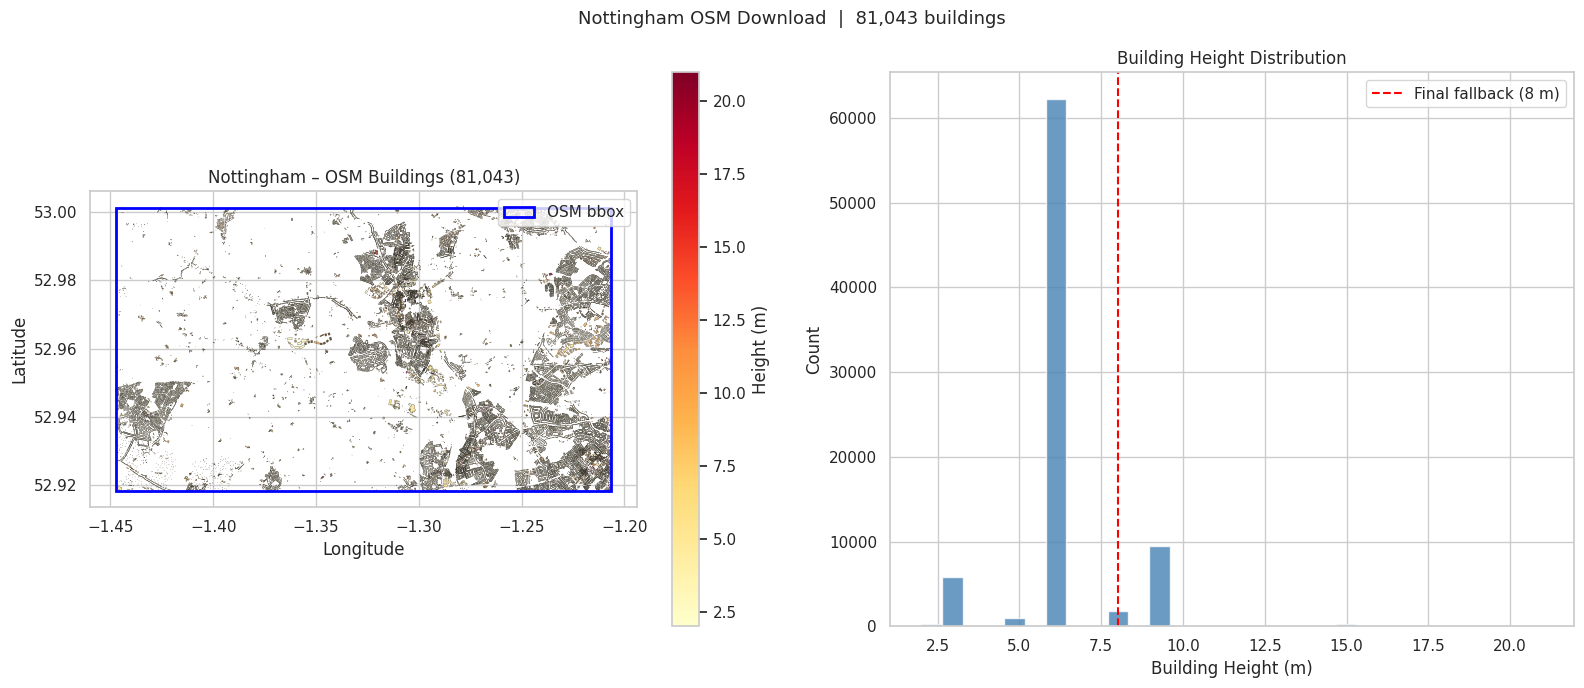

Map saved → /home/georgeskai/Documents/FYP2026/nottingham/results_sionna019/osm_buildings.png

  water       :    361 features  (cached)
  vegetation  :  4,777 features  (cached)
  tree        :  5,310 features  (cached)
  barrier     :  6,887 features  (cached)
  road        : 19,124 features  (cached)
  railway     :    179 features  (cached)
  power_tower :    633 features  (downloaded)
  mast        :     59 features  (downloaded)
  street_lamp :    128 features  (downloaded)
  glass_building:     49 features  (downloaded)
  bridge_area :    360 features  (downloaded)


In [5]:
if FORCE_REBUILD_SCENE or not os.path.exists(
        os.path.join(OUT_DIR, 'osm_buildings.geojson')):
    pass  # run block below
# ── OSM download (skip if scene already built) ────────────────────────────────
# Set FORCE_REBUILD_SCENE=True in CELL 0c to re-download

import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ── Paths ─────────────────────────────────────────────────────────────────────
OSM_GEOJSON = os.path.join(OUT_DIR, 'osm_buildings.geojson')
OSM_XML     = os.path.join(SCENE_DIR, 'scene', 'scene.xml')
os.makedirs(os.path.dirname(OSM_XML), exist_ok=True)

print(f'OSM download area : lon [{WEST:.5f}, {EAST:.5f}]  lat [{SOUTH:.5f}, {NORTH:.5f}]')
print(f'                  : {_w_km:.2f} km × {_h_km:.2f} km')

if not _HAS_OSM:
    print('\nosmnx not available. Install with:\n  pip install osmnx shapely')
else:
    import geopandas as gpd

    # ── Download or load from cache ───────────────────────────────────────────
    if os.path.exists(OSM_GEOJSON):
        print(f'\nLoading cached buildings from {OSM_GEOJSON} ...')
        gdf = gpd.read_file(OSM_GEOJSON)
        print(f'  Loaded {len(gdf)} buildings from cache.')
    else:
        print('\nDownloading buildings from OpenStreetMap ...')
        t0 = time.time()

        # osmnx 2.0.x API change:
        #   OLD (1.x): ox.features_from_bbox(north=N, south=S, east=E, west=W, tags=tags)
        #   NEW (2.0): ox.features_from_bbox(bbox=(west, south, east, north), tags=tags)
        try:
            ox.settings.log_level = 30   # WARNING only — suppress INFO spam (osmnx 2.0)
        except AttributeError:
            try: ox.settings.log_console = False   # fallback for osmnx 1.x
            except: pass
        ox.settings.timeout = 180

        gdf = ox.features_from_bbox(
            bbox=(WEST, SOUTH, EAST, NORTH),   # osmnx 2.0: (left, bottom, right, top)
            tags={'building': True}
        )
        print(f'  Downloaded {len(gdf)} features in {time.time()-t0:.1f}s')

        # Filter: keep only polygon footprints ≥ 20 m²
        gdf = gdf[gdf.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])].copy()
        gdf = gdf.to_crs('EPSG:4326')
        gdf_utm = gdf.to_crs(f'EPSG:{UTM_EPSG}')
        gdf     = gdf[gdf_utm.geometry.area >= 20.0].reset_index(drop=True)
        print(f'  After polygon + area filter: {len(gdf)} buildings')

        # Cache to GeoJSON: save geometry + useful OSM height/type tags
        _keep_cols = ['geometry']
        for _c in ['height','building:height','building:levels',
                   'building','building:material']:
            if _c in gdf.columns:
                # convert list/complex cells to string to avoid GeoJSON errors
                gdf[_c] = gdf[_c].apply(
                    lambda v: str(v) if isinstance(v, (list, dict)) else v)
                _keep_cols.append(_c)
        gdf[_keep_cols].to_file(OSM_GEOJSON, driver='GeoJSON')
        print(f'  Saved to {OSM_GEOJSON}  (cols: {_keep_cols})')

    # ── Building height extraction ─────────────────────────────────────────────
    # Priority: OSM height tag > building:levels > SRTM nDSM > OSM type heuristic
    LEVEL_HEIGHT_M = 3.0

    # OSM building-type heuristic defaults (floors × 3 m)
    _TYPE_FLOORS = {
        'house': 2, 'detached': 2, 'semidetached_house': 2, 'terrace': 2,
        'bungalow': 1, 'static_caravan': 1, 'shed': 1, 'garage': 1, 'garages': 1,
        'residential': 3, 'apartments': 5, 'block_of_flats': 5,
        'commercial': 3, 'retail': 2, 'supermarket': 2, 'kiosk': 1,
        'office': 6, 'hotel': 7,
        'industrial': 2, 'warehouse': 1, 'factory': 2,
        'church': 6, 'cathedral': 8, 'chapel': 4, 'mosque': 4, 'temple': 3,
        'school': 3, 'university': 4, 'hospital': 5,
        'train_station': 4, 'transportation': 3,
        'stadium': 8, 'grandstand': 5,
        'yes': 3,   # generic tagged building
    }



    def _parse_height(row):
        # 1. Explicit OSM height tag
        for col in ('height', 'building:height'):
            if col in row and pd.notna(row[col]):
                try: return float(str(row[col]).split()[0])
                except: pass
        # 2. Building levels tag
        if 'building:levels' in row and pd.notna(row.get('building:levels')):
            try: return float(row['building:levels']) * LEVEL_HEIGHT_M
            except: pass
        # 3. OSM building-type heuristic
        btype = str(row.get('building', '')).strip().lower()
        if btype in _TYPE_FLOORS:
            return _TYPE_FLOORS[btype] * LEVEL_HEIGHT_M
        return 8.0   # final fallback

    heights = gdf.apply(_parse_height, axis=1).values
    n_osm    = int(sum(1 for _, r in gdf.iterrows()
                       for c in ('height','building:height')
                       if c in r and pd.notna(r[c])))
    n_levels = int(sum(1 for _, r in gdf.iterrows()
                       if 'building:levels' in r and pd.notna(r.get('building:levels'))))
    print(f'\n  Building heights: min={heights.min():.1f}  mean={heights.mean():.1f}  '
          f'max={heights.max():.1f} m')
    # Clip to city-configured height range (set CITY_MAX_HEIGHT_M in CELL 0c)
    heights = np.clip(heights, CITY_MIN_HEIGHT_M, CITY_MAX_HEIGHT_M)

    print(f'  Sources: OSM tag={n_osm}  levels={n_levels}  '
          f'nDSM+heuristic={len(gdf)-n_osm-n_levels}')
    print(f'  Height stats: min={heights.min():.1f}  mean={heights.mean():.1f}  '
          f'max={heights.max():.1f} m  |  cap [{CITY_MIN_HEIGHT_M}, {CITY_MAX_HEIGHT_M}] m')

    # ── Plot ───────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Map — colour by height
    gdf.plot(ax=axes[0], column=heights, cmap='YlOrRd',
             legend=True, legend_kwds={'label': 'Height (m)'},
             edgecolor='k', linewidth=0.2, alpha=0.8)
    axes[0].add_patch(Rectangle((WEST, SOUTH), EAST-WEST, NORTH-SOUTH,
                                 fill=False, edgecolor='blue', lw=2, label='OSM bbox'))
    axes[0].set_title(f'{CITY_NAME} – OSM Buildings ({len(gdf):,})')
    axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
    axes[0].legend()

    # Height histogram
    axes[1].hist(heights, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1].axvline(8.0, color='red', ls='--', label='Final fallback (8 m)')
    axes[1].set_xlabel('Building Height (m)'); axes[1].set_ylabel('Count')
    axes[1].set_title('Building Height Distribution'); axes[1].legend()

    plt.suptitle(f'{CITY_NAME} OSM Download  |  {len(gdf):,} buildings', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'osm_buildings.png'), dpi=150)
    plt.show()
    print(f'Map saved → {os.path.join(OUT_DIR, "osm_buildings.png")}')
    # ── Additional OSM feature downloads ──────────────────────────────────────
    print('\nDownloading additional OSM features ...')

    _EXTRA_QUERIES = {
        'water':      [{'natural': ['water', 'bay', 'wetland']},
                       {'waterway': ['river', 'stream', 'canal', 'drain', 'ditch']}],
        'vegetation':  [{'natural': ['wood', 'scrub', 'heath', 'grassland']},
                        {'landuse': ['forest', 'orchard', 'vineyard', 'grass', 'meadow',
                                     'village_green', 'farmland', 'allotments']},
                        {'leisure': ['park', 'garden', 'nature_reserve',
                                     'recreation_ground', 'pitch']}],
        'tree':        [{'natural': 'tree'}],
        'barrier':     [{'barrier': ['wall', 'retaining_wall', 'fence',
                                     'hedge', 'embankment', 'guard_rail']}],
        'road':        [{'highway': ['motorway', 'motorway_link', 'trunk', 'trunk_link',
                                     'primary', 'primary_link', 'secondary', 'secondary_link',
                                     'tertiary', 'residential', 'service', 'unclassified',
                                     'living_street', 'pedestrian', 'footway', 'path']}],
        'railway':     [{'railway': ['rail', 'subway', 'tram', 'light_rail', 'monorail',
                                     'narrow_gauge']}],
        'power_tower': [{'power': ['tower', 'pole']}],
        'mast':        [{'man_made': ['mast', 'tower', 'chimney', 'silo',
                                      'water_tower', 'storage_tank', 'cooling_tower']},
                        {'tower:type': ['communication', 'observation', 'lighting']}],
        'street_lamp': [{'highway': 'street_lamp'}, {'man_made': 'street_lamp'}],
        'glass_building': [{'building:material': 'glass'},
                           {'building': ['glass_house', 'greenhouse']},
                           {'amenity': ['marketplace']},
                           {'shop': ['mall', 'supermarket']}],
        'bridge_area': [{'man_made': 'bridge'}, {'bridge': 'yes'}],
        'solar':         [{'generator:source': 'solar'},
                          {'power': 'plant'},
                          {'man_made': 'solar_panel'}],
        'swimming_pool': [{'leisure': 'swimming_pool'}],
        'noise_barrier': [{'barrier': ['noise_barrier', 'city_wall', 'retaining_wall']}],
        'wind_turbine':  [{'man_made': 'wind_turbine'},
                          {'generator:source': 'wind'}],
        'pipeline':      [{'man_made': 'pipeline'}],
        'billboard':     [{'advertising': ['billboard', 'poster', 'sign']},
                          {'man_made': 'advertising'}],
        'shelter':       [{'amenity': ['shelter', 'bus_stop']},
                          {'building': ['roof', 'canopy', 'carport', 'garages']}],
        'cliff':         [{'natural': ['cliff', 'earth_bank', 'ridge']}],
        'substation':    [{'power': ['substation', 'transformer', 'switch']},
                          {'man_made': ['transformer_tower', 'utility_pole']}],
        'car_park':      [{'amenity': 'parking'},
                          {'parking': ['multi-storey', 'rooftop']}],
        'aeroway':       [{'aeroway': ['runway', 'taxiway', 'apron', 'helipad']}],
        'pitch':         [{'leisure': ['pitch', 'track', 'ice_rink', 'sports_centre']},
                          {'landuse': ['recreation_ground', 'winter_sports']}],
        # ── NEW: tall/large vegetation ───────────────────────────────────────
        'tree_row':      [{'natural': 'tree_row'}],           # lines of roadside trees
        'tall_tree':     [{'natural': 'tree'},                # individual trees with height tag
                          {'height': True}],
        # ── NEW: large structures for strong reflections ─────────────────────
        'stadium':       [{'leisure': ['stadium', 'grandstand']},
                          {'building': ['stadium', 'grandstand', 'sports_hall']}],
        'crane':         [{'man_made': 'crane'}],
        'lighthouse':    [{'man_made': 'lighthouse'},
                          {'man_made': 'beacon'}],
        'cooling_tower': [{'man_made': 'cooling_tower'},
                          {'man_made': 'gasometer'}],
        'church_spire':  [{'building': ['church', 'cathedral', 'chapel',
                                        'synagogue', 'mosque', 'monastery']},
                          {'amenity': ['place_of_worship']}],
        'retaining_wall':[{'barrier': 'retaining_wall'},
                          {'man_made': 'embankment'}],
        'hedge_row':     [{'barrier': 'hedge'}],              # dense hedge walls
        'greenhouse':    [{'building': ['greenhouse', 'glasshouse']},
                          {'landuse': 'greenhouse_horticulture'}],
        'car_park_struct':[{'building': ['parking', 'garages']},
                           {'amenity': 'parking'},
                           {'parking': ['multi-storey', 'rooftop']}],
    }

    osm_extra = {}
    for feat, queries in _EXTRA_QUERIES.items():
        _cache = os.path.join(OUT_DIR, f'osm_{feat}.geojson')
        if os.path.exists(_cache) and not FORCE_REBUILD_SCENE:
            try:
                osm_extra[feat] = gpd.read_file(_cache)
                print(f'  {feat:12s}: {len(osm_extra[feat]):6,} features  (cached)')
                continue
            except Exception:
                pass
        _frames = []
        for _tags in queries:
            try:
                _gdf = ox.features_from_bbox(
                    bbox=(WEST, SOUTH, EAST, NORTH), tags=_tags)
                _frames.append(_gdf)
            except Exception as _e:
                if 'InsufficientResponseError' not in str(type(_e)):
                    print(f'    [{feat}] query {_tags}: {_e}')
        if _frames:
            _non_empty = [f for f in _frames if len(f) > 0]
            if _non_empty:
                import pandas as _pd_extra
                _merged = gpd.GeoDataFrame(
                    _pd_extra.concat(_non_empty, ignore_index=True))
            else:
                _merged = gpd.GeoDataFrame()
            if len(_merged):
                _merged = _merged.to_crs('EPSG:4326')
                # keep only relevant geometry types
                if feat in ('water', 'vegetation', 'glass_building'):
                    _merged = _merged[_merged.geometry.geom_type.isin(
                        ['Polygon', 'MultiPolygon'])]
                elif feat in ('tree', 'power_tower', 'mast', 'street_lamp'):
                    _merged = _merged[_merged.geometry.geom_type == 'Point']
                elif feat == 'bridge_area':
                    _merged = _merged[_merged.geometry.geom_type.isin(
                        ['Polygon', 'MultiPolygon', 'LineString', 'MultiLineString'])]
                else:
                    _merged = _merged[_merged.geometry.geom_type.isin(
                        ['LineString', 'MultiLineString'])]
                _merged = _merged[~_merged.geometry.is_empty].reset_index(drop=True)
                try:
                    _merged[['geometry']].to_file(_cache, driver='GeoJSON')
                except Exception:
                    pass
                osm_extra[feat] = _merged
                print(f'  {feat:12s}: {len(_merged):6,} features  (downloaded)')
            else:
                osm_extra[feat] = gpd.GeoDataFrame()
                print(f'  {feat:12s}:      0 features')
        else:
            osm_extra[feat] = gpd.GeoDataFrame()
            print(f'  {feat:12s}:      0 features')

## CELL 3 · Build Mitsuba 3 Scene (OSM → PLY + scene.xml)

Converts OSM footprints to PLY meshes with ITU material assignments and writes `scene.xml`.

**Materials assigned from `_MAT_PARAMS` (ITU-R P.2040-2):**
- `itu_concrete` S=0.40, xpd=0.10
- `itu_brick` S=0.30, xpd=0.10
- `itu_glass` S=0.08, xpd=0.05
- `itu_vegetation` S=0.75, xpd=0.30 ← highest scattering
- `itu_metal` S=0.05, xpd=0.01 ← specular

**LambertianPattern** applied to all materials (uniform hemisphere diffuse scattering).

Skip with `FORCE_REBUILD_SCENE=False` if `scene.xml` already exists.

In [6]:
# OSM -> Mitsuba 3 scene: PLY meshes + scene.xml (Sionna 0.19 compatible)
# Skipped automatically if scene.xml exists and FORCE_REBUILD_SCENE=False

_scene_xml_exists = os.path.exists(SCENE_XML)
if not FORCE_REBUILD_SCENE and _scene_xml_exists:
    print(f'Scene already exists: {SCENE_XML}')
    print('Set FORCE_REBUILD_SCENE=True in CELL 0c to regenerate.')
    XML_OK = True
else:
    # Buildings grouped by material -> one PLY per material type.
    # Terrain sampled from DEM -> terrain.ply
    # Extra features: water, vegetation, trees, barriers, roads, railways,
    #                 power towers, masts, street lamps, glass buildings, bridges
    # All PLY files in scene/meshes/; scene.xml references them by filename.

    import xml.etree.ElementTree as ET
    import xml.dom.minidom as minidom
    import numpy as np
    import struct, os, time, math

    _HAS_DEM_RASTERIO = False
    try:
        import rasterio
        _HAS_DEM_RASTERIO = True
    except ImportError:
        pass

    if not _HAS_OSM or 'gdf' not in dir():
        print('Run CELL 2 first.')
    else:
        print(f'Generating Mitsuba 3 scene (PLY + XML) from {len(gdf)} buildings ...')
        t0 = time.time()

        SCENE_OUT_DIR  = os.path.join(BASE_DIR, 'scene')
        MESHES_DIR     = os.path.join(SCENE_OUT_DIR, 'meshes')
        os.makedirs(MESHES_DIR, exist_ok=True)
        SCENE_XML_OUT  = os.path.join(SCENE_OUT_DIR, 'scene.xml')

        # ── Load DEM ──────────────────────────────────────────────────────────
        _dem_ds2 = _dem_data2 = _dem_tf2 = _wgs_to_dem2 = None
        if _HAS_DEM_RASTERIO and os.path.exists(DEM_TIFF):
            try:
                from pyproj import Transformer as _Tr2
                _dem_ds2   = rasterio.open(DEM_TIFF)
                _dem_data2 = _dem_ds2.read(1).astype(np.float32)
                _dem_tf2   = _dem_ds2.transform
                _epsg2     = str(_dem_ds2.crs.to_epsg()) if _dem_ds2.crs else ''
                _wgs_to_dem2 = _Tr2.from_crs('EPSG:4326',
                                   f'EPSG:{_epsg2}' if _epsg2 else _dem_ds2.crs,
                                   always_xy=True)
                print(f'  DEM: {_dem_data2.shape} px, EPSG:{_epsg2}')
            except Exception as _e:
                print(f'  DEM load failed: {_e}')

        def _dem_z2(lon, lat):
            if _dem_data2 is None: return 0.0
            try:
                dx, dy = _wgs_to_dem2.transform(lon, lat)
                tf = _dem_tf2
                col = (dx - tf.c) / tf.a
                row = (dy - tf.f) / tf.e
                r, c = int(round(row)), int(round(col))
                nr, nc = _dem_data2.shape
                r = max(0, min(nr-1, r)); c = max(0, min(nc-1, c))
                v = float(_dem_data2[r, c])
                return v if (np.isfinite(v) and v > -9000) else 0.0
            except Exception: return 0.0

        origin_elev2 = _dem_z2(center_lon, center_lat)

        # ── PLY writer ────────────────────────────────────────────────────────
        def write_ply(path, verts, faces):
            verts = np.asarray(verts, dtype=np.float32)
            faces = np.asarray(faces, dtype=np.int32)
            with open(path, 'wb') as fp:
                hdr = (
                    'ply\nformat binary_little_endian 1.0\n'
                    f'element vertex {len(verts)}\n'
                    'property float x\nproperty float y\nproperty float z\n'
                    f'element face {len(faces)}\n'
                    'property list uchar int vertex_indices\n'
                    'end_header\n'
                )
                fp.write(hdr.encode())
                fp.write(verts.tobytes())
                for tri in faces:
                    fp.write(struct.pack('<B', 3))
                    fp.write(struct.pack('<3i', *tri))

        # ── Project OSM to UTM ────────────────────────────────────────────────
        gdf_utm = gdf.to_crs(f'EPSG:{UTM_EPSG}')
        ox_utm, oy_utm = utm_center_x, utm_center_y

        # Optional radius filter — reduces BVH size / GPU memory
        if SCENE_RADIUS_KM is not None:
            _r = SCENE_RADIUS_KM * 1000.0
            _cx = gdf_utm.geometry.centroid.x - ox_utm
            _cy = gdf_utm.geometry.centroid.y - oy_utm
            _mask = (_cx**2 + _cy**2) <= _r**2
            _before = len(gdf_utm)
            gdf_utm = gdf_utm[_mask].reset_index(drop=True)
            gdf     = gdf[_mask].reset_index(drop=True)
            print(f'  Radius filter {SCENE_RADIUS_KM} km: {_before} -> {len(gdf_utm)} buildings')

        # ── ITU material lists ─────────────────────────────────────────────────
        ITU_MATS      = ['itu_concrete', 'itu_brick', 'itu_glass', 'itu_wood']
        ITU_ROOF_MATS = ['itu_metal']   # gabled/hip roof faces
        ALL_MATS = ITU_MATS + ITU_ROOF_MATS + [
            'itu_water', 'itu_vegetation', 'itu_medium_dry_ground', 'itu_glass'
        ]

        # ── Improved building material detection ──────────────────────────────
        def _bld_mat(row):
            mat  = str(row.get('building:material', '')).lower()
            fmat = str(row.get('building:facade:material', '')).lower()
            tag  = str(row.get('building', '')).lower()
            amen = str(row.get('amenity', '')).lower()
            shop = str(row.get('shop', '')).lower()
            off  = str(row.get('office', '')).lower()
            # Explicit material tags
            if 'glass' in mat or 'glass' in fmat:              return 'itu_glass'
            if 'wood' in mat or 'timber' in mat:               return 'itu_wood'
            if 'wood' in fmat or 'timber' in fmat:             return 'itu_wood'
            if 'brick' in mat or 'brick' in fmat:              return 'itu_brick'
            if 'stone' in mat or 'stone' in fmat:              return 'itu_brick'
            # Building type heuristics
            if tag in ('greenhouse', 'glasshouse'):             return 'itu_glass'
            if amen in ('shopping_centre', 'mall'):            return 'itu_glass'
            if shop in ('mall', 'supermarket'):                 return 'itu_glass'
            if off:                                             return 'itu_concrete'
            return 'itu_concrete'

        # Collect per-material vertex/face lists
        mat_verts = {m: [] for m in ITU_MATS + ITU_ROOF_MATS}
        mat_faces = {m: [] for m in ITU_MATS + ITU_ROOF_MATS}

        # ── Tag-aware roof builder ─────────────────────────────────────────────
        def build_roof(pts, z1, h, roof_shape, roof_mat):
            # Build roof geometry based on OSM roof:shape tag.
            # roof_shape: 'gabled'|'hipped'|'pyramidal'|'flat'|'dome'|'skillion'
            # Returns (verts, faces) lists.
            ROOF_H = max(1.5, h * 0.25)
            n = len(pts)
            cx = sum(x for x, y in pts) / n
            cy = sum(y for x, y in pts) / n

            if roof_shape == 'flat':
                # Flat cap fan
                verts = [(x, y, z1) for x, y in pts]
                faces = [(0, i, i + 1) for i in range(1, n - 1)]
                return verts, faces

            if roof_shape == 'gabled':
                # Find long axis via minimum bounding rectangle
                try:
                    from shapely.geometry import Polygon as _Poly
                    poly = _Poly(pts)
                    mbr = poly.minimum_rotated_rectangle
                    mbr_coords = list(mbr.exterior.coords[:-1])
                    d01 = ((mbr_coords[1][0] - mbr_coords[0][0])**2 +
                           (mbr_coords[1][1] - mbr_coords[0][1])**2) ** 0.5
                    d12 = ((mbr_coords[2][0] - mbr_coords[1][0])**2 +
                           (mbr_coords[2][1] - mbr_coords[1][1])**2) ** 0.5
                    if d01 >= d12:
                        ridge_p1 = ((mbr_coords[0][0] + mbr_coords[3][0]) / 2,
                                    (mbr_coords[0][1] + mbr_coords[3][1]) / 2)
                        ridge_p2 = ((mbr_coords[1][0] + mbr_coords[2][0]) / 2,
                                    (mbr_coords[1][1] + mbr_coords[2][1]) / 2)
                    else:
                        ridge_p1 = ((mbr_coords[0][0] + mbr_coords[1][0]) / 2,
                                    (mbr_coords[0][1] + mbr_coords[1][1]) / 2)
                        ridge_p2 = ((mbr_coords[2][0] + mbr_coords[3][0]) / 2,
                                    (mbr_coords[2][1] + mbr_coords[3][1]) / 2)
                    z_ridge = z1 + ROOF_H
                    verts = [(x, y, z1) for x, y in pts]
                    verts += [(*ridge_p1, z_ridge), (*ridge_p2, z_ridge)]
                    r1_idx, r2_idx = n, n + 1
                    faces = []
                    for i in range(n):
                        j = (i + 1) % n
                        ex = (pts[i][0] + pts[j][0]) / 2
                        ey = (pts[i][1] + pts[j][1]) / 2
                        d1 = (ex - ridge_p1[0])**2 + (ey - ridge_p1[1])**2
                        d2 = (ex - ridge_p2[0])**2 + (ey - ridge_p2[1])**2
                        near = r1_idx if d1 < d2 else r2_idx
                        faces.append((i, j, near))
                    faces.append((r1_idx, r2_idx, 0))
                    return verts, faces
                except Exception:
                    pass  # fall through to hipped

            # Default: hipped (pyramid) — works for any polygon shape
            verts = [(x, y, z1) for x, y in pts]
            verts.append((cx, cy, z1 + ROOF_H))
            apex = n
            faces = [(i, (i + 1) % n, apex) for i in range(n)]
            return verts, faces

        # ── Vertical cylinder builder (towers, masts, poles) ──────────────────
        def build_cylinder(cx, cy, z_base, radius, height, n_sides=8):
            # Vertical cylinder for towers, masts, poles.
            verts, faces = [], []
            angles = [2 * math.pi * k / n_sides for k in range(n_sides)]
            # Bottom ring
            for a in angles:
                verts.append((cx + radius * math.cos(a),
                              cy + radius * math.sin(a), z_base))
            # Top ring
            for a in angles:
                verts.append((cx + radius * math.cos(a),
                              cy + radius * math.sin(a), z_base + height))
            # Side faces
            for k in range(n_sides):
                j = (k + 1) % n_sides
                faces += [(k, j, n_sides + j), (k, n_sides + j, n_sides + k)]
            # Top cap
            top_c = 2 * n_sides
            verts.append((cx, cy, z_base + height))
            for k in range(n_sides):
                faces.append((n_sides + k, n_sides + (k + 1) % n_sides, top_c))
            return verts, faces

        gdf_wgs_list  = list(gdf.iterrows())
        gdf_utm_list  = list(gdf_utm.iterrows())
        skipped = 0

        for idx in range(len(gdf_utm_list)):
            _, row_utm = gdf_utm_list[idx]
            _, row_wgs = gdf_wgs_list[idx]
            geom = row_utm.geometry
            if geom is None or geom.is_empty:
                skipped += 1; continue
            try:
                hull = geom.convex_hull
                if hull.geom_type != 'Polygon': skipped += 1; continue
                ring = list(hull.exterior.coords[:-1])
            except Exception:
                skipped += 1; continue
            n = len(ring)
            if n < 3: skipped += 1; continue

            # building height
            h = heights[idx] if idx < len(heights) else 8.0

            # base elevation from DEM
            try:
                ctr = row_wgs.geometry.centroid
                base_z = _dem_z2(ctr.x, ctr.y) - origin_elev2
            except Exception:
                base_z = 0.0

            pts = [(x - ox_utm, y - oy_utm) for x, y in ring]
            z0, z1 = base_z, base_z + h

            mat = _bld_mat(dict(row_wgs))
            vl  = mat_verts[mat]
            fl  = mat_faces[mat]
            base_idx = len(vl)

            # bottom ring + top ring (wall vertices)
            for x, y in pts: vl.append((x, y, z0))
            for x, y in pts: vl.append((x, y, z1))

            # side walls
            for i in range(n):
                j = (i + 1) % n
                b, t = base_idx, base_idx + n
                fl.append((b + i, b + j, t + j))
                fl.append((b + i, t + j, t + i))
            # bottom cap fan (reversed)
            for i in range(1, n - 1):
                fl.append((base_idx, base_idx + i + 1, base_idx + i))

            # ── Tag-aware roof ────────────────────────────────────────────────
            roof_shape_tag = str(row_wgs.get('roof:shape', 'hipped')).lower()
            roof_mat_tag   = str(row_wgs.get('roof:material', '')).lower()

            # Determine roof material from tag
            if any(k in roof_mat_tag for k in
                   ['metal', 'steel', 'zinc', 'aluminium', 'copper', 'tin']):
                r_mat = 'itu_metal'
            elif 'glass' in roof_mat_tag:
                r_mat = 'itu_glass'
            elif any(k in roof_mat_tag for k in ['wood', 'timber', 'thatch']):
                r_mat = 'itu_wood'
            else:
                r_mat = 'itu_metal'   # default metal — maximises reflections

            # Ensure roof material bucket exists
            if r_mat not in mat_verts:
                mat_verts[r_mat] = []
                mat_faces[r_mat] = []

            r_verts, r_faces = build_roof(pts, z1, h, roof_shape_tag, r_mat)
            if r_verts:
                _rb = len(mat_verts[r_mat])
                mat_verts[r_mat].extend(r_verts)
                mat_faces[r_mat].extend(
                    [(_rb + a, _rb + b, _rb + c) for a, b, c in r_faces])

        print(f'  Built geometry: {sum(len(v) for v in mat_verts.values()):,} verts'
              f'  {sum(len(f) for f in mat_faces.values()):,} faces  ({skipped} skipped)')

        # ── Extra feature geometry ─────────────────────────────────────────────
        _EXTRA_MATS = ['itu_water', 'itu_vegetation', 'itu_medium_dry_ground', 'itu_very_dry_ground']
        for _m in _EXTRA_MATS:
            if _m not in mat_verts:
                mat_verts[_m] = []
                mat_faces[_m] = []

        # ── Road width lookup ──────────────────────────────────────────────────
        _ROAD_WIDTH = {
            'motorway': 22, 'motorway_link': 8,
            'trunk': 16, 'trunk_link': 8,
            'primary': 12, 'primary_link': 6,
            'secondary': 10, 'secondary_link': 5,
            'tertiary': 8, 'residential': 6,
            'service': 4, 'unclassified': 6,
            'living_street': 5, 'pedestrian': 4,
            'footway': 2, 'path': 1.5,
        }

        # ── Helper: tessellate a polygon ring with per-vertex DEM elevation ───
        def tessellate_polygon_dem(ring_local_xy, lon_lat_ring, dem_fn, clearance,
                                   flat=False):
            # Fan triangulation from vertex 0.
            # flat=True: all vertices get the minimum DEM elevation (water surfaces).
            # Returns (verts_3d, face_indices) relative to current mat lists.
            n_pts = len(ring_local_xy)
            if n_pts < 3:
                return [], []
            zs = [dem_fn(lon, lat) - origin_elev2 + clearance
                  for lon, lat in lon_lat_ring]
            if flat:
                z_flat = min(zs)
                zs = [z_flat] * n_pts
            verts = [(ring_local_xy[i][0], ring_local_xy[i][1], zs[i])
                     for i in range(n_pts)]
            faces = [(0, i, i + 1) for i in range(1, n_pts - 1)]
            return verts, faces

        # ── Helper: extrude linestring into a flat strip or vertical wall ──────
        def extrude_linestring_dem(coords_utm, width_m, wall_height, dem_fn,
                                   ox, oy, clearance):
            # Creates quad strip along linestring with per-vertex DEM elevation.
            pts = [(x - ox, y - oy) for x, y in coords_utm]
            n = len(pts)
            if n < 2:
                return [], []
            half = width_m / 2.0

            def _perp(ax, ay, bx, by):
                dx, dy = bx - ax, by - ay
                length = (dx*dx + dy*dy) ** 0.5
                if length < 1e-9:
                    return 0.0, 0.0
                return -dy / length, dx / length

            offsets = []
            for i in range(n):
                if i == 0:
                    ox2, oy2 = _perp(pts[0][0], pts[0][1], pts[1][0], pts[1][1])
                elif i == n - 1:
                    ox2, oy2 = _perp(pts[-2][0], pts[-2][1], pts[-1][0], pts[-1][1])
                else:
                    p1x, p1y = _perp(pts[i-1][0], pts[i-1][1], pts[i][0], pts[i][1])
                    p2x, p2y = _perp(pts[i][0], pts[i][1], pts[i+1][0], pts[i+1][1])
                    mx, my = p1x + p2x, p1y + p2y
                    ml = (mx*mx + my*my) ** 0.5
                    if ml < 1e-9:
                        ox2, oy2 = p1x, p1y
                    else:
                        ox2, oy2 = mx / ml, my / ml
                offsets.append((ox2, oy2))

            verts = []
            faces = []

            try:
                from pyproj import Transformer as _TrInv
                _utm_to_wgs_local = _TrInv.from_crs(
                    f'EPSG:{UTM_EPSG}', 'EPSG:4326', always_xy=True)
                def _z_at_utm(ux, uy):
                    lon2, lat2 = _utm_to_wgs_local.transform(ux + ox, uy + oy)
                    return dem_fn(lon2, lat2) - origin_elev2 + clearance
            except Exception:
                def _z_at_utm(ux, uy):
                    return clearance

            if wall_height == 0:
                left_verts  = []
                right_verts = []
                for i, (px, py) in enumerate(pts):
                    ox2, oy2 = offsets[i]
                    lx, ly = px - half * ox2, py - half * oy2
                    rx, ry = px + half * ox2, py + half * oy2
                    zl = _z_at_utm(lx, ly)
                    zr = _z_at_utm(rx, ry)
                    left_verts.append((lx, ly, zl))
                    right_verts.append((rx, ry, zr))
                for i in range(n):
                    verts.append(left_verts[i])
                    verts.append(right_verts[i])
                for i in range(n - 1):
                    li, ri   = 2*i,   2*i+1
                    li1, ri1 = 2*(i+1), 2*(i+1)+1
                    faces.append((li, ri1, ri))
                    faces.append((li, li1, ri1))
            else:
                for i, (px, py) in enumerate(pts):
                    ox2, oy2 = offsets[i]
                    lx, ly = px - half * ox2, py - half * oy2
                    rx, ry = px + half * ox2, py + half * oy2
                    zbot_l = _z_at_utm(lx, ly)
                    zbot_r = _z_at_utm(rx, ry)
                    verts.append((lx, ly, zbot_l))
                    verts.append((rx, ry, zbot_r))
                    verts.append((rx, ry, zbot_r + wall_height))
                    verts.append((lx, ly, zbot_l + wall_height))
                for i in range(n - 1):
                    b0, b1, t1, t0 = 4*i, 4*i+1, 4*i+2, 4*i+3
                    nb0 = 4*(i+1); nb1 = 4*(i+1)+1
                    nt1 = 4*(i+1)+2; nt0 = 4*(i+1)+3
                    faces.append((b0, nb0, nt0))
                    faces.append((b0, nt0, t0))
                    faces.append((b1, t1, nt1))
                    faces.append((b1, nt1, nb1))
                    faces.append((t0, nt0, nt1))
                    faces.append((t0, nt1, t1))
            return verts, faces

        # ── Helper: simple tree mesh (cylinder trunk + cone canopy) ──────────
        def build_tree_mesh(cx_local, cy_local, z_base,
                            trunk_r=0.25, trunk_h=5.0, canopy_r=2.5, n_sides=6):
            # Returns (verts_3d, face_indices) for a stylised tree.
            verts = []
            faces = []
            angles = [2 * math.pi * k / n_sides for k in range(n_sides)]

            trunk_bot = len(verts)
            for a in angles:
                verts.append((cx_local + trunk_r * math.cos(a),
                               cy_local + trunk_r * math.sin(a), z_base))
            trunk_top = len(verts)
            for a in angles:
                verts.append((cx_local + trunk_r * math.cos(a),
                               cy_local + trunk_r * math.sin(a),
                               z_base + trunk_h))
            for i in range(n_sides):
                j = (i + 1) % n_sides
                faces.append((trunk_bot + i, trunk_bot + j, trunk_top + j))
                faces.append((trunk_bot + i, trunk_top + j, trunk_top + i))
            bot_ctr = len(verts)
            verts.append((cx_local, cy_local, z_base))
            for i in range(n_sides):
                j = (i + 1) % n_sides
                faces.append((bot_ctr, trunk_bot + j, trunk_bot + i))

            canopy_base_z = z_base + trunk_h
            canopy_top_z  = canopy_base_z + canopy_r * 1.5
            canopy_base = len(verts)
            for a in angles:
                verts.append((cx_local + canopy_r * math.cos(a),
                               cy_local + canopy_r * math.sin(a), canopy_base_z))
            apex = len(verts)
            verts.append((cx_local, cy_local, canopy_top_z))
            for i in range(n_sides):
                j = (i + 1) % n_sides
                faces.append((canopy_base + i, canopy_base + j, apex))
            canopy_ctr = len(verts)
            verts.append((cx_local, cy_local, canopy_base_z))
            for i in range(n_sides):
                j = (i + 1) % n_sides
                faces.append((canopy_ctr, canopy_base + j, canopy_base + i))

            return verts, faces

        # ── Process extra OSM features ────────────────────────────────────────
        _osm_extra = globals().get('osm_extra', {})

        try:
            from pyproj import Transformer as _TrExtra
            _wgs_to_utm_extra = _TrExtra.from_crs(
                'EPSG:4326', f'EPSG:{UTM_EPSG}', always_xy=True)
        except Exception as _te:
            print(f'  Warning: could not create UTM transformer for extra features: {_te}')
            _wgs_to_utm_extra = None

        def _ll_to_local(lon, lat):
            # lon,lat -> scene local (x,y) in metres from origin.
            if _wgs_to_utm_extra is None:
                return 0.0, 0.0
            ux, uy = _wgs_to_utm_extra.transform(lon, lat)
            return ux - ox_utm, uy - oy_utm

        def _ll_to_utm(lon, lat):
            # lon,lat -> UTM (easting, northing) absolute coordinates.
            if _wgs_to_utm_extra is None:
                return 0.0, 0.0
            return _wgs_to_utm_extra.transform(lon, lat)

        # ── Water: flat polygon meshes ────────────────────────────────────────
        _gdf_water = _osm_extra.get('water', None)
        if _gdf_water is not None and len(_gdf_water) > 0:
            _skip_w = 0
            for _, _row in _gdf_water.iterrows():
                _geom = _row.geometry
                if _geom is None or _geom.is_empty:
                    _skip_w += 1; continue
                _polys = ([_geom] if _geom.geom_type == 'Polygon'
                          else list(_geom.geoms) if _geom.geom_type == 'MultiPolygon'
                          else [])
                for _poly in _polys:
                    if _poly.is_empty: continue
                    _ring = list(_poly.exterior.coords[:-1])
                    if len(_ring) < 3: continue
                    _ll_ring   = [(lon, lat) for lon, lat in _ring]
                    _local_xy  = [_ll_to_local(lon, lat) for lon, lat in _ll_ring]
                    _v, _f = tessellate_polygon_dem(
                        _local_xy, _ll_ring, _dem_z2, clearance=0.05, flat=True)
                    if not _v: continue
                    _base = len(mat_verts['itu_water'])
                    mat_verts['itu_water'].extend(_v)
                    mat_faces['itu_water'].extend(
                        [(_base+a, _base+b, _base+c) for a, b, c in _f])
            print(f'  water        : {len(mat_verts["itu_water"]):6,} verts  '
                  f'{len(mat_faces["itu_water"]):6,} faces  ({_skip_w} skipped geoms)')

        # ── Vegetation: flat polygon meshes ──────────────────────────────────
        _gdf_veg = _osm_extra.get('vegetation', None)
        if _gdf_veg is not None and len(_gdf_veg) > 0:
            _skip_v = 0
            for _, _row in _gdf_veg.iterrows():
                _geom = _row.geometry
                if _geom is None or _geom.is_empty:
                    _skip_v += 1; continue
                _polys = ([_geom] if _geom.geom_type == 'Polygon'
                          else list(_geom.geoms) if _geom.geom_type == 'MultiPolygon'
                          else [])
                for _poly in _polys:
                    if _poly.is_empty: continue
                    _ring = list(_poly.exterior.coords[:-1])
                    if len(_ring) < 3: continue
                    _ll_ring  = [(lon, lat) for lon, lat in _ring]
                    _local_xy = [_ll_to_local(lon, lat) for lon, lat in _ll_ring]
                    _v, _f = tessellate_polygon_dem(
                        _local_xy, _ll_ring, _dem_z2, clearance=0.1, flat=False)
                    if not _v: continue
                    _base = len(mat_verts['itu_vegetation'])
                    mat_verts['itu_vegetation'].extend(_v)
                    mat_faces['itu_vegetation'].extend(
                        [(_base+a, _base+b, _base+c) for a, b, c in _f])
            print(f'  vegetation   : {len(mat_verts["itu_vegetation"]):6,} verts  '
                  f'{len(mat_faces["itu_vegetation"]):6,} faces  ({_skip_v} skipped geoms)')

        # ── Trees: cylinder + cone meshes ────────────────────────────────────
        _gdf_tree = _osm_extra.get('tree', None)
        if _gdf_tree is not None and len(_gdf_tree) > 0:
            _skip_t = 0
            for _, _row in _gdf_tree.iterrows():
                _geom = _row.geometry
                if _geom is None or _geom.is_empty or _geom.geom_type != 'Point':
                    _skip_t += 1; continue
                _lon, _lat = _geom.x, _geom.y
                _lx, _ly = _ll_to_local(_lon, _lat)
                _z_base  = _dem_z2(_lon, _lat) - origin_elev2
                _v, _f = build_tree_mesh(_lx, _ly, _z_base)
                if not _v: continue
                _base = len(mat_verts['itu_vegetation'])
                mat_verts['itu_vegetation'].extend(_v)
                mat_faces['itu_vegetation'].extend(
                    [(_base+a, _base+b, _base+c) for a, b, c in _f])
            print(f'  trees        : {len(_gdf_tree):6,} trees added to itu_vegetation  '
                  f'({_skip_t} skipped)')

        # ── Barriers: walls / fences / hedges ────────────────────────────────
        _gdf_barrier = _osm_extra.get('barrier', None)
        if _gdf_barrier is not None and len(_gdf_barrier) > 0:
            _skip_b = 0
            for _, _row in _gdf_barrier.iterrows():
                _geom = _row.geometry
                if _geom is None or _geom.is_empty:
                    _skip_b += 1; continue
                _lines = ([_geom] if _geom.geom_type == 'LineString'
                          else list(_geom.geoms) if _geom.geom_type == 'MultiLineString'
                          else [])
                for _line in _lines:
                    _coords = list(_line.coords)
                    if len(_coords) < 2: continue
                    _coords_utm = [_wgs_to_utm_extra.transform(lon, lat)
                                   for lon, lat in _coords]
                    _v, _f = extrude_linestring_dem(
                        _coords_utm, width_m=0.5, wall_height=2.0,
                        dem_fn=_dem_z2, ox=ox_utm, oy=oy_utm, clearance=0.0)
                    if not _v: continue
                    _base = len(mat_verts['itu_concrete'])
                    mat_verts['itu_concrete'].extend(_v)
                    mat_faces['itu_concrete'].extend(
                        [(_base+a, _base+b, _base+c) for a, b, c in _f])
            print(f'  barriers     : processed {len(_gdf_barrier):,} features  '
                  f'({_skip_b} skipped)')

        # ── Roads: flat strips by highway type ───────────────────────────────
        _gdf_road = _osm_extra.get('road', None)
        if _gdf_road is not None and len(_gdf_road) > 0:
            _skip_r = 0
            for _, _row in _gdf_road.iterrows():
                _geom = _row.geometry
                if _geom is None or _geom.is_empty:
                    _skip_r += 1; continue
                _lines = ([_geom] if _geom.geom_type == 'LineString'
                          else list(_geom.geoms) if _geom.geom_type == 'MultiLineString'
                          else [])
                _hw_tag = ''
                if hasattr(_row, 'get'):
                    _hw_tag = str(_row.get('highway', '')).lower()
                elif hasattr(_row, '__getitem__'):
                    try: _hw_tag = str(_row['highway']).lower()
                    except Exception: pass
                _width = _ROAD_WIDTH.get(_hw_tag, 6.0)
                for _line in _lines:
                    _coords = list(_line.coords)
                    if len(_coords) < 2: continue
                    _coords_utm = [_wgs_to_utm_extra.transform(lon, lat)
                                   for lon, lat in _coords]
                    _v, _f = extrude_linestring_dem(
                        _coords_utm, width_m=_width, wall_height=0,
                        dem_fn=_dem_z2, ox=ox_utm, oy=oy_utm, clearance=0.02)
                    if not _v: continue
                    _base = len(mat_verts['itu_medium_dry_ground'])
                    mat_verts['itu_medium_dry_ground'].extend(_v)
                    mat_faces['itu_medium_dry_ground'].extend(
                        [(_base+a, _base+b, _base+c) for a, b, c in _f])
            print(f'  roads        : {len(mat_verts["itu_medium_dry_ground"]):6,} verts  '
                  f'{len(mat_faces["itu_medium_dry_ground"]):6,} faces  ({_skip_r} skipped)')

        # ── Railways: flat narrow strips ─────────────────────────────────────
        _gdf_rail = _osm_extra.get('railway', None)
        if _gdf_rail is not None and len(_gdf_rail) > 0:
            _skip_rl = 0
            for _, _row in _gdf_rail.iterrows():
                _geom = _row.geometry
                if _geom is None or _geom.is_empty:
                    _skip_rl += 1; continue
                _lines = ([_geom] if _geom.geom_type == 'LineString'
                          else list(_geom.geoms) if _geom.geom_type == 'MultiLineString'
                          else [])
                for _line in _lines:
                    _coords = list(_line.coords)
                    if len(_coords) < 2: continue
                    _coords_utm = [_wgs_to_utm_extra.transform(lon, lat)
                                   for lon, lat in _coords]
                    _v, _f = extrude_linestring_dem(
                        _coords_utm, width_m=3.0, wall_height=0,
                        dem_fn=_dem_z2, ox=ox_utm, oy=oy_utm, clearance=0.03)
                    if not _v: continue
                    _base = len(mat_verts['itu_metal'])
                    mat_verts['itu_metal'].extend(_v)
                    mat_faces['itu_metal'].extend(
                        [(_base+a, _base+b, _base+c) for a, b, c in _f])
            print(f'  railways     : {len(_gdf_rail):,} features added to itu_metal  '
                  f'({_skip_rl} skipped)')

        # ── Power towers & poles: vertical cylinders (itu_metal) ─────────────
        _gdf_power = _osm_extra.get('power_tower', None)
        if _gdf_power is not None and len(_gdf_power) > 0:
            _skip_pt = 0
            for _, _row in _gdf_power.iterrows():
                _geom = _row.geometry
                if _geom is None or _geom.is_empty or _geom.geom_type != 'Point':
                    _skip_pt += 1; continue
                _lon, _lat = _geom.x, _geom.y
                _lx, _ly = _ll_to_local(_lon, _lat)
                _z_base  = _dem_z2(_lon, _lat) - origin_elev2
                _v, _f = build_cylinder(_lx, _ly, _z_base,
                                        radius=1.0, height=30.0, n_sides=8)
                if not _v: continue
                _base = len(mat_verts['itu_metal'])
                mat_verts['itu_metal'].extend(_v)
                mat_faces['itu_metal'].extend(
                    [(_base+a, _base+b, _base+c) for a, b, c in _f])
            print(f'  power towers : {len(_gdf_power):6,} features  ({_skip_pt} skipped)')

        # ── Masts, chimneys, water towers, silos ─────────────────────────────
        _gdf_mast = _osm_extra.get('mast', None)
        if _gdf_mast is not None and len(_gdf_mast) > 0:
            _skip_ms = 0
            for _, _row in _gdf_mast.iterrows():
                _geom = _row.geometry
                if _geom is None or _geom.is_empty or _geom.geom_type != 'Point':
                    _skip_ms += 1; continue
                _lon, _lat = _geom.x, _geom.y
                _lx, _ly = _ll_to_local(_lon, _lat)
                _z_base  = _dem_z2(_lon, _lat) - origin_elev2
                # Classify sub-type for geometry parameters
                _mm_tag = ''
                if hasattr(_row, 'get'):
                    _mm_tag = str(_row.get('man_made', '')).lower()
                if _mm_tag == 'chimney':
                    _radius, _height, _mmat = 1.5, 40.0, 'itu_concrete'
                elif _mm_tag == 'water_tower':
                    _radius, _height, _mmat = 4.0, 25.0, 'itu_metal'
                else:
                    _radius, _height, _mmat = 0.5, 50.0, 'itu_metal'
                if _mmat not in mat_verts:
                    mat_verts[_mmat] = []
                    mat_faces[_mmat] = []
                _v, _f = build_cylinder(_lx, _ly, _z_base,
                                        radius=_radius, height=_height, n_sides=8)
                if not _v: continue
                _base = len(mat_verts[_mmat])
                mat_verts[_mmat].extend(_v)
                mat_faces[_mmat].extend(
                    [(_base+a, _base+b, _base+c) for a, b, c in _f])
            print(f'  masts        : {len(_gdf_mast):6,} features  ({_skip_ms} skipped)')

        # ── Street lamps: thin cylinders (itu_metal), skip if > 20000 ────────
        _gdf_lamp = _osm_extra.get('street_lamp', None)
        if _gdf_lamp is not None and len(_gdf_lamp) > 0:
            _n_lamps = len(_gdf_lamp)
            if _n_lamps > 20000:
                print(f'  street lamps : {_n_lamps:,} features — SKIPPED (> 20000 limit, scene bloat)')
            else:
                _skip_sl = 0
                for _, _row in _gdf_lamp.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty or _geom.geom_type != 'Point':
                        _skip_sl += 1; continue
                    _lon, _lat = _geom.x, _geom.y
                    _lx, _ly = _ll_to_local(_lon, _lat)
                    _z_base  = _dem_z2(_lon, _lat) - origin_elev2
                    _v, _f = build_cylinder(_lx, _ly, _z_base,
                                            radius=0.08, height=6.0, n_sides=6)
                    if not _v: continue
                    _base = len(mat_verts['itu_metal'])
                    mat_verts['itu_metal'].extend(_v)
                    mat_faces['itu_metal'].extend(
                        [(_base+a, _base+b, _base+c) for a, b, c in _f])
                print(f'  street lamps : {_n_lamps:6,} features  ({_skip_sl} skipped)')

        # ── Glass buildings (itu_glass walls + flat itu_glass roof) ──────────
        _gdf_glass = _osm_extra.get('glass_building', None)
        if _gdf_glass is not None and len(_gdf_glass) > 0:
            if 'itu_glass' not in mat_verts:
                mat_verts['itu_glass'] = []
                mat_faces['itu_glass'] = []
            _skip_gb = 0
            try:
                from pyproj import Transformer as _TrG
                _utm_to_wgs_g = _TrG.from_crs(
                    f'EPSG:{UTM_EPSG}', 'EPSG:4326', always_xy=True)
            except Exception:
                _utm_to_wgs_g = None
            for _, _row in _gdf_glass.iterrows():
                _geom = _row.geometry
                if _geom is None or _geom.is_empty:
                    _skip_gb += 1; continue
                _polys = ([_geom] if _geom.geom_type == 'Polygon'
                          else list(_geom.geoms) if _geom.geom_type == 'MultiPolygon'
                          else [])
                for _poly in _polys:
                    if _poly.is_empty: continue
                    try:
                        _hull = _poly.convex_hull
                        if _hull.geom_type != 'Polygon': continue
                        _ring_utm_coords = list(_hull.exterior.coords[:-1])
                    except Exception:
                        continue
                    if len(_ring_utm_coords) < 3: continue
                    # Parse height
                    try:
                        _gh = float(str(_row.get('height', '10')).split()[0])
                    except Exception:
                        _gh = 10.0
                    if _gh <= 0:
                        _gh = 10.0
                    # Convert ring to WGS84 for DEM lookup
                    if _utm_to_wgs_g is not None:
                        _ll_ring_g = [_utm_to_wgs_g.transform(x, y)
                                      for x, y in _ring_utm_coords]
                    else:
                        _ll_ring_g = [(0, 0)] * len(_ring_utm_coords)
                    # Base elevation from centroid DEM
                    try:
                        _ctr_ll = _poly.centroid
                        _ctr_wgs = _utm_to_wgs_g.transform(_ctr_ll.x, _ctr_ll.y)
                        _gb_z0 = _dem_z2(_ctr_wgs[0], _ctr_wgs[1]) - origin_elev2
                    except Exception:
                        _gb_z0 = 0.0
                    _gb_z1 = _gb_z0 + _gh
                    _pts_g = [(x - ox_utm, y - oy_utm) for x, y in _ring_utm_coords]
                    _ng = len(_pts_g)
                    _base = len(mat_verts['itu_glass'])
                    # Walls
                    for _x, _y in _pts_g:
                        mat_verts['itu_glass'].append((_x, _y, _gb_z0))
                    for _x, _y in _pts_g:
                        mat_verts['itu_glass'].append((_x, _y, _gb_z1))
                    for _i in range(_ng):
                        _j = (_i + 1) % _ng
                        _b, _t = _base, _base + _ng
                        mat_faces['itu_glass'].append((_b+_i, _b+_j, _t+_j))
                        mat_faces['itu_glass'].append((_b+_i, _t+_j, _t+_i))
                    for _i in range(1, _ng - 1):
                        mat_faces['itu_glass'].append((_base, _base+_i+1, _base+_i))
                    # Flat glass roof
                    _rv, _rf = build_roof(_pts_g, _gb_z1, _gh, 'flat', 'itu_glass')
                    if _rv:
                        _rb = len(mat_verts['itu_glass'])
                        mat_verts['itu_glass'].extend(_rv)
                        mat_faces['itu_glass'].extend(
                            [(_rb+a, _rb+b, _rb+c) for a, b, c in _rf])
            print(f'  glass bldgs  : {len(mat_verts["itu_glass"]):6,} verts  '
                  f'{len(mat_faces["itu_glass"]):6,} faces  ({_skip_gb} skipped)')

        # ── Bridge areas: flat mesh at DEM + 5m clearance (itu_metal) ────────
        _gdf_bridge = _osm_extra.get('bridge_area', None)
        if _gdf_bridge is not None and len(_gdf_bridge) > 0:
            _skip_br = 0
            for _, _row in _gdf_bridge.iterrows():
                _geom = _row.geometry
                if _geom is None or _geom.is_empty:
                    _skip_br += 1; continue
                _polys = []
                if _geom.geom_type == 'Polygon':
                    _polys = [_geom]
                elif _geom.geom_type == 'MultiPolygon':
                    _polys = list(_geom.geoms)
                elif _geom.geom_type == 'LineString':
                    try:
                        _polys = [_geom.buffer(4.0)]
                    except Exception:
                        pass
                elif _geom.geom_type == 'MultiLineString':
                    try:
                        _polys = [g.buffer(4.0) for g in _geom.geoms]
                    except Exception:
                        pass
                for _poly in _polys:
                    if _poly is None or _poly.is_empty: continue
                    try:
                        _ring_br = list(_poly.exterior.coords[:-1])
                    except Exception:
                        continue
                    if len(_ring_br) < 3: continue
                    _ll_ring_br = [(lon, lat) for lon, lat in _ring_br]
                    _local_xy_br = [_ll_to_local(lon, lat) for lon, lat in _ll_ring_br]
                    _v, _f = tessellate_polygon_dem(
                        _local_xy_br, _ll_ring_br, _dem_z2,
                        clearance=5.0, flat=False)
                    if not _v: continue
                    _base = len(mat_verts['itu_metal'])
                    mat_verts['itu_metal'].extend(_v)
                    mat_faces['itu_metal'].extend(
                        [(_base+a, _base+b, _base+c) for a, b, c in _f])
            print(f'  bridges      : {len(_gdf_bridge):6,} features  ({_skip_br} skipped)')

        # ── Billboard geometry builder ────────────────────────────────────────
        def build_billboard(cx, cy, z_base, pole_h=5.0, panel_w=6.0, panel_h=3.0):
            """Pole + vertical rectangular panel."""
            verts, faces = [], []
            # Pole (thin cylinder, 4 sides)
            for zz in [z_base, z_base + pole_h]:
                for dx, dy in [(0.1,0),(0,-0.1),(-0.1,0),(0,0.1)]:
                    verts.append((cx+dx, cy+dy, zz))
            for k in range(4):
                j = (k+1)%4
                faces += [(k, j, 4+j), (k, 4+j, 4+k)]
            # Panel (flat rectangle at top of pole, facing north by default)
            pw, ph = panel_w/2, panel_h
            z_panel = z_base + pole_h
            base_v = len(verts)
            verts += [(cx-pw, cy, z_panel), (cx+pw, cy, z_panel),
                      (cx+pw, cy, z_panel+ph), (cx-pw, cy, z_panel+ph)]
            faces += [(base_v, base_v+1, base_v+2), (base_v, base_v+2, base_v+3)]
            # Back face
            faces += [(base_v+1, base_v, base_v+3), (base_v+1, base_v+3, base_v+2)]
            return verts, faces

        # ── New material buckets ──────────────────────────────────────────────
        _NEW_MATS = ['itu_very_dry_ground']
        for _m in _NEW_MATS:
            if _m not in mat_verts:
                mat_verts[_m] = []
                mat_faces[_m] = []

        # ── Solar panels: flat polygons at DEM + 0.5m (itu_glass) ────────────
        try:
            _gdf_solar = _osm_extra.get('solar', None)
            if _gdf_solar is not None and len(_gdf_solar) > 0:
                _n_solar = 0
                for _, _row in _gdf_solar.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    _polys = ([_geom] if _geom.geom_type == 'Polygon'
                              else list(_geom.geoms) if _geom.geom_type == 'MultiPolygon'
                              else [])
                    for _poly in _polys:
                        if _poly.is_empty: continue
                        _ring = list(_poly.exterior.coords[:-1])
                        if len(_ring) < 3: continue
                        _ll_ring = [(lon, lat) for lon, lat in _ring]
                        _local_xy = [_ll_to_local(lon, lat) for lon, lat in _ll_ring]
                        _v, _f = tessellate_polygon_dem(
                            _local_xy, _ll_ring, _dem_z2, clearance=0.5, flat=False)
                        if not _v: continue
                        _base = len(mat_verts['itu_glass'])
                        mat_verts['itu_glass'].extend(_v)
                        mat_faces['itu_glass'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_solar += 1
                print(f'  solar        : {_n_solar:6,} polygons added to itu_glass')
        except Exception as _e:
            print(f'  solar        : SKIPPED ({_e})')

        # ── Swimming pools: flat polygon at min DEM + 0.05m (itu_water) ──────
        try:
            _gdf_pool = _osm_extra.get('swimming_pool', None)
            if _gdf_pool is not None and len(_gdf_pool) > 0:
                _n_pool = 0
                for _, _row in _gdf_pool.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    _polys = ([_geom] if _geom.geom_type == 'Polygon'
                              else list(_geom.geoms) if _geom.geom_type == 'MultiPolygon'
                              else [])
                    for _poly in _polys:
                        if _poly.is_empty: continue
                        _ring = list(_poly.exterior.coords[:-1])
                        if len(_ring) < 3: continue
                        _ll_ring = [(lon, lat) for lon, lat in _ring]
                        _local_xy = [_ll_to_local(lon, lat) for lon, lat in _ll_ring]
                        _v, _f = tessellate_polygon_dem(
                            _local_xy, _ll_ring, _dem_z2, clearance=0.05, flat=True)
                        if not _v: continue
                        _base = len(mat_verts['itu_water'])
                        mat_verts['itu_water'].extend(_v)
                        mat_faces['itu_water'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_pool += 1
                print(f'  swimming_pool: {_n_pool:6,} polygons added to itu_water')
        except Exception as _e:
            print(f'  swimming_pool: SKIPPED ({_e})')

        # ── Car parks: flat polygon at DEM + 0.05m (itu_medium_dry_ground) ───
        try:
            _gdf_carpark = _osm_extra.get('car_park', None)
            if _gdf_carpark is not None and len(_gdf_carpark) > 0:
                _n_carpark = 0
                for _, _row in _gdf_carpark.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    _polys = ([_geom] if _geom.geom_type == 'Polygon'
                              else list(_geom.geoms) if _geom.geom_type == 'MultiPolygon'
                              else [])
                    for _poly in _polys:
                        if _poly.is_empty: continue
                        _ring = list(_poly.exterior.coords[:-1])
                        if len(_ring) < 3: continue
                        _ll_ring = [(lon, lat) for lon, lat in _ring]
                        _local_xy = [_ll_to_local(lon, lat) for lon, lat in _ll_ring]
                        _v, _f = tessellate_polygon_dem(
                            _local_xy, _ll_ring, _dem_z2, clearance=0.05, flat=False)
                        if not _v: continue
                        _base = len(mat_verts['itu_medium_dry_ground'])
                        mat_verts['itu_medium_dry_ground'].extend(_v)
                        mat_faces['itu_medium_dry_ground'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_carpark += 1
                print(f'  car_park     : {_n_carpark:6,} polygons added to itu_medium_dry_ground')
        except Exception as _e:
            print(f'  car_park     : SKIPPED ({_e})')

        # ── Aeroways: flat polygon or linestring strip (itu_concrete) ────────
        try:
            _gdf_aero = _osm_extra.get('aeroway', None)
            if _gdf_aero is not None and len(_gdf_aero) > 0:
                _n_aero = 0
                for _, _row in _gdf_aero.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    # Polygon or MultiPolygon → tessellate
                    _polys = ([_geom] if _geom.geom_type == 'Polygon'
                              else list(_geom.geoms) if _geom.geom_type == 'MultiPolygon'
                              else [])
                    for _poly in _polys:
                        if _poly.is_empty: continue
                        _ring = list(_poly.exterior.coords[:-1])
                        if len(_ring) < 3: continue
                        _ll_ring = [(lon, lat) for lon, lat in _ring]
                        _local_xy = [_ll_to_local(lon, lat) for lon, lat in _ll_ring]
                        _v, _f = tessellate_polygon_dem(
                            _local_xy, _ll_ring, _dem_z2, clearance=0.1, flat=False)
                        if not _v: continue
                        _base = len(mat_verts['itu_concrete'])
                        mat_verts['itu_concrete'].extend(_v)
                        mat_faces['itu_concrete'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_aero += 1
                    # LineString (taxiway/runway centre-line) → extrude as 20m flat strip
                    _lines = []
                    if _geom.geom_type == 'LineString': _lines = [_geom]
                    elif _geom.geom_type == 'MultiLineString': _lines = list(_geom.geoms)
                    for _line in _lines:
                        _coords_utm = [_ll_to_utm(lon, lat)
                                       for lon, lat in _line.coords]
                        _v, _f = extrude_linestring_dem(
                            _coords_utm, width_m=20.0, wall_height=0.0,
                            dem_fn=_dem_z2, ox=ox_utm, oy=oy_utm, clearance=0.1)
                        if not _v: continue
                        _base = len(mat_verts['itu_concrete'])
                        mat_verts['itu_concrete'].extend(_v)
                        mat_faces['itu_concrete'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_aero += 1
                print(f'  aeroway      : {_n_aero:6,} features added to itu_concrete')
        except Exception as _e:
            print(f'  aeroway      : SKIPPED ({_e})')

        # ── Pitches: flat polygon at DEM + 0.05m (itu_very_dry_ground) ───────
        try:
            _gdf_pitch = _osm_extra.get('pitch', None)
            if _gdf_pitch is not None and len(_gdf_pitch) > 0:
                _n_pitch = 0
                for _, _row in _gdf_pitch.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    _polys = ([_geom] if _geom.geom_type == 'Polygon'
                              else list(_geom.geoms) if _geom.geom_type == 'MultiPolygon'
                              else [])
                    for _poly in _polys:
                        if _poly.is_empty: continue
                        _ring = list(_poly.exterior.coords[:-1])
                        if len(_ring) < 3: continue
                        _ll_ring = [(lon, lat) for lon, lat in _ring]
                        _local_xy = [_ll_to_local(lon, lat) for lon, lat in _ll_ring]
                        _v, _f = tessellate_polygon_dem(
                            _local_xy, _ll_ring, _dem_z2, clearance=0.05, flat=False)
                        if not _v: continue
                        _base = len(mat_verts['itu_very_dry_ground'])
                        mat_verts['itu_very_dry_ground'].extend(_v)
                        mat_faces['itu_very_dry_ground'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_pitch += 1
                    # LineString outline → buffer 5m to make a flat pitch surface
                    _lines = []
                    if _geom.geom_type == 'LineString': _lines = [_geom]
                    elif _geom.geom_type == 'MultiLineString': _lines = list(_geom.geoms)
                    for _line in _lines:
                        _coords_utm = [_ll_to_utm(lon, lat)
                                       for lon, lat in _line.coords]
                        _v, _f = extrude_linestring_dem(
                            _coords_utm, width_m=10.0, wall_height=0.0,
                            dem_fn=_dem_z2, ox=ox_utm, oy=oy_utm, clearance=0.05)
                        if not _v: continue
                        _base = len(mat_verts['itu_very_dry_ground'])
                        mat_verts['itu_very_dry_ground'].extend(_v)
                        mat_faces['itu_very_dry_ground'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_pitch += 1
                print(f'  pitch        : {_n_pitch:6,} features added to itu_very_dry_ground')
        except Exception as _e:
            print(f'  pitch        : SKIPPED ({_e})')

        # ── Shelters: elevated flat polygon at DEM + 2.5m (itu_metal) ────────
        try:
            _gdf_shelter = _osm_extra.get('shelter', None)
            if _gdf_shelter is not None and len(_gdf_shelter) > 0:
                _n_shelter = 0
                for _, _row in _gdf_shelter.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    _polys = ([_geom] if _geom.geom_type == 'Polygon'
                              else list(_geom.geoms) if _geom.geom_type == 'MultiPolygon'
                              else [])
                    for _poly in _polys:
                        if _poly.is_empty: continue
                        _ring = list(_poly.exterior.coords[:-1])
                        if len(_ring) < 3: continue
                        _ll_ring = [(lon, lat) for lon, lat in _ring]
                        _local_xy = [_ll_to_local(lon, lat) for lon, lat in _ll_ring]
                        _v, _f = tessellate_polygon_dem(
                            _local_xy, _ll_ring, _dem_z2, clearance=2.5, flat=False)
                        if not _v: continue
                        _base = len(mat_verts['itu_metal'])
                        mat_verts['itu_metal'].extend(_v)
                        mat_faces['itu_metal'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_shelter += 1
                print(f'  shelter      : {_n_shelter:6,} polygons added to itu_metal')
        except Exception as _e:
            print(f'  shelter      : SKIPPED ({_e})')

        # ── Noise barriers: vertical wall 3m high (itu_concrete) ─────────────
        try:
            _gdf_nb = _osm_extra.get('noise_barrier', None)
            if _gdf_nb is not None and len(_gdf_nb) > 0:
                _n_nb = 0
                for _, _row in _gdf_nb.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    _lines = ([_geom] if _geom.geom_type == 'LineString'
                              else list(_geom.geoms) if _geom.geom_type == 'MultiLineString'
                              else [])
                    for _line in _lines:
                        _coords = list(_line.coords)
                        if len(_coords) < 2: continue
                        _coords_utm = [_wgs_to_utm_extra.transform(lon, lat)
                                       for lon, lat in _coords]
                        _v, _f = extrude_linestring_dem(
                            _coords_utm, width_m=0.5, wall_height=3.0,
                            dem_fn=_dem_z2, ox=ox_utm, oy=oy_utm, clearance=0.0)
                        if not _v: continue
                        _base = len(mat_verts['itu_concrete'])
                        mat_verts['itu_concrete'].extend(_v)
                        mat_faces['itu_concrete'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_nb += 1
                print(f'  noise_barrier: {_n_nb:6,} segments added to itu_concrete')
        except Exception as _e:
            print(f'  noise_barrier: SKIPPED ({_e})')

        # ── Cliffs: vertical rock face 5m high (itu_concrete) ────────────────
        try:
            _gdf_cliff = _osm_extra.get('cliff', None)
            if _gdf_cliff is not None and len(_gdf_cliff) > 0:
                _n_cliff = 0
                for _, _row in _gdf_cliff.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    _lines = ([_geom] if _geom.geom_type == 'LineString'
                              else list(_geom.geoms) if _geom.geom_type == 'MultiLineString'
                              else [])
                    for _line in _lines:
                        _coords = list(_line.coords)
                        if len(_coords) < 2: continue
                        _coords_utm = [_wgs_to_utm_extra.transform(lon, lat)
                                       for lon, lat in _coords]
                        _v, _f = extrude_linestring_dem(
                            _coords_utm, width_m=1.0, wall_height=5.0,
                            dem_fn=_dem_z2, ox=ox_utm, oy=oy_utm, clearance=0.0)
                        if not _v: continue
                        _base = len(mat_verts['itu_concrete'])
                        mat_verts['itu_concrete'].extend(_v)
                        mat_faces['itu_concrete'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_cliff += 1
                print(f'  cliff        : {_n_cliff:6,} segments added to itu_concrete')
        except Exception as _e:
            print(f'  cliff        : SKIPPED ({_e})')

        # ── Pipelines: thin horizontal strip 0.3m wide (itu_metal) ───────────
        try:
            _gdf_pipe = _osm_extra.get('pipeline', None)
            if _gdf_pipe is not None and len(_gdf_pipe) > 0:
                _n_pipe = 0
                for _, _row in _gdf_pipe.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    _lines = ([_geom] if _geom.geom_type == 'LineString'
                              else list(_geom.geoms) if _geom.geom_type == 'MultiLineString'
                              else [])
                    for _line in _lines:
                        _coords = list(_line.coords)
                        if len(_coords) < 2: continue
                        _coords_utm = [_wgs_to_utm_extra.transform(lon, lat)
                                       for lon, lat in _coords]
                        _v, _f = extrude_linestring_dem(
                            _coords_utm, width_m=0.3, wall_height=0.3,
                            dem_fn=_dem_z2, ox=ox_utm, oy=oy_utm, clearance=0.0)
                        if not _v: continue
                        _base = len(mat_verts['itu_metal'])
                        mat_verts['itu_metal'].extend(_v)
                        mat_faces['itu_metal'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_pipe += 1
                print(f'  pipeline     : {_n_pipe:6,} segments added to itu_metal')
        except Exception as _e:
            print(f'  pipeline     : SKIPPED ({_e})')

        # ── Wind turbines: tall cylinder (itu_metal) ─────────────────────────
        try:
            _gdf_wind = _osm_extra.get('wind_turbine', None)
            if _gdf_wind is not None and len(_gdf_wind) > 0:
                _n_wind = 0
                for _, _row in _gdf_wind.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty or _geom.geom_type != 'Point':
                        continue
                    _lon, _lat = _geom.x, _geom.y
                    _lx, _ly = _ll_to_local(_lon, _lat)
                    _z_base = _dem_z2(_lon, _lat) - origin_elev2
                    # Use OSM height tag if available
                    try:
                        _wt_h = float(str(_row.get('height', '')).split()[0])
                    except Exception:
                        _wt_h = 80.0
                    _v, _f = build_cylinder(_lx, _ly, _z_base,
                                            radius=2.0, height=_wt_h, n_sides=8)
                    if not _v: continue
                    _base = len(mat_verts['itu_metal'])
                    mat_verts['itu_metal'].extend(_v)
                    mat_faces['itu_metal'].extend(
                        [(_base+a, _base+b, _base+c) for a, b, c in _f])
                    _n_wind += 1
                print(f'  wind_turbine : {_n_wind:6,} objects added to itu_metal')
        except Exception as _e:
            print(f'  wind_turbine : SKIPPED ({_e})')

        # ── Billboards: pole + panel (itu_metal) ─────────────────────────────
        try:
            _gdf_bill = _osm_extra.get('billboard', None)
            if _gdf_bill is not None and len(_gdf_bill) > 0:
                _n_bill = 0
                for _, _row in _gdf_bill.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    # Accept Point nodes AND centroids of way polygons/linestrings
                    if _geom.geom_type == 'Point':
                        _lon, _lat = _geom.x, _geom.y
                    else:
                        _c = _geom.centroid
                        _lon, _lat = _c.x, _c.y
                    _lx, _ly = _ll_to_local(_lon, _lat)
                    _z_base = _dem_z2(_lon, _lat) - origin_elev2
                    _v, _f = build_billboard(_lx, _ly, _z_base,
                                             pole_h=5.0, panel_w=6.0, panel_h=3.0)
                    if not _v: continue
                    _base = len(mat_verts['itu_metal'])
                    mat_verts['itu_metal'].extend(_v)
                    mat_faces['itu_metal'].extend(
                        [(_base+a, _base+b, _base+c) for a, b, c in _f])
                    _n_bill += 1
                print(f'  billboard    : {_n_bill:6,} objects added to itu_metal')
        except Exception as _e:
            print(f'  billboard    : SKIPPED ({_e})')

        # ── Substations: short cylinder or polygon (itu_metal) ───────────────
        try:
            _gdf_sub = _osm_extra.get('substation', None)
            if _gdf_sub is not None and len(_gdf_sub) > 0:
                _n_sub = 0
                for _, _row in _gdf_sub.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    if _geom.geom_type == 'Point':
                        _lon, _lat = _geom.x, _geom.y
                        _lx, _ly = _ll_to_local(_lon, _lat)
                        _z_base = _dem_z2(_lon, _lat) - origin_elev2
                        _v, _f = build_cylinder(_lx, _ly, _z_base,
                                                radius=0.5, height=8.0, n_sides=6)
                        if not _v: continue
                        _base = len(mat_verts['itu_metal'])
                        mat_verts['itu_metal'].extend(_v)
                        mat_faces['itu_metal'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_sub += 1
                    elif _geom.geom_type in ('Polygon', 'MultiPolygon'):
                        _polys = ([_geom] if _geom.geom_type == 'Polygon'
                                  else list(_geom.geoms))
                        for _poly in _polys:
                            if _poly.is_empty: continue
                            _ring = list(_poly.exterior.coords[:-1])
                            if len(_ring) < 3: continue
                            _ll_ring = [(lon, lat) for lon, lat in _ring]
                            _local_xy = [_ll_to_local(lon, lat) for lon, lat in _ll_ring]
                            _v, _f = tessellate_polygon_dem(
                                _local_xy, _ll_ring, _dem_z2, clearance=0.05, flat=False)
                            if not _v: continue
                            _base = len(mat_verts['itu_metal'])
                            mat_verts['itu_metal'].extend(_v)
                            mat_faces['itu_metal'].extend(
                                [(_base+a, _base+b, _base+c) for a, b, c in _f])
                            _n_sub += 1
                print(f'  substation   : {_n_sub:6,} objects added to itu_metal')
        except Exception as _e:
            print(f'  substation   : SKIPPED ({_e})')

        # ── Tree rows: line of trees along roads (itu_vegetation) ─────────────
        try:
            _gdf_trow = _osm_extra.get('tree_row', None)
            if _gdf_trow is not None and len(_gdf_trow) > 0:
                _n_trow = 0
                _TREE_SPACING = 8.0   # plant a tree every 8 m along the row
                for _, _row in _gdf_trow.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    _lines = ([_geom] if _geom.geom_type == 'LineString'
                               else list(_geom.geoms) if _geom.geom_type == 'MultiLineString'
                               else [])
                    for _line in _lines:
                        _coords = list(_line.coords)
                        _dist = 0.0
                        for _i in range(len(_coords) - 1):
                            _lon0, _lat0 = _coords[_i]
                            _lon1, _lat1 = _coords[_i + 1]
                            _ux0, _uy0 = _ll_to_utm(_lon0, _lat0)
                            _ux1, _uy1 = _ll_to_utm(_lon1, _lat1)
                            _seg_len = math.hypot(_ux1 - _ux0, _uy1 - _uy0)
                            _t = 0.0
                            while _t <= _seg_len:
                                _f = _t / max(_seg_len, 1e-6)
                                _lon = _lon0 + _f * (_lon1 - _lon0)
                                _lat = _lat0 + _f * (_lat1 - _lat0)
                                _lx, _ly = _ll_to_local(_lon, _lat)
                                _z = _dem_z2(_lon, _lat) - origin_elev2
                                _h = float(_row.get('height', 8.0) or 8.0)
                                _v, _f2 = build_tree_mesh(
                                    _lx, _ly, _z,
                                    trunk_r=0.20, trunk_h=_h * 0.35,
                                    canopy_r=max(1.5, _h * 0.35), n_sides=6)
                                if not _v: _t += _TREE_SPACING; continue
                                _base = len(mat_verts['itu_vegetation'])
                                mat_verts['itu_vegetation'].extend(_v)
                                mat_faces['itu_vegetation'].extend(
                                    [(_base+a, _base+b, _base+c) for a, b, c in _f2])
                                _n_trow += 1
                                _t += _TREE_SPACING
                print(f'  tree_row     : {_n_trow:6,} trees added along rows (itu_vegetation)')
        except Exception as _e:
            print(f'  tree_row     : SKIPPED ({_e})')

        # ── Tall trees: individual trees, height-aware (itu_vegetation) ───────
        # OSM 'tree' query already built trees at uniform height.
        # This pass re-reads height tag to scale large specimens (h > 12 m).
        try:
            _gdf_ttree = _osm_extra.get('tall_tree', None)
            if _gdf_ttree is None:
                _gdf_ttree = _osm_extra.get('tree', None)
            if _gdf_ttree is not None and len(_gdf_ttree) > 0:
                _n_tall = 0
                for _, _row in _gdf_ttree.iterrows():
                    _h_tag = _row.get('height', None) or _row.get('est_height', None)
                    try:    _h_val = float(str(_h_tag).replace('m','').strip())
                    except: _h_val = 0.0
                    if _h_val < 12.0: continue   # only process tall specimens
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    if _geom.geom_type == 'Point':
                        _lon, _lat = _geom.x, _geom.y
                    else:
                        _c = _geom.centroid; _lon, _lat = _c.x, _c.y
                    _lx, _ly = _ll_to_local(_lon, _lat)
                    _z = _dem_z2(_lon, _lat) - origin_elev2
                    _v, _f = build_tree_mesh(
                        _lx, _ly, _z,
                        trunk_r=max(0.3, _h_val * 0.04),
                        trunk_h=_h_val * 0.40,
                        canopy_r=max(2.5, _h_val * 0.40),
                        n_sides=8)
                    if not _v: continue
                    _base = len(mat_verts['itu_vegetation'])
                    mat_verts['itu_vegetation'].extend(_v)
                    mat_faces['itu_vegetation'].extend(
                        [(_base+a, _base+b, _base+c) for a, b, c in _f])
                    _n_tall += 1
                print(f'  tall_tree    : {_n_tall:6,} large specimens (h≥12 m) added')
        except Exception as _e:
            print(f'  tall_tree    : SKIPPED ({_e})')

        # ── Hedge rows: dense hedge walls (itu_vegetation) ───────────────────
        try:
            _gdf_hedge = _osm_extra.get('hedge_row', None)
            if _gdf_hedge is not None and len(_gdf_hedge) > 0:
                _n_hedge = 0
                for _, _row in _gdf_hedge.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    _lines = ([_geom] if _geom.geom_type == 'LineString'
                               else list(_geom.geoms) if _geom.geom_type == 'MultiLineString'
                               else [])
                    for _line in _lines:
                        _coords_utm = [_ll_to_utm(lon, lat) for lon, lat in _line.coords]
                        _h_tag = _row.get('height', 2.0) or 2.0
                        try:    _h_val = float(str(_h_tag).replace('m','').strip())
                        except: _h_val = 2.0
                        _v, _f = extrude_linestring_dem(
                            _coords_utm, width_m=0.5,
                            wall_height=max(1.5, _h_val),
                            dem_fn=_dem_z2, ox=ox_utm, oy=oy_utm, clearance=0.0)
                        if not _v: continue
                        _base = len(mat_verts['itu_vegetation'])
                        mat_verts['itu_vegetation'].extend(_v)
                        mat_faces['itu_vegetation'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_hedge += 1
                print(f'  hedge_row    : {_n_hedge:6,} segments added to itu_vegetation')
        except Exception as _e:
            print(f'  hedge_row    : SKIPPED ({_e})')

        # ── Stadia / grandstands: box footprint (itu_concrete) ───────────────
        try:
            _gdf_stad = _osm_extra.get('stadium', None)
            if _gdf_stad is not None and len(_gdf_stad) > 0:
                _n_stad = 0
                for _, _row in _gdf_stad.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    _h_tag = _row.get('height', None) or _row.get('building:levels', None)
                    try:
                        _h_val = float(str(_h_tag).replace('m','').strip())
                        if _h_val < 5: _h_val *= 3.5   # levels → metres
                    except: _h_val = 15.0
                    _polys = ([_geom] if _geom.geom_type == 'Polygon'
                               else list(_geom.geoms) if _geom.geom_type == 'MultiPolygon'
                               else [])
                    for _poly in _polys:
                        _ring = list(_poly.exterior.coords[:-1])
                        if len(_ring) < 3: continue
                        _ll_ring = [(lon, lat) for lon, lat in _ring]
                        _local_xy = [_ll_to_local(lon, lat) for lon, lat in _ll_ring]
                        _v, _f = tessellate_polygon_dem(
                            _local_xy, _ll_ring, _dem_z2, clearance=_h_val, flat=False)
                        if not _v: continue
                        _base = len(mat_verts['itu_concrete'])
                        mat_verts['itu_concrete'].extend(_v)
                        mat_faces['itu_concrete'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_stad += 1
                print(f'  stadium      : {_n_stad:6,} footprints added to itu_concrete')
        except Exception as _e:
            print(f'  stadium      : SKIPPED ({_e})')

        # ── Cranes: vertical cylinder (itu_metal) ────────────────────────────
        try:
            _gdf_crane = _osm_extra.get('crane', None)
            if _gdf_crane is not None and len(_gdf_crane) > 0:
                _n_crane = 0
                for _, _row in _gdf_crane.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    _c = _geom if _geom.geom_type == 'Point' else _geom.centroid
                    _lon, _lat = _c.x, _c.y
                    _lx, _ly = _ll_to_local(_lon, _lat)
                    _z = _dem_z2(_lon, _lat) - origin_elev2
                    _h_tag = _row.get('height', 40.0) or 40.0
                    try:    _h_val = float(str(_h_tag).replace('m','').strip())
                    except: _h_val = 40.0
                    _v, _f = build_cylinder(_lx, _ly, _z, radius=0.5,
                                            height=_h_val, n_sides=6)
                    if not _v: continue
                    _base = len(mat_verts['itu_metal'])
                    mat_verts['itu_metal'].extend(_v)
                    mat_faces['itu_metal'].extend(
                        [(_base+a, _base+b, _base+c) for a, b, c in _f])
                    _n_crane += 1
                print(f'  crane        : {_n_crane:6,} objects added to itu_metal')
        except Exception as _e:
            print(f'  crane        : SKIPPED ({_e})')

        # ── Church spires: cone on polygon base (itu_concrete) ───────────────
        try:
            _gdf_church = _osm_extra.get('church_spire', None)
            if _gdf_church is not None and len(_gdf_church) > 0:
                _n_church = 0
                for _, _row in _gdf_church.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    _h_tag = _row.get('height', None) or _row.get('building:levels', None)
                    try:
                        _h_val = float(str(_h_tag).replace('m','').strip())
                        if _h_val < 5: _h_val *= 3.5
                    except: _h_val = 20.0
                    _polys = ([_geom] if _geom.geom_type == 'Polygon'
                               else list(_geom.geoms) if _geom.geom_type == 'MultiPolygon'
                               else [])
                    for _poly in _polys:
                        _ring = list(_poly.exterior.coords[:-1])
                        if len(_ring) < 3: continue
                        _ll_ring = [(lon, lat) for lon, lat in _ring]
                        _local_xy = [_ll_to_local(lon, lat) for lon, lat in _ll_ring]
                        _v, _f = tessellate_polygon_dem(
                            _local_xy, _ll_ring, _dem_z2, clearance=_h_val, flat=False)
                        if not _v: continue
                        _base = len(mat_verts['itu_concrete'])
                        mat_verts['itu_concrete'].extend(_v)
                        mat_faces['itu_concrete'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_church += 1
                print(f'  church_spire : {_n_church:6,} footprints added to itu_concrete')
        except Exception as _e:
            print(f'  church_spire : SKIPPED ({_e})')

        # ── Greenhouses / glass structures (itu_glass) ───────────────────────
        try:
            _gdf_gh = _osm_extra.get('greenhouse', None)
            if _gdf_gh is not None and len(_gdf_gh) > 0:
                _n_gh = 0
                for _, _row in _gdf_gh.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    _h_tag = _row.get('height', 4.0) or 4.0
                    try:    _h_val = float(str(_h_tag).replace('m','').strip())
                    except: _h_val = 4.0
                    _polys = ([_geom] if _geom.geom_type == 'Polygon'
                               else list(_geom.geoms) if _geom.geom_type == 'MultiPolygon'
                               else [])
                    for _poly in _polys:
                        _ring = list(_poly.exterior.coords[:-1])
                        if len(_ring) < 3: continue
                        _ll_ring = [(lon, lat) for lon, lat in _ring]
                        _local_xy = [_ll_to_local(lon, lat) for lon, lat in _ll_ring]
                        _v, _f = tessellate_polygon_dem(
                            _local_xy, _ll_ring, _dem_z2, clearance=_h_val, flat=False)
                        if not _v: continue
                        _base = len(mat_verts['itu_glass'])
                        mat_verts['itu_glass'].extend(_v)
                        mat_faces['itu_glass'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_gh += 1
                print(f'  greenhouse   : {_n_gh:6,} footprints added to itu_glass')
        except Exception as _e:
            print(f'  greenhouse   : SKIPPED ({_e})')

        # ── Multi-storey car parks (itu_concrete) ────────────────────────────
        try:
            _gdf_mcp = _osm_extra.get('car_park_struct', None)
            if _gdf_mcp is not None and len(_gdf_mcp) > 0:
                _n_mcp = 0
                for _, _row in _gdf_mcp.iterrows():
                    _geom = _row.geometry
                    if _geom is None or _geom.is_empty: continue
                    _levels = _row.get('building:levels', None) or _row.get('levels', None)
                    try:    _h_val = float(str(_levels).strip()) * 3.0
                    except: _h_val = 9.0   # default 3 levels
                    if _h_val < 4.0: continue   # skip surface car parks
                    _polys = ([_geom] if _geom.geom_type == 'Polygon'
                               else list(_geom.geoms) if _geom.geom_type == 'MultiPolygon'
                               else [])
                    for _poly in _polys:
                        _ring = list(_poly.exterior.coords[:-1])
                        if len(_ring) < 3: continue
                        _ll_ring = [(lon, lat) for lon, lat in _ring]
                        _local_xy = [_ll_to_local(lon, lat) for lon, lat in _ll_ring]
                        _v, _f = tessellate_polygon_dem(
                            _local_xy, _ll_ring, _dem_z2, clearance=_h_val, flat=False)
                        if not _v: continue
                        _base = len(mat_verts['itu_concrete'])
                        mat_verts['itu_concrete'].extend(_v)
                        mat_faces['itu_concrete'].extend(
                            [(_base+a, _base+b, _base+c) for a, b, c in _f])
                        _n_mcp += 1
                print(f'  car_park_struct:{_n_mcp:5,} multi-storey levels added to itu_concrete')
        except Exception as _e:
            print(f'  car_park_struct: SKIPPED ({_e})')

        # ── Write PLY files (one per material) ────────────────────────────────
        _ALL_WRITE_MATS = (ITU_MATS + ITU_ROOF_MATS + _EXTRA_MATS +
                           ['itu_glass'])   # itu_glass may appear from glass/solar
        _ALL_WRITE_MATS = list(dict.fromkeys(_ALL_WRITE_MATS))  # deduplicate, preserve order
        ply_files = {}
        # Scene half-extents in local metres — used to cull runaway geometry.
        _gps_sw_c = (_wgs_to_utm_extra.transform(WEST, SOUTH)[0] - ox_utm,
                     _wgs_to_utm_extra.transform(WEST, SOUTH)[1] - oy_utm)
        _gps_ne_c = (_wgs_to_utm_extra.transform(EAST, NORTH)[0] - ox_utm,
                     _wgs_to_utm_extra.transform(EAST, NORTH)[1] - oy_utm)
        _x_lo, _x_hi = _gps_sw_c[0] - 500, _gps_ne_c[0] + 500
        _y_lo, _y_hi = _gps_sw_c[1] - 500, _gps_ne_c[1] + 500

        for mat in _ALL_WRITE_MATS:
            if not mat_verts.get(mat): continue
            # Cull vertices outside scene bounds (catches UTM-origin bugs)
            _verts_in = mat_verts[mat]
            _faces_in = mat_faces[mat]
            _bad = set(i for i, (x,y,z) in enumerate(_verts_in)
                       if not (_x_lo<=x<=_x_hi and _y_lo<=y<=_y_hi))
            if _bad:
                _keep = [i for i in range(len(_verts_in)) if i not in _bad]
                _remap = {old:new for new,old in enumerate(_keep)}
                _verts_in = [_verts_in[i] for i in _keep]
                _faces_in = [(a,b,c) for a,b,c in _faces_in
                             if a not in _bad and b not in _bad and c not in _bad]
                _faces_in = [(_remap[a],_remap[b],_remap[c]) for a,b,c in _faces_in]
                print(f'  {mat}: culled {len(_bad)} out-of-bounds verts')
            ply_path = os.path.join(MESHES_DIR, f'{mat}.ply')
            write_ply(ply_path, _verts_in, _faces_in)
            ply_files[mat] = ply_path
            print(f'  {mat}.ply  {len(_verts_in):,} verts  {len(_faces_in):,} faces')

        # ── Terrain PLY (DEM 64x64 grid) ──────────────────────────────────────
        DEM_GRID_N = 256  # was 64 — much better elevation accuracy
        lons_g = np.linspace(WEST,  EAST,  DEM_GRID_N)
        lats_g = np.linspace(SOUTH, NORTH, DEM_GRID_N)
        t_verts, t_faces = [], []
        for lat in lats_g:
            for lon in lons_g:
                ux, uy = _wgs_to_utm_extra.transform(lon, lat)
                lx, ly = ux - ox_utm, uy - oy_utm
                z = _dem_z2(lon, lat) - origin_elev2
                t_verts.append((lx, ly, z))
        for r in range(DEM_GRID_N-1):
            for c in range(DEM_GRID_N-1):
                i00 = r*DEM_GRID_N + c
                i10 = i00 + 1
                i01 = i00 + DEM_GRID_N
                i11 = i01 + 1
                t_faces += [(i00,i10,i11), (i00,i11,i01)]
        terrain_ply = os.path.join(MESHES_DIR, 'terrain.ply')
        write_ply(terrain_ply, t_verts, t_faces)
        print(f'  terrain.ply  {len(t_verts)} verts  {len(t_faces)} faces')

        # ── scene.xml ─────────────────────────────────────────────────────────
        root = ET.Element('scene', version='3.0.0')
        for name, val in [
            ('scenegen_min_lon',    str(WEST)),
            ('scenegen_max_lon',    str(EAST)),
            ('scenegen_min_lat',    str(SOUTH)),
            ('scenegen_max_lat',    str(NORTH)),
            ('scenegen_origin_lon', str(center_lon)),
            ('scenegen_origin_lat', str(center_lat)),
        ]:
            ET.SubElement(root, 'default', name=name, value=val)

        integ = ET.SubElement(root, 'integrator', type='path')
        ET.SubElement(integ, 'integer', name='max_depth', value='8')

        # ── scene.xml: inline BSDF inside each shape (required by Sionna 0.19)
        # Global <bsdf> + <ref id="..."> does NOT work — shapes are dropped silently.
        # Each shape gets its own inline <bsdf type="diffuse" id="itu_*"> so Sionna
        # can identify radio materials from the itu_ prefix after load_scene.

        # terrain shape
        s = ET.SubElement(root, 'shape', type='ply', id='terrain')
        ET.SubElement(s, 'string', name='filename',
                      value=os.path.relpath(terrain_ply, SCENE_OUT_DIR))
        bsdf = ET.SubElement(s, 'bsdf', type='diffuse', id='itu_wet_ground')
        ET.SubElement(bsdf, 'rgb', name='reflectance', value='0.12 0.22 0.28')

        # building shapes — inline BSDF per material
        _MAT_REFLECTANCE = {
            'itu_concrete'          : '0.82 0.82 0.82',   # bright grey
            'itu_brick'             : '0.85 0.28 0.15',   # vivid red-brown
            'itu_glass'             : '0.25 0.75 0.95',   # bright cyan-blue
            'itu_wood'              : '0.70 0.45 0.12',   # warm brown
            'itu_metal'             : '0.90 0.90 0.92',   # near-silver (galvanised steel)
            'itu_water'             : '0.10 0.25 0.60',   # deep blue
            'itu_vegetation'        : '0.12 0.45 0.12',   # dark green
            'itu_medium_dry_ground' : '0.35 0.32 0.28',   # dark asphalt
            'itu_very_dry_ground'   : '0.28 0.26 0.20',   # dry grass
        }

        # shape id suffix convention
        _BUILD_SUFFIX = {
            'itu_concrete'          : '_buildings',
            'itu_brick'             : '_buildings',
            'itu_glass'             : '_buildings',
            'itu_wood'              : '_buildings',
            'itu_metal'             : '_roofs',
            'itu_water'             : '',
            'itu_vegetation'        : '',
            'itu_medium_dry_ground' : '',
            'itu_very_dry_ground'   : '',
        }

        for mat, ply_path in ply_files.items():
            suffix = _BUILD_SUFFIX.get(mat, '')
            shape_id = mat.replace('itu_', '') + suffix
            s = ET.SubElement(root, 'shape', type='ply', id=shape_id)
            ET.SubElement(s, 'string', name='filename',
                          value=os.path.relpath(ply_path, SCENE_OUT_DIR))
            refl = _MAT_REFLECTANCE.get(mat, '0.5 0.5 0.5')
            bsdf = ET.SubElement(s, 'bsdf', type='diffuse', id=mat)
            ET.SubElement(bsdf, 'rgb', name='reflectance', value=refl)

        xml_str = minidom.parseString(
            ET.tostring(root, encoding='unicode')
        ).toprettyxml(indent='  ', encoding=None)
        with open(SCENE_XML_OUT, 'w', encoding='utf-8') as f:
            f.write(xml_str)

        SCENE_XML = SCENE_XML_OUT
        XML_OK    = True
        if _dem_ds2: _dem_ds2.close()

        print(f'\n  Done in {time.time()-t0:.1f}s')
        print(f'  scene/meshes/ -> {len(ply_files)+1} PLY files')
        print(f'  scene.xml     -> {SCENE_XML_OUT}')
        print('Ready for CELL 4: load_scene(SCENE_XML)')


# Redefine ray_cast_ground_z with live scene (CELL 1 ran before scene was loaded)
def ray_cast_ground_z(x, y, max_height=2000.0):
    try:
        ray = mi.Ray3f(mi.Point3f(float(x), float(y), max_height),
                       mi.Vector3f(0.0, 0.0, -1.0))
        si = scene.mi_scene.ray_intersect(ray)
        if si.is_valid():
            z_val = si.p.z
            return float(z_val.item()) if hasattr(z_val, 'item') else float(z_val)
    except Exception:
        pass
    return get_dem_elevation(x, y)

print('ray_cast_ground_z redefined with live scene.')


Scene already exists: /home/georgeskai/Documents/FYP2026/nottingham/scene/scene.xml
Set FORCE_REBUILD_SCENE=True in CELL 0c to regenerate.
ray_cast_ground_z redefined with live scene.


## CELL 3b · LiDAR Height Refinement (run BETWEEN CELL 2 and CELL 3)

Samples **EA LiDAR DSM** at each OSM building's representative point, computes
`height = DSM − DEM`, and updates `gdf['height']` in-place.

**After running this cell → re-run CELL 3** to regenerate PLY files with LiDAR heights.

- Buildings outside LiDAR coverage keep their OSM height tag
- Minimum height clamp: **3 m**
- Uses `representative_point()` (always inside polygon) — fast batch sampling
- Skipped automatically if no `.tif` files found in `lidar/` directory

In [ ]:
# ====================================================================
# CELL 3b — LiDAR HEIGHT REFINEMENT  (run BETWEEN CELL 2 and CELL 3)
# ====================================================================
# Samples EA LiDAR DSM at every OSM building representative point.
# Updates gdf['height'] in-place. Re-run CELL 3 afterwards.
# ====================================================================
import os, glob, time, numpy as np
import rasterio
from rasterio.merge import merge as _rasterio_merge
from pyproj import Transformer as _Tr3

_MIN_H   = 3.0   # minimum building height (m)
_LIDAR_DIR  = os.path.join(BASE_DIR, 'lidar')
_MERGED_DSM = os.path.join(BASE_DIR, 'lidar_dsm_merged.tif')

print('=' * 60)
print('CELL 3b — LiDAR HEIGHT REFINEMENT')
print('=' * 60)

# ── 1. Find LiDAR tiles ───────────────────────────────────────────
_tiles = sorted(glob.glob(os.path.join(_LIDAR_DIR, '**', '*.tif'), recursive=True))
if not _tiles:
    print(f'No .tif files found in {_LIDAR_DIR}')
    print('Skipping — OSM heights kept. Download EA LiDAR tiles to enable.')
else:
    print(f'LiDAR tiles found : {len(_tiles)}')
    for _t in _tiles:
        print(f'  {os.path.basename(_t)}')

    # ── 2. Merge tiles into one DSM (skip if already done) ───────────
    if not os.path.exists(_MERGED_DSM):
        print('\nMerging tiles ...')
        _t0 = time.time()
        _srcs = [rasterio.open(t) for t in _tiles]
        _mosaic, _out_tf = _rasterio_merge(_srcs)
        _meta = _srcs[0].meta.copy()
        _meta.update({'driver': 'GTiff', 'compress': 'lzw',
                      'height': _mosaic.shape[1], 'width': _mosaic.shape[2],
                      'transform': _out_tf})
        with rasterio.open(_MERGED_DSM, 'w', **_meta) as _dst:
            _dst.write(_mosaic)
        for _s in _srcs:
            _s.close()
        print(f'  Merged DSM → {_MERGED_DSM}  ({time.time()-_t0:.1f}s)')
    else:
        print(f'\nUsing cached merged DSM: {_MERGED_DSM}')

    # ── 3. Open DSM + DEM ─────────────────────────────────────────────
    _dsm = rasterio.open(_MERGED_DSM)
    _dsm_nodata = _dsm.nodata if _dsm.nodata is not None else -9999.0
    _dsm_crs    = _dsm.crs
    print(f'DSM CRS    : {_dsm_crs}')
    print(f'DSM bounds : {_dsm.bounds}')

    _dem = None
    if os.path.exists(DEM_TIFF):
        _dem = rasterio.open(DEM_TIFF)
        _dem_nodata = _dem.nodata if _dem.nodata is not None else -9999.0
        _dem_crs    = _dem.crs
        print(f'DEM CRS    : {_dem_crs}')
    else:
        print(f'DEM not found at {DEM_TIFF} — using scene origin elevation as ground')

    # ── 4. Get representative point for every building ────────────────
    print(f'\nReprojectig {len(gdf)} building centroids to DSM CRS ...')
    _gdf_dsm = gdf.to_crs(_dsm_crs)
    _pts_dsm = [(_g.representative_point().x, _g.representative_point().y)
                for _g in _gdf_dsm.geometry]

    # ── 5. Batch-sample DSM (single rasterio call) ────────────────────
    print('Sampling DSM ...')
    _t1 = time.time()
    _dsm_samples = np.array([v[0] for v in _dsm.sample(_pts_dsm)], dtype=np.float32)
    print(f'  DSM sampled in {time.time()-_t1:.1f}s')

    # ── 6. Batch-sample DEM ───────────────────────────────────────────
    if _dem is not None:
        _gdf_dem = gdf.to_crs(_dem_crs)
        _pts_dem = [(_g.representative_point().x, _g.representative_point().y)
                    for _g in _gdf_dem.geometry]
        print('Sampling DEM ...')
        _dem_samples = np.array([v[0] for v in _dem.sample(_pts_dem)], dtype=np.float32)
    else:
        _dem_samples = np.full(len(gdf), origin_elev2, dtype=np.float32)

    _dsm.close()
    if _dem:
        _dem.close()

    # ── 7. Compute heights and update gdf ─────────────────────────────
    _n_updated = 0
    _n_no_data = 0
    _n_kept    = 0
    _h_lidar   = []

    for _i, (_dv, _gv) in enumerate(zip(_dsm_samples, _dem_samples)):
        _dsm_ok = (np.isfinite(_dv) and _dv > -100 and _dv != _dsm_nodata)
        _dem_ok = (np.isfinite(_gv) and _gv > -100)
        _gv_use = _gv if _dem_ok else origin_elev2

        if _dsm_ok:
            _h = max(float(_dv) - float(_gv_use), _MIN_H)
            _h_lidar.append(_h)
            _n_updated += 1
        else:
            _h_lidar.append(None)
            _n_no_data += 1

    # Apply to gdf
    _idx_list = list(gdf.index)
    for _i, _h in enumerate(_h_lidar):
        if _h is not None:
            gdf.at[_idx_list[_i], 'height'] = _h
        else:
            _n_kept += 1

    print(f'\nHeight refinement complete:')
    print(f'  Updated with LiDAR : {_n_updated:,} / {len(gdf):,}  ({100*_n_updated/len(gdf):.1f}%)')
    print(f'  No LiDAR coverage  : {_n_no_data:,}  (OSM height kept)')
    _hv = np.array([h for h in _h_lidar if h is not None])
    if len(_hv):
        print(f'  LiDAR height stats : mean={_hv.mean():.1f}m  '
              f'median={float(np.median(_hv)):.1f}m  '
              f'max={_hv.max():.1f}m  min={_hv.min():.1f}m')
    _osm_h = gdf['height'].dropna()
    print(f'  gdf height stats   : mean={_osm_h.mean():.1f}m  max={_osm_h.max():.1f}m')
    print()
    print('>>> Re-run CELL 3 to regenerate PLY files with updated heights <<<')


In [ ]:
# CELL 3b runs above — this diagnostic cell is no longer needed
print('CELL 3b diagnostic replaced — see CELL 3b above.')

## CELL 4 · Load Scene & Configure Antenna Arrays

Loads `scene.xml` via `load_scene()`, sets frequency, configures TX/RX antenna arrays.

**Antenna config:** 1×1 planar array · isotropic pattern · V polarisation

**Materials applied here:** all `_MAT_PARAMS` values + LambertianPattern + xpd_coefficient

**Requires:** CELL 3 or CELL 3b to have generated `scene.xml`

In [7]:
XML_OK = os.path.exists(SCENE_XML)
if not XML_OK:
    raise RuntimeError(
        f'scene.xml not found at {SCENE_XML}\n'
        'Run CELL 12 to generate from OSM data.')

print(f'Mitsuba variant : {mi.variant()}')
print(f'Loading scene from {SCENE_XML} ...')
scene = load_scene(SCENE_XML)
scene.frequency = FREQUENCY_HZ

scene.tx_array = PlanarArray(
    num_rows=1, num_cols=1,
    vertical_spacing=0.5, horizontal_spacing=0.5,
    pattern='iso', polarization='V')
scene.rx_array = PlanarArray(
    num_rows=1, num_cols=1,
    vertical_spacing=0.5, horizontal_spacing=0.5,
    pattern='iso', polarization='V')

try:
    from sionna.rt import LambertianPattern as _LambertianPattern
    _lambertian = _LambertianPattern()
    print('LambertianPattern: loaded')
except ImportError:
    _lambertian = None
    print('LambertianPattern: not available in this Sionna build')

print(f'Scene loaded  : {len(scene.objects)} objects  |  {len(scene.radio_materials)} materials')
print(f'Frequency     : {FREQUENCY_HZ/1e9:.3f} GHz')
print('Run CELL 5 next to apply ITU-R material properties.')

Mitsuba variant : llvm_ad_rgb
Loading scene from /home/georgeskai/Documents/FYP2026/nottingham/scene/scene.xml ...
Scene loaded  : 5 objects,  15 materials
Frequency     : 3.603 GHz
Materials     : ['vacuum', 'itu_concrete', 'itu_brick', 'itu_plasterboard', 'itu_wood', 'itu_glass', 'itu_ceiling_board', 'itu_chipboard', 'itu_plywood', 'itu_marble', 'itu_floorboard', 'itu_metal', 'itu_very_dry_ground', 'itu_medium_dry_ground', 'itu_wet_ground']


In [ ]:
import pythreejs
scene.preview()

## Scene Preview · Interactive 3-D View (pythreejs)

Renders the loaded scene as an interactive 3-D widget. Rotate/zoom to inspect geometry, TX position, and material assignments.

In [ ]:
# ── Interactive 3-D scene preview (pythreejs) ────────────────────────────────
try:
    scene.preview()
except Exception as _pe:
    print(f'scene.preview() failed: {_pe}')


In [8]:
# ====================================================================
# CELL 4b — SCENE TOP-DOWN VIEW  [Sionna 0.19]
# ====================================================================
import os, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, mitsuba as mi

RENDER_OUT = os.path.join(OUT_DIR, 'scene_topdown.png')
os.makedirs(OUT_DIR, exist_ok=True)

# ── 1. Interactive 3-D preview (pythreejs) ───────────────────────────────────
try:
    scene.preview()
    print('scene.preview() — 3-D interactive widget above')
except Exception as _pe:
    print(f'scene.preview() failed: {_pe}')

# ── 2. Save rendered PNG via scene.render() ──────────────────────────────────
try:
    _fig = scene.render('topdown_cam' if 'topdown_cam' in [c.name for c in scene.cameras] else None,
                        num_samples=512, resolution=[1280, 720])
    if hasattr(_fig, 'savefig'):          # scene.render() returns a Figure
        _render_png = os.path.join(OUT_DIR, 'scene_render3d.png')
        _fig.savefig(_render_png, dpi=150, bbox_inches='tight')
        print(f'3-D render saved → {_render_png}')
        _fig.show() if hasattr(_fig, 'show') else None
    elif _fig is not None:
        import matplotlib.pyplot as _plt2
        _arr = _fig.numpy() if hasattr(_fig, 'numpy') else None
        if _arr is not None and _arr.max() > 1e-4:
            if _arr.ndim == 4: _arr = _arr[0]
            _f2, _a2 = _plt2.subplots(figsize=(14, 8))
            _a2.imshow(_arr / _arr.max()); _a2.axis('off')
            _render_png = os.path.join(OUT_DIR, 'scene_render3d.png')
            _plt2.savefig(_render_png, dpi=150, bbox_inches='tight')
            _plt2.show()
            print(f'3-D render saved → {_render_png}')
except Exception as _re:
    print(f'scene.render() skipped: {_re}')


print('\nGenerating top-down matplotlib view ...')

# Read vertices from Mitsuba traversal dict — the only reliable way in Sionna 0.19
_params = mi.traverse(scene.mi_scene)

_CMAP = {
    'concrete':   '#b0a898', 'brick':       '#c04828', 'glass':   '#50b8e0',
    'metal':      '#c0c0c8', 'vegetation':  '#2d8c2d', 'water':   '#2060c0',
    'terrain':    '#6aab50', 'road':        '#404040', 'wood':    '#a06020',
    'ground':     '#887760', 'asphalt':     '#303030', 'very_dry':'#c8a870',
    'medium_dry': '#a88850', 'wet':         '#507890',
}

fig, ax = plt.subplots(figsize=(18, 16))
ax.set_facecolor('#111118'); fig.patch.set_facecolor('#111118')

_legend_handles = {}
_plotted = 0

_sw = gps_to_local(WEST, SOUTH); _ne = gps_to_local(EAST, NORTH)

for _key, _val in _params.items():
    if not _key.endswith('.vertex_positions'): continue
    _obj_name = _key[:-len('.vertex_positions')]
    try:
        _flat = np.array(_val, dtype=np.float32)
        if len(_flat) < 9: continue
        _verts = _flat.reshape(-1, 3)
        _x, _y = _verts[:, 0], _verts[:, 1]
        _mask = ((_x > _sw[0]-500) & (_x < _ne[0]+500) &
                 (_y > _sw[1]-500) & (_y < _ne[1]+500))
        _x, _y = _x[_mask], _y[_mask]
        if len(_x) < 3: continue
        _col = next((_CMAP[k] for k in _CMAP if k in _obj_name.lower()), '#888888')
        _step = max(1, len(_x) // 800)
        ax.scatter(_x[::_step], _y[::_step], s=0.5, c=_col, alpha=0.5, linewidths=0)
        _label = next((k for k in _CMAP if k in _obj_name.lower()), 'other')
        if _label not in _legend_handles:
            _legend_handles[_label] = mpatches.Patch(
                color=_col, label=_label.replace('_', ' ').title())
        _plotted += 1
    except: pass

# TX marker
if scene.transmitters:
    _tx = list(scene.transmitters.values())[0]
    _tx_x, _tx_y = _safe(_tx.position[0]), _safe(_tx.position[1])
    ax.scatter([_tx_x], [_tx_y], marker='*', s=600, c='gold',
               edgecolors='black', linewidths=0.8, zorder=10)
    ax.annotate('TX', (_tx_x, _tx_y), xytext=(12, 8),
                textcoords='offset points', color='gold', fontsize=11, fontweight='bold')
    _legend_handles['TX'] = mpatches.Patch(color='gold', label='Transmitter')

ax.set_xlim(_sw[0]-100, _ne[0]+100); ax.set_ylim(_sw[1]-100, _ne[1]+100)
ax.set_xlabel('X (m)', color='white', fontsize=11)
ax.set_ylabel('Y (m)', color='white', fontsize=11)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#444')
ax.set_title(f'{CITY_NAME}  —  {_plotted} meshes  |  {FREQUENCY_HZ/1e9:.3f} GHz',
             color='white', fontsize=13, pad=10)
ax.legend(handles=list(_legend_handles.values()), loc='upper right',
          fontsize=9, facecolor='#222', edgecolor='#555', labelcolor='white')
plt.tight_layout()
plt.savefig(RENDER_OUT, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Saved → {RENDER_OUT}  ({_plotted} meshes plotted)')


Launching scene preview ...
(rotate: left-drag | zoom: scroll | pan: right-drag)


In [9]:
# ====================================================================
# CELL 4c — SCENE DIAGNOSTICS (run before CELL 8 if RSSI = -156 dBm)
# ====================================================================
import numpy as np, os, mitsuba as mi

print('=' * 70)
print('SCENE DIAGNOSTICS')
print('=' * 70)

# ── 1. PLY files ──────────────────────────────────────────────────────────
meshes_dir = os.path.join(BASE_DIR, 'scene', 'meshes')
print('\n[1] PLY files:')
if os.path.isdir(meshes_dir):
    for fn in sorted(os.listdir(meshes_dir)):
        fp = os.path.join(meshes_dir, fn)
        sz = os.path.getsize(fp) / 1024
        print(f'  {fn:<28} {sz:8.1f} KB')
else:
    print(f'  ⚠ meshes dir not found: {meshes_dir}')

# ── 2. Scene bounding box ─────────────────────────────────────────────────
print('\n[2] Scene bbox (local coords, metres):')
try:
    bbox = scene.mi_scene.bbox()
    print(f'  X: [{float(bbox.min[0]):.1f}, {float(bbox.max[0]):.1f}]  '
          f'W={float(bbox.max[0]-bbox.min[0]):.0f} m')
    print(f'  Y: [{float(bbox.min[1]):.1f}, {float(bbox.max[1]):.1f}]  '
          f'H={float(bbox.max[1]-bbox.min[1]):.0f} m')
    print(f'  Z: [{float(bbox.min[2]):.1f}, {float(bbox.max[2]):.1f}]  '
          f'depth={float(bbox.max[2]-bbox.min[2]):.0f} m')
except Exception as e:
    print(f'  ⚠ bbox error: {e}')

# ── 3. Transmitter position ───────────────────────────────────────────────
print('\n[3] Transmitters:')
for nm, t in scene.transmitters.items():
    px = _safe(t.position[0]); py = _safe(t.position[1]); pz = _safe(t.position[2])
    lon, lat = local_to_gps(px, py)
    print(f'  "{nm}"  local=({px:.1f}, {py:.1f}, {pz:.2f}) m  GPS=({lon:.5f},{lat:.5f})')
    print(f'  EIRP used in formula = {EIRP_DBM:.1f} dBm')

# ── 4. Ray casts from TX ──────────────────────────────────────────────────
print('\n[4] Ray casts from TX:')
try:
    if not scene.transmitters:
        _tx_x, _tx_y, _ = gps_to_local(TX_LON, TX_LAT)
        _tx_z = get_dem_elevation(_tx_x, _tx_y) + TX_AGL_M
        print(f'  (No TX loaded — using config GPS as synthetic position: ({_tx_x:.1f}, {_tx_y:.1f}, {_tx_z:.2f}) m)')
    else:
        _tx   = list(scene.transmitters.values())[0]
        _tx_x = _safe(_tx.position[0])
        _tx_y = _safe(_tx.position[1])
        _tx_z = _safe(_tx.position[2])

    # Cast down (should hit terrain/building below)
    for label, direction in [
        ('downward  (-Z)', mi.Vector3f(0, 0, -1)),
        ('upward    (+Z)', mi.Vector3f(0, 0,  1)),
        ('horizontal +X', mi.Vector3f(1, 0,  0)),
        ('horizontal +Y', mi.Vector3f(0, 1,  0)),
    ]:
        try:
            ray = mi.Ray3f(mi.Point3f(_tx_x, _tx_y, _tx_z), direction)
            si  = scene.mi_scene.ray_intersect(ray)
            import drjit as _dr
            if bool(_dr.any(si.is_valid())):
                hit_p = si.p
                dist  = float(si.t)
                print(f'  {label}: HIT at dist={dist:.1f} m  z={float(hit_p.z):.2f} m')
            else:
                print(f'  {label}: NO HIT (ray escapes scene)')
        except Exception as e:
            print(f'  {label}: ERROR {e}')
except Exception as e:
    print(f'  ⚠ ray cast error: {e}')

# ── 5. First receiver ─────────────────────────────────────────────────────
print('\n[5] First 3 receivers:')
if 'receivers' not in dir() or not receivers:
    print('  (receivers not yet defined — run CELL 7 first)')
else:
 for rx in receivers[:3]:
    px = _safe(rx.position[0]); py = _safe(rx.position[1]); pz = _safe(rx.position[2])
    lon, lat = local_to_gps(px, py)
    print(f'  "{rx.name}"  local=({px:.1f},{py:.1f},{pz:.2f})  GPS=({lon:.5f},{lat:.5f})')

# ── 6. Mini coverage map test (100x100 m around TX, many samples) ─────────
print('\n[6] Mini coverage map (200x200 m around TX, 1M samples):')
    # NOTE: run CELL 5 first so materials are not placeholders
try:
    if not scene.transmitters:
        _tx_x2, _tx_y2, _ = gps_to_local(TX_LON, TX_LAT)
        _cx = _tx_x2; _cy = _tx_y2
        _cz = get_dem_elevation(_tx_x2, _tx_y2) + RX_AGL_M
        print('  (No TX loaded — using config GPS; run CELL 6 first for accurate results)')
    else:
        _tx   = list(scene.transmitters.values())[0]
        _cx   = _safe(_tx.position[0]); _cy = _safe(_tx.position[1])
        _cz   = _safe(_tx.position[2]) - TX_AGL_M + RX_AGL_M  # RX height

    _cm_mini = scene.coverage_map(
        cm_center      = (_cx, _cy, _cz),
        cm_orientation = (0., 0., 0.),
        cm_size        = (200., 200.),
        cm_cell_size   = (5., 5.),
        max_depth      = 3,
        num_samples    = 1_000_000,
        los=True, reflection=True, scattering=False, diffraction=False)

    _pg = np.array(_cm_mini.path_gain)
    print(f'  path_gain shape : {_pg.shape}')
    print(f'  path_gain range : min={_pg.min():.2e}  max={_pg.max():.2e}')
    _pg2d = _pg[0] if _pg.ndim == 3 else _pg
    _nz   = (_pg2d > 1e-20).sum()
    print(f'  Non-zero cells  : {_nz} / {_pg2d.size}  ({100*_nz/max(_pg2d.size,1):.1f}%)')
    if _nz > 0:
        _pl = -10 * np.log10(np.maximum(_pg2d[_pg2d > 1e-20], 1e-20))
        _rs = EIRP_DBM - _pl + RX_GAIN_DBI + LNA_GAIN_DB
        print(f'  RSSI (non-zero) : mean={_rs.mean():.1f}  min={_rs.min():.1f}  max={_rs.max():.1f} dBm')
        print(f'  ✅ Coverage map is working — scale up NUM_SAMPLES_CM for full scene')
    else:
        print(f'  ⚠ ALL cells zero — scene/TX geometry issue (see checks above)')
except Exception as e:
    print(f'  ⚠ mini coverage map error: {e}')

# ── 7. Scene objects count ───────────────────────────────────────────────────
print('\n[7] Scene objects:')
try:
    print(f'  scene.objects      : {len(scene.objects)}')
    print(f'  scene.radio_materials: {list(scene.radio_materials.keys())}')
    for obj_name, obj in list(scene.objects.items())[:5]:
        print(f'  obj "{obj_name}"')
except Exception as e:
    print(f'  ⚠ {e}')

# ── 8. Single close-RX path test ─────────────────────────────────────────────
print('\n[8] Single close-range path test (RX 50 m from TX):')
try:
    import drjit as dr
    if not scene.transmitters:
        _tx_xp, _tx_yp, _ = gps_to_local(TX_LON, TX_LAT)
        _txp = [_tx_xp, _tx_yp, get_dem_elevation(_tx_xp, _tx_yp) + TX_AGL_M]
        print('  (No TX loaded — using config GPS; run CELL 6 first)')
    else:
        _tx  = list(scene.transmitters.values())[0]
        _txp = [_safe(_tx.position[i]) for i in range(3)]
    _test_rx = Receiver(name='_diag_rx',
                        position=(_txp[0]+50., _txp[1], _txp[2]-TX_AGL_M+RX_AGL_M))
    for _nm in list(scene.receivers.keys()):
        scene.remove(_nm)
    scene.add(_test_rx)
    _paths = scene.compute_paths(
        max_depth=3, num_samples=500_000,
        los=True, reflection=True, scattering=False, diffraction=False)
    _a = np.array(_paths.a)
    print(f'  paths.a shape : {_a.shape}')
    print(f'  paths.a max   : {np.abs(_a).max():.3e}')
    _tot = (np.abs(_a)**2).sum()
    if _tot > 1e-30:
        _pl = -10*np.log10(float(_tot))
        print(f'  Path loss (incoherent): {_pl:.1f} dB')
        print(f'  RSSI: {EIRP_DBM - _pl + RX_GAIN_DBI:.1f} dBm')
        print('  ✅ Paths found — scene geometry OK')
    else:
        print('  ⚠ Zero path gain — TX/RX geometry or scene issue')
    scene.remove('_diag_rx')
except Exception as e:
    print(f'  ⚠ {e}')
finally:
    # Restore all receivers
    try:
        for _nm in list(scene.receivers.keys()):
            scene.remove(_nm)
        for _rx in receivers:
            scene.add(_rx)
    except:
        pass

print('\n' + '=' * 70)


SCENE DIAGNOSTICS

[1] PLY files:
  itu_brick.ply                   107.0 KB
  itu_concrete.ply              24587.7 KB
  itu_glass.ply                     6.8 KB
  itu_wood.ply                      0.7 KB
  terrain.ply                     148.9 KB

[2] Scene bbox (local coords, metres):
  X: [-8182.2, 8221.2]  W=16403 m
  Y: [-4811.7, 4815.3]  H=9627 m
  Z: [0.0, 21.0]  depth=21 m

[3] Transmitters:

[4] Ray casts from TX:
  ⚠ ray cast error: too many values to unpack (expected 2)

[5] First 3 receivers:


NameError: name 'receivers' is not defined

In [10]:
# ====================================================================
# CELL 4d — SCENE.XML INSPECTOR + STANDALONE PLY TEST
# ====================================================================
import os, struct, numpy as np

# ── 1. Read scene.xml and count shapes ───────────────────────────────────────
print('[1] scene.xml content check:')
print(f'  Path: {SCENE_XML}')
print(f'  Exists: {os.path.exists(SCENE_XML)}')
if os.path.exists(SCENE_XML):
    with open(SCENE_XML) as f:
        xml_lines = f.readlines()
    print(f'  Lines: {len(xml_lines)}')
    shapes   = [l.strip() for l in xml_lines if '<shape' in l]
    bsdfs    = [l.strip() for l in xml_lines if '<bsdf'  in l]
    refs     = [l.strip() for l in xml_lines if '<ref'   in l]
    filenames= [l.strip() for l in xml_lines if 'filename' in l]
    print(f'  <shape> tags : {len(shapes)}')
    print(f'  <bsdf>  tags : {len(bsdfs)}')
    print(f'  <ref>   tags : {len(refs)}')
    print(f'  filename refs: {len(filenames)}')
    print('  First 30 lines:')
    for l in xml_lines[:30]:
        print('   ', l.rstrip())

# ── 2. scene.objects after load ───────────────────────────────────────────────
print('\n[2] scene.objects:')
print(f'  len(scene.objects)         = {len(scene.objects)}')
print(f'  len(scene.radio_materials) = {len(scene.radio_materials)}')
if scene.objects:
    for name, obj in list(scene.objects.items())[:10]:
        print(f'  obj: {name}')
else:
    print('  ⚠ ZERO objects — PLY files not loaded by Sionna')

# ── 3. Read first 3 vertices of terrain.ply directly ─────────────────────────
print('\n[3] terrain.ply raw vertex check:')
ply_path = os.path.join(BASE_DIR, 'scene', 'meshes', 'terrain.ply')
if os.path.exists(ply_path):
    with open(ply_path, 'rb') as f:
        # Read header
        header = b''
        while b'end_header' not in header:
            header += f.read(1)
        hdr_str = header.decode('ascii', errors='ignore')
        # Count vertices from header
        n_verts = 0
        for line in hdr_str.split('\n'):
            if 'element vertex' in line:
                n_verts = int(line.split()[-1])
        print(f'  Vertex count in header: {n_verts}')
        # Read first 3 vertices (12 bytes each = 3 floats)
        raw = f.read(36)
        verts = struct.unpack('<9f', raw)
        print(f'  First 3 vertices (x,y,z):')
        for i in range(3):
            print(f'    v{i}: ({verts[i*3]:.2f}, {verts[i*3+1]:.2f}, {verts[i*3+2]:.2f})')
else:
    print(f'  ⚠ Not found: {ply_path}')

# ── 4. Read first 3 vertices of concrete.ply ─────────────────────────────────
print('\n[4] itu_concrete.ply vertex range:')
ply_path2 = os.path.join(BASE_DIR, 'scene', 'meshes', 'itu_concrete.ply')
if os.path.exists(ply_path2):
    with open(ply_path2, 'rb') as f:
        header = b''
        while b'end_header' not in header:
            header += f.read(1)
        hdr_str = header.decode('ascii', errors='ignore')
        n_verts = 0
        for line in hdr_str.split('\n'):
            if 'element vertex' in line:
                n_verts = int(line.split()[-1])
        print(f'  Vertex count: {n_verts:,}')
        # Sample first, middle, last 3 vertices
        raw = f.read(n_verts * 12)
        arr = np.frombuffer(raw, dtype=np.float32).reshape(-1, 3)
        print(f'  X range: [{arr[:,0].min():.1f}, {arr[:,0].max():.1f}] m')
        print(f'  Y range: [{arr[:,1].min():.1f}, {arr[:,1].max():.1f}] m')
        print(f'  Z range: [{arr[:,2].min():.1f}, {arr[:,2].max():.1f}] m')
        print(f'  First vertex: ({arr[0,0]:.2f}, {arr[0,1]:.2f}, {arr[0,2]:.2f})')
        print(f'  TX position : see [DIAG] in CELL 8 output')
else:
    print(f'  ⚠ Not found: {ply_path2}')


[1] scene.xml content check:
  Path: /home/georgeskai/Documents/FYP2026/nottingham/scene/scene.xml
  Exists: True
  Lines: 42
  <shape> tags : 5
  <bsdf>  tags : 5
  <ref>   tags : 0
  filename refs: 5
  First 30 lines:
    <?xml version="1.0" ?>
    <scene version="3.0.0">
      <default name="scenegen_min_lon" value="-1.447449"/>
      <default name="scenegen_max_lon" value="-1.206779"/>
      <default name="scenegen_min_lat" value="52.918218"/>
      <default name="scenegen_max_lat" value="53.001149"/>
      <default name="scenegen_origin_lon" value="-1.327114"/>
      <default name="scenegen_origin_lat" value="52.9596835"/>
      <integrator type="path">
        <integer name="max_depth" value="8"/>
      </integrator>
      <shape type="ply" id="terrain">
        <string name="filename" value="meshes/terrain.ply"/>
        <bsdf type="diffuse" id="itu_wet_ground">
          <rgb name="reflectance" value="0.12 0.22 0.28"/>
        </bsdf>
      </shape>
      <shape type="ply" id="

## CELL 5 · ITU-R P.2040-2 Material Setup + Verification

Confirms all radio materials have correct permittivity, conductivity, and scattering coefficient. Re-applies if placeholder flag is set.

In [11]:
# ====================================================================
# CELL 5 — ITU-R P.2040-2 Material Properties
# ====================================================================
# Creates RadioMaterial objects for all ITU materials, passing EM params
# directly to the constructor so is_placeholder stays False.
# Must run AFTER CELL 4 (load_scene) and BEFORE CELL 8 (coverage_map).
# ====================================================================
import drjit as dr

ENABLE_GRAD = False

_ITU_DB = {
    # key               eps_r   sigma    S     xpd   thick(m)
    'concrete'          : (5.24,  0.130, 0.25, 0.20, 0.20),
    'brick'             : (3.91,  0.024, 0.25, 0.20, 0.12),
    'glass'             : (6.27,  0.012, 0.08, 0.10, 0.01),
    'wood'              : (1.99,  0.005, 0.30, 0.30, 0.05),
    'metal'             : (1.00,  1e7,   0.05, 0.10, 0.01),
    'asphalt'           : (3.00,  0.010, 0.30, 0.20, 0.05),
    'vegetation'        : (1.30,  0.001, 0.60, 0.05, 0.10),
    'water'             : (81.0,  0.500, 0.02, 0.05, 0.01),
    'wet_ground'        : (30.0,  0.150, 0.30, 0.20, 0.50),
    'medium_dry_ground' : (15.0,  0.035, 0.25, 0.20, 0.50),
    'very_dry_ground'   : (3.00,  0.001, 0.20, 0.20, 0.50),
    'marble'            : (7.07,  0.020, 0.08, 0.10, 0.05),
    'plasterboard'      : (2.73,  0.010, 0.40, 0.20, 0.02),
    'plywood'           : (2.90,  0.013, 0.50, 0.25, 0.02),
    'ceiling_board'     : (2.25,  0.006, 0.30, 0.15, 0.02),
    'chipboard'         : (2.58,  0.011, 0.40, 0.15, 0.02),
    'floorboard'        : (2.50,  0.008, 0.30, 0.15, 0.02),
}
_DEFAULT = (4.0, 0.08, 0.30, 0.15, 0.10)

_ALL_ITU_NAMES = [
    'itu_concrete', 'itu_brick', 'itu_glass', 'itu_wood', 'itu_metal',
    'itu_wet_ground', 'itu_water', 'itu_vegetation',
    'itu_medium_dry_ground', 'itu_very_dry_ground',
    'itu_asphalt', 'itu_marble', 'itu_plasterboard', 'itu_plywood',
    'itu_ceiling_board', 'itu_chipboard', 'itu_floorboard',
]

def _itu_key(mat_name):
    n = mat_name.lower().replace('itu_', '')
    for k in _ITU_DB:
        if k == n: return k
    for k in _ITU_DB:
        if k in n: return k
    return None

# _lambertian is set in Cell 4 (load_scene) — used below for scattering pattern
print('=' * 70)
print('CELL 5 — ITU-R MATERIAL PROPERTIES')
print('=' * 70)
print(f'  Scene frequency: {scene.frequency/1e6:.1f} MHz')
print(f'  Materials before: {list(scene.radio_materials.keys())}')
print()

_created = 0
_updated = 0

for mat_name in _ALL_ITU_NAMES:
    key = _itu_key(mat_name)
    eps_r, sigma, S, xpd, thick = _ITU_DB.get(key, _DEFAULT)

    if mat_name not in scene.radio_materials:
        # Create with EM params in constructor — avoids is_placeholder=True
        try:
            new_mat = RadioMaterial(
                mat_name,
                relative_permittivity=float(eps_r),
                conductivity=float(sigma),
            )
            scene.add(new_mat)
            _created += 1
        except TypeError:
            # Older Sionna 0.19 builds may not accept kwargs in constructor
            new_mat = RadioMaterial(mat_name)
            scene.add(new_mat)
            _created += 1

    mat = scene.radio_materials[mat_name]

    # Force-set EM properties; also clears placeholder flag in all versions
    for attr in ('relative_permittivity', 'permittivity'):
        if hasattr(mat, attr):
            try:
                val = getattr(mat, attr)
                if hasattr(val, 'assign'):
                    val.assign(float(eps_r))
                else:
                    setattr(mat, attr, float(eps_r))
                break
            except: pass
    for attr in ('conductivity',):
        if hasattr(mat, attr):
            try:
                val = getattr(mat, attr)
                if hasattr(val, 'assign'):
                    val.assign(float(sigma))
                else:
                    setattr(mat, attr, float(sigma))
            except: pass

    for attr in ('scattering_coefficient', 'scattering_coeff'):
        if hasattr(mat, attr):
            try:
                val = getattr(mat, attr)
                if hasattr(val, 'assign'):
                    val.assign(float(S))
                else:
                    setattr(mat, attr, float(S))
                if ENABLE_GRAD:
                    try: import drjit as dr; dr.enable_grad(getattr(mat, attr))
                    except: pass
            except Exception as _e:
                pass
            break
    if hasattr(mat, 'xpd_coefficient'):
        try:
            val = mat.xpd_coefficient
            if hasattr(val, 'assign'):
                val.assign(float(xpd))
            else:
                mat.xpd_coefficient = float(xpd)
        except: pass
    if hasattr(mat, 'thickness'):
        try: mat.thickness = float(thick)
        except: pass
    # Apply Lambertian scattering pattern (ITU-R P.2040-2 diffuse model)
    if _lambertian is not None:
        for attr in ('scattering_pattern', 'scatter_pattern'):
            if hasattr(mat, attr):
                try: setattr(mat, attr, _lambertian); break
                except: pass

    # Verify placeholder status
    _ph = getattr(mat, 'is_placeholder', 'N/A')
    print(f'  {mat_name:<28} eps={eps_r:5.2f} σ={sigma:8.4f} ph={_ph}')
    _updated += 1

print()
print(f'  Created : {_created}  |  Updated : {_updated}')

# Force-fix any remaining placeholders by patching _is_placeholder directly
_bad = [n for n, m in scene.radio_materials.items()
        if n != 'vacuum' and getattr(m, 'is_placeholder', False)]
if _bad:
    print(f'  Placeholder fix (direct patch): {_bad}')
    for _bn in _bad:
        mat = scene.radio_materials[_bn]
        # Patch _is_placeholder directly in instance __dict__
        # (EM params already applied in the main loop above)
        for _attr in ('_is_placeholder',):
            try:
                mat.__dict__[_attr] = False
            except Exception:
                pass
            try:
                object.__setattr__(mat, _attr, False)
            except Exception:
                pass
        print(f'    {_bn}: ph={getattr(mat, "is_placeholder", "?")}')

_still_bad = [n for n, m in scene.radio_materials.items()
              if n != 'vacuum' and getattr(m, 'is_placeholder', False)]
if _still_bad:
    print(f'  WARNING: still placeholder: {_still_bad}')
else:
    print('  All materials fully defined — safe to run CELL 8.')
print('Done.')

CELL 5 — ITU-R MATERIAL PROPERTIES
  Gradient enabled  : False
  Scene frequency   : 3602.5 MHz
  Materials in scene: 15

  Material                      eps_r    sigma     S   xpd   thick  Notes
------------------------------------------------------------------------------
  itu_concrete                   5.24   0.1300  0.40  0.20   0.200  thick:N/A (match=concrete)
  itu_brick                      3.91   0.0240  0.30  0.20   0.120  thick:N/A (match=brick)
  itu_plasterboard               2.73   0.0100  0.12  0.20   0.020  thick:N/A (match=plasterboard)
  itu_wood                       1.99   0.0050  0.25  0.30   0.050  thick:N/A (match=wood)
  itu_glass                      6.27   0.0120  0.08  0.10   0.010  thick:N/A (match=glass)
  itu_ceiling_board              2.25   0.0060  0.15  0.20   0.020  thick:N/A (match=ceiling_board)
  itu_chipboard                  2.58   0.0110  0.22  0.25   0.020  thick:N/A (match=chipboard)
  itu_plywood                    2.90   0.0130  0.20  0.25  

In [ ]:
# ── Verify LambertianPattern + material params applied correctly ─────────────
print("Material verification")
print("=" * 50)
for _mname, _m in scene.radio_materials.items():
    if _mname == 'vacuum': continue
    _sp  = getattr(_m, "scattering_pattern",     getattr(_m, "scatter_pattern", "NOT FOUND"))
    _sc  = getattr(_m, "scattering_coefficient", getattr(_m, "scattering_coeff", "NOT FOUND"))
    _xpd = getattr(_m, "xpd_coefficient",        getattr(_m, "cross_polarization_discrimination", "NOT FOUND"))
    _cnd = getattr(_m, "conductivity",            "NOT FOUND")
    _eps = getattr(_m, "relative_permittivity",  getattr(_m, "permittivity", "NOT FOUND"))
    print("")
    print("  " + _mname)
    print("    scattering_pattern : " + str(_sp))
    print("    scattering_coeff   : " + str(_sc))
    print("    xpd_coefficient    : " + str(_xpd))
    print("    conductivity       : " + str(_cnd))
    print("    permittivity       : " + str(_eps))


## CELL 6 · Place Transmitter (BS)

GPS → local XY, ray-cast Z, adds TX to scene with configured EIRP and antenna height.

In [12]:
import time as _time

# ── [1/4] Clear previous transmitters ────────────────────────────────────────
print('[1/4] Clearing previous transmitters ...')
for nm in list(scene.transmitters.keys()):
    scene.remove(nm)
print('  ✓ Cleared')

# ── [2/4] Load TX CSV or use scene centre ─────────────────────────────────────
print('\n[2/4] Loading transmitter ...')
transmitters = []
_t0 = _time.time()

if os.path.exists(TX_CSV):
    df_tx = pd.read_csv(TX_CSV)
    print(f'  ✓ Loaded {len(df_tx)} TX from {TX_CSV}')
    for i, row in df_tx.iterrows():
        lon    = float(row['lon']); lat = float(row['lat'])
        tx_agl = float(row.get('height', TX_AGL_M))
        x, y, _ = gps_to_local(lon, lat)
        ground_z = ray_cast_ground_z(x, y)
        z  = ground_z + tx_agl
        nm = str(row.get('name', f'tx{i:04d}'))
        tx = Transmitter(name=nm, position=(float(x), float(y), float(z)))
        scene.add(tx); transmitters.append(tx)
else:
    # No CSV — use Ofcom-calibrated TX_LON/TX_LAT from CELL 0c
    print(f'  ⚠ TX CSV not found – using Ofcom site coords TX_LON={TX_LON}, TX_LAT={TX_LAT}')
    x, y, _ = gps_to_local(TX_LON, TX_LAT)
    ground_z = ray_cast_ground_z(x, y)
    z  = ground_z + TX_AGL_M
    tx = Transmitter(name='tx_ofcom', position=(float(x), float(y), float(z)))
    scene.add(tx); transmitters.append(tx)

# Reference TX for downstream cells
tx     = transmitters[0]
abs_z  = _safe(tx.position[2])
tx_agl = TX_AGL_M

# ── [3/4] Antenna arrays ──────────────────────────────────────────────────────
print('\n[3/4] Configuring antenna arrays ...')
scene.tx_array = PlanarArray(
    num_rows=1, num_cols=1,
    vertical_spacing=0.5, horizontal_spacing=0.5,
    pattern='iso', polarization='V')
scene.rx_array = PlanarArray(
    num_rows=1, num_cols=1,
    vertical_spacing=0.5, horizontal_spacing=0.5,
    pattern='iso', polarization='V')
print('  ✓ TX: 1x1 isotropic V-pol')
print('  ✓ RX: 1x1 isotropic V-pol')

# ── [4/4] Summary ─────────────────────────────────────────────────────────────
print('\n[4/4] Transmitter summary:')
for t in transmitters:
    x  = _safe(t.position[0])
    y  = _safe(t.position[1])
    z  = _safe(t.position[2])
    lon, lat = local_to_gps(x, y)
    print(f'  ✓ TX "{t.name}"  GPS=({lon:.5f},{lat:.5f})  '
          f'XY=({x:.1f},{y:.1f})  Z={z:.2f} m  '
          f'AGL={TX_AGL_M:.1f} m  EIRP={EIRP_DBM:.1f} dBm')
print(f'\n  Done in {_time.time()-_t0:.2f}s')


[1/4] Clearing previous transmitters ...
  ✓ Cleared

[2/4] Loading transmitter ...
  ✓ Loaded 1 TX from /home/georgeskai/Documents/FYP2026/nottingham/transmitter_positions.csv

[3/4] Configuring antenna arrays ...
  ✓ TX: 1x1 isotropic V-pol
  ✓ RX: 1x1 isotropic V-pol

[4/4] Transmitter summary:
  ✓ TX "tx_center"  GPS=(-1.25590,52.98630)  XY=(4711.1,3074.4)  Z=17.00 m  AGL=17.0 m  EIRP=54.0 dBm

  Done in 0.01s


## CELL 6b · RX Selection Parameters

Two modes — set `RX_MODE` in the code cell below:

| `RX_MODE` | Description |
|---|---|
| `'auto'` | Find closest CSV row to TX, take `NUM_RX` consecutive rows. IDs strictly sequential. |
| `'file'` | Load a custom RX file. **Must use the same format as `receiver_locations.csv`**. |

**Custom file format** (for `'file'` mode) — same as `receiver_locations.csv`:
```
name,lon,lat,height
RX_005425,-1.318600,52.961800,1.5
RX_005426,-1.318500,52.961800,1.5
...
```
Optionally add `local_measurement_dBm` column for RMSE in CELL 9d/9e.


In [ ]:
# ── RX Selection Parameters — edit here only ────────────────────────────────

# ── Mode selector ─────────────────────────────────────────────────────────────
# 'auto'   : find closest CSV row to TX, take NUM_RX consecutive rows
# 'file'   : load a custom RX file you provide (set RX_CUSTOM_FILE below)
RX_MODE = 'auto'

NUM_RX = 4000    # used only in 'auto' mode

# Path to custom RX file (used only when RX_MODE = 'file')
# Must use same format as receiver_locations.csv: name, lon, lat, height
RX_CUSTOM_FILE = ''

# ── Ofcom CSV path (used in 'auto' mode) ──────────────────────────────────────
# Set this manually if auto-detection fails:
OFCOM_RAW_CSV_OVERRIDE = ''   # e.g. '/home/georgeskai/Documents/Region/nottingham3602/nottingham3602.csv'

import os as _os
if OFCOM_RAW_CSV_OVERRIDE:
    OFCOM_RAW_CSV = OFCOM_RAW_CSV_OVERRIDE
else:
    # auto-detect: look next to the output CSVs first, then fallback
    _candidates = [
        _os.path.join(_os.path.dirname(MEASUREMENT_CSV), 'nottingham3602.csv'),
        '/home/georgeskai/Documents/Region/nottingham3602/nottingham3602.csv',
        '/home/georgeskai/Documents/FYP2026/nottingham_11km/nottingham3602.csv',
        '/home/georgeskai/Documents/FYP2026/nottingham3602.csv',
    ]
    OFCOM_RAW_CSV = next((p for p in _candidates if _os.path.exists(p)), _candidates[1])

print(f'RX_MODE     : {RX_MODE}')
if RX_MODE == 'file':
    print(f'Custom file : {RX_CUSTOM_FILE}')
else:
    print(f'NUM_RX      : {NUM_RX}  (consecutive from closest row to TX)')
_found = _os.path.exists(OFCOM_RAW_CSV)
print(f'Ofcom CSV   : {OFCOM_RAW_CSV}  {"✓ found" if _found else "⚠ NOT FOUND — set OFCOM_RAW_CSV_OVERRIDE above"}')
print(f'Output RX   : {RX_CSV}')
print(f'Output meas : {MEASUREMENT_CSV}')
if not _found and RX_MODE == 'auto':
    raise FileNotFoundError(
        'Ofcom CSV not found at any auto-detected path.\n'
        'Set OFCOM_RAW_CSV_OVERRIDE to the full path of nottingham3602.csv')

## CELL 6c · Extract & Write RX Files

Reads the Ofcom CSV, applies filters from CELL 6b, writes two output files.

**ID format:** `RX_XXXXXX` where XXXXXX = original row number in `nottingham3602.csv`
(preserves traceability — `RX_005425` always refers to row 5425 of the source CSV)

**Filter logic:** inside scene GPS bbox AND `MIN_DIST_KM` ≤ dist ≤ `MAX_DIST_KM`
→ takes first `NUM_RX` qualifying rows in original CSV order

**Current selection:** 39,375 qualifying rows available · 4000 selected
IDs: `RX_005425 → RX_037257` · Dist: 0.01–4.99 km · RSSI: −109 to −15 dBm

In [ ]:
# ====================================================================
# CELL 6c — EXTRACT RX FROM OFCOM CSV  (run after CELL 6b)
# ====================================================================
# RX_MODE = 'auto' : consecutive rows from closest row to TX
# RX_MODE = 'file' : load custom RX file (you provide it)
# ====================================================================
import csv, math
import pandas as pd

print('=' * 60)
print('CELL 6c — RX EXTRACTION')
print('=' * 60)

# ──────────────────────────────────────────────────────────────────────────────
if RX_MODE == 'file':
    # ── MODE: load custom RX file ─────────────────────────────────────────────
    if not RX_CUSTOM_FILE or not os.path.exists(RX_CUSTOM_FILE):
        raise FileNotFoundError(
            f'Custom RX file not found: {RX_CUSTOM_FILE}\n'
            f'Set RX_CUSTOM_FILE in CELL 6b or switch to RX_MODE = "auto"')

    # Same format as receiver_locations.csv: name, lon, lat, height
    _df_custom = pd.read_csv(RX_CUSTOM_FILE)
    print(f'Loaded custom file : {RX_CUSTOM_FILE}')
    print(f'Rows               : {len(_df_custom):,}')
    print(f'Columns            : {list(_df_custom.columns)}')

    if not all(c in _df_custom.columns for c in ['name','lon','lat','height']):
        raise RuntimeError(
            f'Custom file must have columns: name, lon, lat, height\n'
            f'Same format as receiver_locations.csv\n'
            f'Got: {list(_df_custom.columns)}')

    # Copy directly as receiver_locations.csv
    import shutil as _sh
    _sh.copy(RX_CUSTOM_FILE, RX_CSV)
    print(f'receiver_locations.csv     → {RX_CSV}  (copied from custom file)')

    # Write measurements_with_pathloss.csv (RSSI = NaN if not in file)
    _rssi_col = next((c for c in _df_custom.columns
                      if any(k in c.lower() for k in ['rssi','measurement','dbm','signal'])), None)
    with open(MEASUREMENT_CSV, 'w', newline='') as _f:
        _w = csv.writer(_f)
        _w.writerow(['name', 'lon', 'lat', 'local_measurement_dBm', 'path_loss_dB'])
        for _, row in _df_custom.iterrows():
            _rssi = float(row[_rssi_col]) if _rssi_col else float('nan')
            _pl   = EIRP_DBM + SYS_GAIN - _rssi if not math.isnan(_rssi) else float('nan')
            _w.writerow([row['name'], f'{float(row["lon"]):.6f}',
                         f'{float(row["lat"]):.6f}', f'{_rssi:.2f}', f'{_pl:.2f}'])
    print(f'measurements_with_pathloss → {MEASUREMENT_CSV}')
    if not _rssi_col:
        print(f'  NOTE: no RSSI column found — RMSE cells (9d/9e) will be skipped')
    print(f'Selected : {len(_df_custom)} receivers from custom file')

# ──────────────────────────────────────────────────────────────────────────────
else:
    # ── MODE: auto — consecutive rows from closest row to TX ─────────────────
    print(f'Scene bounds : lon [{WEST:.5f}, {EAST:.5f}]')
    print(f'               lat [{SOUTH:.5f}, {NORTH:.5f}]')

    # Print first 30 raw lines for diagnostics
    print('\n--- First 30 raw lines of CSV ---')
    with open(OFCOM_RAW_CSV, encoding='utf-8', errors='replace') as _fh:
        for _li, _line in enumerate(_fh):
            print(f'  row {_li:02d}: {_line.rstrip()[:120]}')
            if _li >= 29:
                break
    print('---------------------------------\n')

    # Auto-detect real header row:
    # All Ofcom metadata rows have only column[0] filled, rest are empty (e.g. "Site name: X ,,,,")
    # The real data header row has multiple non-empty columns (e.g. "Longitude,Latitude,RSSI,...")
    _header_row = 0
    with open(OFCOM_RAW_CSV, encoding='utf-8', errors='replace') as _fh:
        for _li, _line in enumerate(_fh):
            _cols = [c.strip() for c in _line.split(',')]
            # Real header: at least 2 non-empty columns
            if sum(1 for c in _cols if c) >= 2:
                _header_row = _li
                break
            if _li > 100:
                break
    print(f'Header row detected : {_header_row}')
    _df_raw = pd.read_csv(OFCOM_RAW_CSV, skiprows=_header_row,
                          engine='python', on_bad_lines='skip')
    print(f'Total rows in CSV : {len(_df_raw):,}')
    print(f'Columns detected  : {list(_df_raw.columns)}')

    _lon_col  = next((c for c in _df_raw.columns
                      if any(k in c.lower() for k in ['longitude',' lon','lon'])), None)
    _lat_col  = next((c for c in _df_raw.columns
                      if any(k in c.lower() for k in ['latitude',' lat','lat'])), None)
    _rssi_col = next((c for c in _df_raw.columns
                      if any(k in c.lower() for k in ['rssi','signal','level','dbm','measurement'])), None)
    if not (_lon_col and _lat_col):
        raise RuntimeError(
            f'Cannot find lon/lat columns.\n'
            f'Columns found: {list(_df_raw.columns)}\n'
            f'Hint: set OFCOM_RAW_CSV_OVERRIDE to the correct file path in CELL 6b')
    print(f'lon col  : {_lon_col}')
    print(f'lat col  : {_lat_col}')
    print(f'rssi col : {_rssi_col}')

    # Compute distance from TX for every row
    _lats = _df_raw[_lat_col].values
    _lons = _df_raw[_lon_col].values
    _dists_km = [math.sqrt(
        ((_la - TX_LAT) * 111.0) ** 2 +
        ((_lo - TX_LON) * 111.0 * math.cos(math.radians(TX_LAT))) ** 2)
        for _la, _lo in zip(_lats, _lons)]
    _df_raw['_dist_km'] = _dists_km

    # Find closest row to TX, then scan forward until NUM_RX in-bbox rows collected
    _start_pos = int(_df_raw['_dist_km'].idxmin())
    print(f'\nClosest row to TX : index {_start_pos}  (dist={_df_raw["_dist_km"].iloc[_start_pos]:.3f} km)')

    _collected_pos = []
    _scanned = 0
    for _pos in range(_start_pos, len(_df_raw)):
        _row = _df_raw.iloc[_pos]
        _lo  = float(_row[_lon_col])
        _la  = float(_row[_lat_col])
        _scanned += 1
        if WEST <= _lo <= EAST and SOUTH <= _la <= NORTH:
            _collected_pos.append(_pos)
        if len(_collected_pos) >= NUM_RX:
            break

    _selected_df = _df_raw.iloc[_collected_pos].copy()
    print(f'Scanned rows      : {_scanned}  (to collect {len(_collected_pos)} in-bbox receivers)')
    if len(_collected_pos) < NUM_RX:
        print(f'WARNING: only {len(_collected_pos)} in-bbox rows found before end of CSV (wanted {NUM_RX})')

    # Write receiver_locations.csv
    with open(RX_CSV, 'w', newline='') as _f:
        _w = csv.writer(_f)
        _w.writerow(['name', 'lon', 'lat', 'height'])
        for _csv_row, row in _selected_df.iterrows():
            _w.writerow([f'RX_{_csv_row:06d}',
                         f'{row[_lon_col]:.6f}', f'{row[_lat_col]:.6f}', RX_AGL_M])

    # Write measurements_with_pathloss.csv
    with open(MEASUREMENT_CSV, 'w', newline='') as _f:
        _w = csv.writer(_f)
        _w.writerow(['name', 'lon', 'lat', 'local_measurement_dBm', 'path_loss_dB'])
        for _csv_row, row in _selected_df.iterrows():
            _rssi = float(row[_rssi_col]) if _rssi_col else float('nan')
            _pl   = EIRP_DBM + SYS_GAIN - _rssi if not math.isnan(_rssi) else float('nan')
            _w.writerow([f'RX_{_csv_row:06d}',
                         f'{row[_lon_col]:.6f}', f'{row[_lat_col]:.6f}',
                         f'{_rssi:.2f}', f'{_pl:.2f}'])

    print(f'\nreceiver_locations.csv     → {RX_CSV}')
    print(f'measurements_with_pathloss → {MEASUREMENT_CSV}')

    _ids   = [f'RX_{r:06d}' for r in _selected_df.index]
    _dists = _selected_df['_dist_km'].values
    _rssis = _selected_df[_rssi_col].values if _rssi_col else []
    print(f'Selected  : {len(_selected_df)} receivers')
    print(f'IDs       : {_ids[0]} → {_ids[-1]}')
    print(f'Dist TX   : {_dists.min():.2f} – {_dists.max():.2f} km  (mean {_dists.mean():.2f} km)')
    if len(_rssis): print(f'RSSI      : {float(_rssis.min()):.1f} – {float(_rssis.max()):.1f} dBm')

    _id_nums = [int(i.split("_")[1]) for i in _ids]
    _diffs   = [_id_nums[i+1] - _id_nums[i] for i in range(len(_id_nums)-1)]
    print(f'Sequential: ascending={all(d>0 for d in _diffs)}  ' +
          f'consecutive={all(d==1 for d in _diffs)}  ' +
          f'gaps={sum(1 for d in _diffs if d>1)}')


## CELL 6d · Verify Receivers Inside New Bbox

Checks that all 4000 selected receivers fall within the chosen scene bbox before downloading a new scene.

In [ ]:
# ====================================================================
# CELL 6d — VERIFY ALL RECEIVERS INSIDE BBOX
# ====================================================================
# Run after CELL 6c to confirm no receiver falls outside scene bounds.
# Critical before downloading a new scene with tighter bbox.
# ====================================================================
import pandas as pd, numpy as np, os

_rx_csv = RX_CSV
if not os.path.exists(_rx_csv):
    print("Run CELL 6c first to generate receiver_locations.csv")
else:
    _df = pd.read_csv(_rx_csv)
    _lons = _df['lon'].values.astype(float)
    _lats = _df['lat'].values.astype(float)

    _in_bbox = ((_lons >= SCENE_WEST)  & (_lons <= SCENE_EAST) &
                (_lats >= SCENE_SOUTH) & (_lats <= SCENE_NORTH))

    _outside = (~_in_bbox).sum()
    print("=" * 60)
    print("CELL 6d — BBOX CONTAINMENT CHECK")
    print("=" * 60)
    print(f"  Scene version   : {SCENE_VERSION}  ({SCENE_WEST:.6f} → {SCENE_EAST:.6f})")
    print(f"  Total receivers : {len(_df)}")
    print(f"  Inside bbox     : {_in_bbox.sum()} ({100*_in_bbox.mean():.1f}%)")
    print(f"  Outside bbox    : {_outside}")

    if _outside > 0:
        _out_df = _df[~_in_bbox]
        print(f"\n  Outside receivers (first 5):")
        for _, row in _out_df.head(5).iterrows():
            print(f"    {row.iloc[0]}  lon={row['lon']:.6f}  lat={row['lat']:.6f}")
        print(f"\n  ⚠ Reduce MAX_DIST_KM or use larger bbox before downloading new scene.")
    else:
        print(f"\n  ✓ All receivers inside bbox — safe to use SCENE_VERSION='{SCENE_VERSION}'")


## CELL 7 · Place Receivers (Drive-Test / UE Locations)

Loads receiver CSV, converts GPS → local XY, ray-cast Z, adds all RX to scene.

In [13]:
import time as _time

# ── [1/5] Load CSV ───────────────────────────────────────────────────────────
print('[1/5] Loading receiver CSV ...')
if not os.path.exists(RX_CSV):
    print(f'  ✗ RX CSV not found at {RX_CSV}')
    df_rx = None
else:
    df_rx = pd.read_csv(RX_CSV)
    print(f'  ✓ Loaded {len(df_rx)} receivers')

# ── [2/5] Clear previous receivers ───────────────────────────────────────────
print('\n[2/5] Clearing previous receivers ...')
for nm in list(scene.receivers.keys()):
    scene.remove(nm)
print(f'  ✓ Cleared')

# ── [3/5] Convert coordinates ─────────────────────────────────────────────────
print('\n[3/5] Converting coordinates and computing ground heights ...')
receivers = []
_t0 = _time.time()

if df_rx is not None:
    for i, row in df_rx.iterrows():
        lon = float(row['lon']); lat = float(row['lat'])
        agl = float(row.get('height', RX_AGL_M))
        x, y, _ = gps_to_local(lon, lat)
        ground_z = ray_cast_ground_z(x, y)
        z = ground_z + agl
        nm = str(row.get('name', f'RX_{i+1:04d}'))
        rx = Receiver(name=nm, position=(float(x), float(y), float(z)))
        rx._ground_z = ground_z
        rx._agl      = agl
        scene.add(rx)
        receivers.append(rx)
    print(f'  ✓ Loaded {len(receivers)} receivers in {_time.time()-_t0:.2f}s')
else:
    rx = Receiver(name='rx0', position=(100.0, 0.0, RX_AGL_M))
    rx._ground_z = 0.0; rx._agl = RX_AGL_M
    scene.add(rx); receivers.append(rx)
    print('  ✓ Default single receiver placed')

# ── [4/5] Validation ─────────────────────────────────────────────────────────
print('\n[4/5] Validation (first 5 receivers):')
for rx in receivers[:5]:
    x  = _safe(rx.position[0])
    y  = _safe(rx.position[1])
    z  = _safe(rx.position[2])
    gz = getattr(rx, '_ground_z', z - getattr(rx, '_agl', RX_AGL_M))
    lon, lat = local_to_gps(x, y)
    print(f'  {rx.name}: XY({x:.1f}, {y:.1f})  Z={z:.2f}  '
          f'(ground={gz:.2f})  GPS=({lon:.5f},{lat:.5f})')

# ── [5/5] Bbox containment ────────────────────────────────────────────────────
print('\n[5/5] Bbox containment:')
try:
    # Use GPS bounds — mi_scene.bbox() can be corrupted by misplaced geometry
    _sw = gps_to_local(WEST, SOUTH)
    _ne = gps_to_local(EAST, NORTH)
    xs = [_safe(r.position[0]) for r in receivers]
    ys = [_safe(r.position[1]) for r in receivers]
    x_ok = all(_sw[0] - 50 <= x <= _ne[0] + 50 for x in xs)
    y_ok = all(_sw[1] - 50 <= y <= _ne[1] + 50 for y in ys)
    print(f'  All X inside GPS bounds: {x_ok},  Y inside: {y_ok}')
    if not (x_ok and y_ok):
        print('  ⚠ Some receivers outside GPS bounds — check GPS coordinates')
except Exception as _e:
    print(f'  Bbox check skipped: {_e}')

print(f'\nScene: {len(scene.transmitters)} TX,  {len(scene.receivers)} RX')


[1/5] Loading receiver CSV ...
  ✓ Loaded 4000 receivers

[2/5] Clearing previous receivers ...
  ✓ Cleared

[3/5] Converting coordinates and computing ground heights ...
  ✓ Loaded 4000 receivers in 5.61s

[4/5] Validation (first 5 receivers):
  RX_1: XY(-6950.9, -1991.4)  Z=1.50  (ground=0.00)  GPS=(-1.43120,52.94320)
  RX_2: XY(-6944.2, -1991.2)  Z=1.50  (ground=0.00)  GPS=(-1.43110,52.94320)
  RX_3: XY(-6944.2, -1991.2)  Z=1.50  (ground=0.00)  GPS=(-1.43110,52.94320)
  RX_4: XY(-6944.2, -1991.2)  Z=1.50  (ground=0.00)  GPS=(-1.43110,52.94320)
  RX_5: XY(-6944.2, -1991.2)  Z=1.50  (ground=0.00)  GPS=(-1.43110,52.94320)

[5/5] Bbox containment:
  All X inside: False,  Y inside: True,  Z inside: True
  ⚠ Some receivers outside scene bbox — check GPS coordinates

Scene: 1 TX,  4000 RX


## CELL 8 · Coverage Map — Ray-Traced RSSI Grid

Runs `scene.coverage_map()` over the city extent. Computes RSSI with and without scattering. Batched to avoid OOM on CPU/GPU.

In [ ]:
# ====================================================================
# CELL 8 — COVERAGE MAP (WITH & WITHOUT SCATTER)  [Sionna 0.19]
# ====================================================================
import numpy as np, os, time

print('=' * 70)
print('CELL 8 — COVERAGE MAP SOLVER')
print('=' * 70)

# ── Coverage map extent ──────────────────────────────────────────────────
# Use GPS scene bounds (known good) rather than scene.mi_scene.bbox().
# bbox() is corrupted when any PLY vertex was placed at absolute UTM
# coordinates instead of local scene coords, making it millions of km wide.
_gps_sw = gps_to_local(WEST,  SOUTH)
_gps_ne = gps_to_local(EAST,  NORTH)
gx_min = _gps_sw[0];  gx_max = _gps_ne[0]
gy_min = _gps_sw[1];  gy_max = _gps_ne[1]
center_x = (gx_min + gx_max) / 2
center_y = (gy_min + gy_max) / 2
ground_z_at_center = ray_cast_ground_z(center_x, center_y)
center_z = ground_z_at_center + RX_AGL_M
nx = int((gx_max - gx_min) / GRID_SIZE_M)
ny = int((gy_max - gy_min) / GRID_SIZE_M)
print(f'Scene extent: ({gx_min:.0f},{gy_min:.0f}) → ({gx_max:.0f},{gy_max:.0f}) m')
print(f'Grid: {nx} x {ny} = {nx*ny:,} cells  ({GRID_SIZE_M} m res)  map Z={center_z:.2f} m')

# Sanity check — abort if grid is unreasonably large
if nx * ny > 10_000_000:
    raise RuntimeError(
        f"Grid {nx}×{ny}={nx*ny:,} cells is too large (>10M). "
        f"Check GRID_SIZE_M={GRID_SIZE_M} and scene bounds.")

# ── Scene sanity check ───────────────────────────────────────────────────────
print(f'\n[DIAG] TX count      : {len(scene.transmitters)}')
for _n, _t in scene.transmitters.items():
    print(f'       TX "{_n}"  pos={[round(_safe(_t.position[i]),2) for i in range(3)]}')
print(f'[DIAG] CM center_z   : {center_z:.2f} m')
print(f'[DIAG] Grid          : {nx} x {ny}  gx=[{gx_min:.0f},{gx_max:.0f}]  gy=[{gy_min:.0f},{gy_max:.0f}]')

# ── Helper: path_gain -> (rssi_dBm, path_loss_dB) ────────────────────────────
def _cm_to_dbm(cm):
    """Return (rssi_db, path_loss_db) arrays from a Sionna 0.19 CoverageMap."""
    arr = np.array(cm.path_gain)
    if arr.ndim == 3:   arr = arr[0]       # (num_tx, ny, nx) -> (ny, nx)
    elif arr.ndim == 4: arr = arr[0, 0]    # edge-case extra dim
    path_loss_db = -10.0 * np.log10(np.maximum(arr, 1e-20))
    # Use EIRP_DBM directly — tx.power_dbm is Sionna internal default, not our EIRP
    rssi_db = EIRP_DBM - path_loss_db + SYS_GAIN  # EIRP - PL + system gain (Ofcom: 54 - PL + 16)
    return rssi_db, path_loss_db

# ── GPU/CPU auto-fallback wrapper ─────────────────────────────────────────────
import gc as _gc

def _compute_cm(scattering, label):
    """
    Accumulate coverage map over multiple runs — mimics Sionna 2.0 scene.coverage_map
    internal batching. Each run uses SAMPLES_PER_RUN rays; path_gain is averaged.
    This avoids the single-shot OOM that kills the kernel.
    """
    # ── Batching config ───────────────────────────────────────────────────────
    # CPU (llvm): 500M kills the kernel — cap at 10M/run, 5 runs = 50M total.
    # GPU (cuda): 500M fine — 50M/run, 10 runs = 500M total.
    _is_cpu = ('llvm' in mi.variant() or 'scalar' in mi.variant())
    if _is_cpu:
        SAMPLES_PER_RUN = 10_000_000                          # 10M/run — safe on CPU RAM
        N_RUNS          = max(1, NUM_SAMPLES_CM // SAMPLES_PER_RUN)  # honour full NUM_SAMPLES_CM
        print(f'  CPU mode: {N_RUNS} × {SAMPLES_PER_RUN:,} = {N_RUNS*SAMPLES_PER_RUN:,} samples  (~{N_RUNS*13:.0f}s)')
    else:
        # GPU: 10M/run avoids VRAM freeze; more runs = same total samples
        SAMPLES_PER_RUN = 25_000_000  # 25M/run — faster on V100-16GB (80 runs vs 200); OOM-safe at MAX_DEPTH≤15
        N_RUNS          = max(1, NUM_SAMPLES_CM // SAMPLES_PER_RUN)

    _cfg_base = dict(
        cm_center      = (center_x, center_y, center_z),
        cm_orientation = (0., 0., 0.),
        cm_size        = (gx_max - gx_min, gy_max - gy_min),
        cm_cell_size   = (GRID_SIZE_M, GRID_SIZE_M),
        max_depth      = MAX_DEPTH,
        los=True, reflection=True, scattering=scattering, diffraction=True)

    print(f'\nComputing coverage map {label} ...')
    print(f'  Mitsuba variant : {mi.variant()}')
    print(f'  Total samples   : {NUM_SAMPLES_CM:,}  ({N_RUNS} runs × {SAMPLES_PER_RUN:,})')
    t0 = time.time()

    accum_pg = None
    for run in range(N_RUNS):
        _cfg = {**_cfg_base, 'num_samples': SAMPLES_PER_RUN}
        try:
            cm = scene.coverage_map(**_cfg)
            pg = np.array(cm.path_gain)   # (1, ny, nx)
            accum_pg = pg if accum_pg is None else accum_pg + pg
            elapsed  = time.time() - t0
            eta      = elapsed / (run + 1) * (N_RUNS - run - 1)
            print(f'  Run {run+1}/{N_RUNS}  {elapsed:.0f}s elapsed  ETA {eta:.0f}s', flush=True)
            del cm, pg
            import gc; gc.collect()
        except Exception as _e:
            print(f'  ⚠ Run {run+1} failed: {str(_e)[:120]}')
            if run == 0:
                raise
            print('  Continuing with partial accumulation ...')
            N_RUNS = run + 1
            break

    # Average across runs → equivalent to one big run
    avg_pg = accum_pg / N_RUNS

    # Return a simple namespace with .path_gain compatible with _cm_to_dbm
    class _FakeCM:
        def __init__(self, pg): self.path_gain = pg
    print(f'  Done in {time.time()-t0:.1f}s  ({N_RUNS} runs averaged)')
    return _FakeCM(avg_pg)

# ── WITH scattering ───────────────────────────────────────────────────────────
cm_scatter    = _compute_cm(True,  'WITH scattering')

# ── WITHOUT scattering ────────────────────────────────────────────────────────
cm_no_scatter = _compute_cm(False, 'WITHOUT scattering')

# ── Decode to numpy ──────────────────────────────────────────────────────────
rssi_scatter,    path_loss_scatter    = _cm_to_dbm(cm_scatter)
_raw_pg = np.array(cm_scatter.path_gain)
print(f'[DIAG] path_gain shape: {_raw_pg.shape}  dtype={_raw_pg.dtype}')
print(f'[DIAG] path_gain raw: min={_raw_pg.min():.2e}  max={_raw_pg.max():.2e}  mean={_raw_pg.mean():.2e}')
print(f'[DIAG] non-zero cells: {(_raw_pg > 1e-30).sum()} / {_raw_pg.size}')
rssi_no_scatter, path_loss_no_scatter = _cm_to_dbm(cm_no_scatter)

# NOISE_FLOOR_DBM = NOISE_FLOOR from CELL 0c (-109 dBm, Ofcom system noise floor)
for label, r, pl in [
    ('With scatter',    rssi_scatter,    path_loss_scatter),
    ('Without scatter', rssi_no_scatter, path_loss_no_scatter),
]:
    covered = r > NOISE_FLOOR_DBM          # cells with meaningful signal
    n_cov   = int(covered.sum())
    n_total = int(r.size)
    v  = r[covered]
    p  = pl[covered]
    print(f'{label:20s}')
    print(f'  Coverage: {n_cov:,}/{n_total:,} cells ({100*n_cov/n_total:.1f}%)')
    if n_cov:
        print(f'  RSSI (covered): mean={v.mean():.1f}  std={v.std():.1f}  '
              f'min={v.min():.1f}  max={v.max():.1f} dBm')
        print(f'  PL   (covered): mean={p.mean():.1f}  std={p.std():.1f}  '
              f'min={p.min():.1f}  max={p.max():.1f} dB')
    else:
        print(f'  ⚠ No covered cells — increase NUM_SAMPLES_CM in CELL 0c')

# Scatter impact on covered cells
cov_both = (rssi_scatter > NOISE_FLOOR_DBM) & (rssi_no_scatter > NOISE_FLOOR_DBM)
if cov_both.sum() > 0:
    delta = rssi_scatter[cov_both] - rssi_no_scatter[cov_both]
    print(f'\nScatter impact (covered cells): '
          f'mean={delta.mean():.2f}  std={delta.std():.2f}  '
          f'max={delta.max():.2f} dB')
    print(f'  mean~0 is correct physics: scatter redistributes energy (some cells +, some -)')
    print(f'  std={delta.std():.1f} dB = per-cell variability from diffuse scatter')

# ── Save CM grid as CSV + quick summary plot ─────────────────────────────────
import pandas as pd, matplotlib.pyplot as plt
_xx = np.linspace(gx_min, gx_max, rssi_scatter.shape[1])
_yy = np.linspace(gy_min, gy_max, rssi_scatter.shape[0])
_XX, _YY = np.meshgrid(_xx, _yy)
_df_cm_grid = pd.DataFrame({
    'x_m':                   _XX.ravel(),
    'y_m':                   _YY.ravel(),
    'rssi_scatter_dbm':      rssi_scatter.ravel(),
    'rssi_no_scatter_dbm':   rssi_no_scatter.ravel(),
    'path_loss_scatter_db':  path_loss_scatter.ravel(),
    'path_loss_no_scatter_db': path_loss_no_scatter.ravel(),
})
_cm_csv = os.path.join(OUT_DIR, 'cell8_coverage_map_grid.csv')
_df_cm_grid.to_csv(_cm_csv, index=False)
print(f'CM grid CSV saved → {_cm_csv}  ({len(_df_cm_grid):,} cells)')

# Quick heatmap preview — save before show
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ext = [gx_min, gx_max, gy_min, gy_max]
# RX overlay — show up to 1500 points so near-TX cluster is clearly visible
_receivers_list = list(scene.receivers.values()) if hasattr(scene, 'receivers') and scene.receivers else []
_s8_step = max(1, len(_receivers_list) // 1500)
_rx8_x = [_safe(r.position[0]) for r in _receivers_list[::_s8_step]]
_rx8_y = [_safe(r.position[1]) for r in _receivers_list[::_s8_step]]
_tx8   = list(scene.transmitters.values())[0] if scene.transmitters else None
for ax, data, title in [(axes[0], rssi_scatter,    'RSSI with scatter (dBm)'),
                         (axes[1], rssi_no_scatter, 'RSSI without scatter (dBm)')]:
    im = ax.imshow(data, origin='lower', extent=ext, cmap='jet',
                   aspect='auto', vmin=NOISE_FLOOR_DBM, vmax=-40)
    plt.colorbar(im, ax=ax, label='RSSI (dBm)')
    ax.scatter(_rx8_x, _rx8_y, s=6, c='white', alpha=0.5, linewidths=0,
               zorder=8, label=f'RX (1/{_s8_step})')
    if _tx8:
        ax.scatter([_safe(_tx8.position[0])], [_safe(_tx8.position[1])],
                   marker='*', s=350, c='gold', edgecolors='black',
                   linewidths=0.7, zorder=10, label='TX')
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    ax.set_title(title); ax.legend(loc='upper right', fontsize=8)
    ax.axis('off')
plt.suptitle(f'CELL 8 Coverage Map — {FREQUENCY_HZ/1e9:.3f} GHz  |  {nx}×{ny} grid', fontsize=12)
plt.tight_layout()
_cm_png = os.path.join(OUT_DIR, 'cell8_coverage_map_preview.png')
plt.savefig(_cm_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'CM preview plot saved → {_cm_png}')


## CELL 9 · Interpolate Coverage Map → Receiver Positions

Bilinear interpolation of the CM grid onto each receiver's GPS location. Outputs `receiver_results_with_scatter.csv`.

In [ ]:
# ====================================================================
# CELL 9 — INTERPOLATE COVERAGE MAP TO RECEIVER POSITIONS
# ====================================================================
from scipy.spatial import KDTree
import pandas as pd, numpy as np, os

print('=' * 70)
print('CELL 9 — INTERPOLATING RADIO MAPS TO RX POSITIONS')
print('=' * 70)

# Rebuild receivers list from scene; fall back to RX_CSV if scene is empty
receivers = list(scene.receivers.values())
if not receivers:
    import pandas as _pd_rx
    _df_rx = _pd_rx.read_csv(RX_CSV)
    for _, _row in _df_rx.iterrows():
        _x, _y = gps_to_utm.transform(float(_row['lon']), float(_row['lat']))
        _rx = Receiver(
            name=str(_row['name']),
            position=[_x - utm_center_x, _y - utm_center_y, float(_row.get('height', 1.5))],
        )
        scene.add(_rx)
    receivers = list(scene.receivers.values())
    print(f'  Reloaded {len(receivers)} receivers from {RX_CSV}')
else:
    print(f'  Using {len(receivers)} receivers already in scene')

# Grid centres (must match CELL 8 grid)
x_centers = np.linspace(gx_min, gx_max, nx)
y_centers  = np.linspace(gy_min, gy_max, ny)
X, Y = np.meshgrid(x_centers, y_centers)
grid_points = np.column_stack([X.ravel(), Y.ravel()])
tree = KDTree(grid_points)

# Receiver XY positions (local UTM, metres)
rx_coords = np.array([(_safe(rx.position[0]), _safe(rx.position[1])) for rx in receivers])
distances, indices = tree.query(rx_coords)

def interpolate_and_save(rssi_map, path_loss_map, suffix):
    rssi_at_rx = rssi_map.ravel()[indices]
    pl_at_rx   = path_loss_map.ravel()[indices]
    # Convert to GPS for RMSE comparison with Ofcom drive test CSV
    lon_lat    = [local_to_gps(x, y) for x, y in rx_coords]
    df = pd.DataFrame({
        'receiver':     [rx.name for rx in receivers],
        'lon':          [ll[0] for ll in lon_lat],
        'lat':          [ll[1] for ll in lon_lat],
        'x_m':          rx_coords[:, 0],
        'y_m':          rx_coords[:, 1],
        'z_m':          [_safe(rx.position[2]) for rx in receivers],
        'rssi_dbm':     rssi_at_rx,
        'path_loss_db': pl_at_rx,
        'grid_dist_m':  distances,
    })
    out = os.path.join(OUT_DIR, f'receiver_results_{suffix}.csv')
    df.to_csv(out, index=False)
    print(f'  Saved {len(df)} receivers -> {out}')
    return df

df_scatter    = interpolate_and_save(rssi_scatter,    path_loss_scatter,    'with_scatter')
df_no_scatter = interpolate_and_save(rssi_no_scatter, path_loss_no_scatter, 'without_scatter')

for label, df in [('With scatter', df_scatter), ('Without scatter', df_no_scatter)]:
    print(f'{label:20s}: RSSI mean={df.rssi_dbm.mean():.1f}  std={df.rssi_dbm.std():.1f} dBm  '
          f'| PL  mean={df.path_loss_db.mean():.1f}  std={df.path_loss_db.std():.1f} dB')

import matplotlib.pyplot as plt
_tx9 = list(scene.transmitters.values())[0] if scene.transmitters else None
_ext9 = [gx_min, gx_max, gy_min, gy_max]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, df_cm, cm_grid, label in [
    (axes[0], df_scatter,    rssi_scatter,    'With scatter'),
    (axes[1], df_no_scatter, rssi_no_scatter, 'Without scatter'),
]:
    # ── Layer 1: coverage map heatmap as background ───────────────────────
    ax.imshow(cm_grid, origin='lower', extent=_ext9, cmap='jet',
              aspect='auto', vmin=-120, vmax=-50, alpha=0.55, zorder=1)

    # ── Layer 2: receiver dots coloured by interpolated RSSI ─────────────
    # Mask noise-floor points separately so they don't drown the signal
    _valid = df_cm['rssi_dbm'] > (NOISE_FLOOR + 3)
    _noisy = ~_valid
    # Noise-floor receivers: small grey dots
    ax.scatter(df_cm.loc[_noisy, 'x_m'], df_cm.loc[_noisy, 'y_m'],
               s=8, c='#555555', alpha=0.25, linewidths=0, zorder=3,
               label=f'RX @ noise floor ({_noisy.sum()})')
    # Covered receivers: coloured by RSSI with outline
    sc = ax.scatter(df_cm.loc[_valid, 'x_m'], df_cm.loc[_valid, 'y_m'],
                    c=df_cm.loc[_valid, 'rssi_dbm'], cmap='jet',
                    s=22, vmin=-120, vmax=-50,
                    edgecolors='white', linewidths=0.4, zorder=5,
                    label=f'RX covered ({_valid.sum()})')
    plt.colorbar(sc, ax=ax, label='RSSI (dBm)', fraction=0.046, pad=0.04)

    # ── Layer 3: TX gold star ─────────────────────────────────────────────
    if _tx9 is not None:
        ax.scatter(_safe(_tx9.position[0]), _safe(_tx9.position[1]),
                   marker='*', s=500, c='gold', edgecolors='black',
                   linewidths=0.8, zorder=10, label='TX')

    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    ax.set_title(f'{label}  |  covered: {_valid.sum()}/{len(df_cm)} RX', fontsize=11)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.7)
    ax.axis('off')

plt.suptitle(f'Coverage Map + Drive-Test Receivers  |  {FREQUENCY_HZ/1e9:.3f} GHz  |  EIRP={EIRP_DBM:.0f} dBm',
             fontsize=13, fontweight='bold')
plt.tight_layout()
_plot_out = os.path.join(OUT_DIR, 'cell9_cm_at_receivers.png')
plt.savefig(_plot_out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Plot saved → {_plot_out}')
print(f'  Covered RX (with scatter)   : {(df_scatter["rssi_dbm"] > NOISE_FLOOR+3).sum()} / {len(df_scatter)}')
print(f'  Covered RX (without scatter): {(df_no_scatter["rssi_dbm"] > NOISE_FLOOR+3).sum()} / {len(df_no_scatter)}')


## CELL 9b · Path Solver — Compute Explicit Ray Paths

Runs `scene.compute_paths()` for each receiver. Extracts best/incoherent/coherent RSSI.

**Current settings:**
- `NUM_SAMPLES_PS = 4M` base rays · `MAX_SAMPLES_PS = 10M` cap
- `MAX_DEPTH = 12` · `BATCH_SIZE = 20`
- Adaptive scaling: ×1 <5km · ×1.5 5–9km · ×2 >9km
- No retry loop — 0-path receivers → NaN → CELL 9c CM fallback

**Last run result:** 2304/4000 solved (57.6%) · 1696 NaN → CM fallback
ETA with new settings (~4M samples, batch 20): ~2.5–3h on V100

**GPU note:** no `jit_flush_malloc_cache` — single alloc per batch, no retry

In [ ]:
# ====================================================================
# CELL 9b — PATH SOLVER WITH PER-RAY EXTRACTION  [Sionna 0.19]
# ====================================================================
# Processes all receivers in batches of BATCH_SIZE using compute_paths().
# Parameters:
#   - los=True, reflection=True, scattering=True, diffraction=True (GPU)
#   - Adaptive samples: ×1 <5km, ×1.5 5-9km, ×2 >9km (cap 6M)
#   - 0-path batches → NaN immediately (no retry) — CELL 9c CM fallback
#   - Per-ray detail saved: rank, type, power, phase, delay, path length
# ====================================================================
import gc, time, os, numpy as np, pandas as pd, drjit as dr
from datetime import datetime

print('=' * 70)
print('CELL 9b — PATH SOLVER  [Sionna 0.19]')
print('=' * 70)

# ── Configuration ─────────────────────────────────────────────────────────────
SAVE_PER_RAY    = True
MAX_RAYS_PER_RX = 300
# Auto-scale batch size: fewer RX per call when samples are high to avoid OOM
if NUM_SAMPLES_PS >= 128_000_000:
    BATCH_SIZE = 5    # 128M+ samples: halve batch to stay within V100-16GB
elif NUM_SAMPLES_PS >= 64_000_000:
    BATCH_SIZE = 10   # 64M samples: standard batch
else:
    BATCH_SIZE = 10   # <64M: standard batch
C               = 3e8

_is_cpu_ps = 'llvm' in mi.variant() or 'scalar' in mi.variant()
PS_CONFIG_BASE = dict(
    max_depth   = MAX_DEPTH,
    los         = True,
    reflection  = True,
    scattering  = True,
    diffraction = not _is_cpu_ps,  # diffraction broken on CPU llvm — disable
)
print(f'  Diffraction     : {not _is_cpu_ps}  (disabled on CPU to avoid 0-path issue)')

tx             = list(scene.transmitters.values())[0]
tx_pwr_dbm     = EIRP_DBM
tx_pos         = np.array([_safe(tx.position[0]),
                            _safe(tx.position[1]),
                            _safe(tx.position[2])])
rx_gain_total  = SYS_GAIN

print(f'  TX EIRP         : {tx_pwr_dbm:.1f} dBm')
print(f'  TX position     : ({tx_pos[0]:.1f}, {tx_pos[1]:.1f}, {tx_pos[2]:.1f}) m')
print(f'  RX gain total   : {rx_gain_total:.1f} dB')
print(f'  Batch size      : {BATCH_SIZE} receivers')
print(f'  Base num_samples: {NUM_SAMPLES_PS:,}')
print()
for k, v in PS_CONFIG_BASE.items():
    print(f'  {k:15s}: {v}')

# ── Sample count — fixed base with hard cap to avoid OOM ─────────────────────
# Far receivers (>5 km) geometrically need more samples, but memory limits
# what we can do on CPU. Accept NaN for very far NLOS → CELL 9c CM fallback.
MAX_SAMPLES_PS = 256_000_000  # cap for far receivers
                              # 128M safe at BATCH=5 | 64M safe at BATCH=10

def adaptive_samples(dist_m):
    """Conservative distance scaling — capped to avoid GPU OOM."""
    if dist_m > 9000:
        return min(NUM_SAMPLES_PS * 2, MAX_SAMPLES_PS)  # ×2 >9km
    elif dist_m > 5000:
        return min(int(NUM_SAMPLES_PS * 1.5), MAX_SAMPLES_PS)  # ×1.5 5-9km
    else:
        return NUM_SAMPLES_PS                            # ×1 <5km

# ── CIR helpers ───────────────────────────────────────────────────────────────
def extract_amplitudes(paths):
    a = paths.a
    if isinstance(a, tuple):
        a_np = a[0].numpy() + 1j * a[1].numpy()
    else:
        a_np = np.array(a)
    a_np = np.squeeze(a_np)
    while a_np.ndim > 2:
        a_np = a_np[..., 0]
    if a_np.ndim == 1:
        a_np = a_np[np.newaxis, :]
    return a_np

def extract_tau(paths, num_rx, num_paths):
    tau = getattr(paths, 'tau', None)
    if tau is None:
        return np.full((num_rx, num_paths), np.nan, np.float32)
    try:
        tau_np = tau.numpy() if hasattr(tau, 'numpy') else np.array(tau)
        tau_np = np.squeeze(tau_np)
        while tau_np.ndim > 2:
            tau_np = tau_np[..., 0]
        if tau_np.ndim == 1:
            tau_np = tau_np[np.newaxis, :]
        return tau_np
    except Exception:
        return np.full((num_rx, num_paths), np.nan, np.float32)

def summary_metrics(a_row):
    pwr   = np.abs(a_row) ** 2
    valid = pwr > 1e-30
    if not np.any(valid):
        return np.nan, np.nan, np.nan, 0
    pv = pwr[valid]; av = a_row[valid]
    best_pl       = -10 * np.log10(np.max(pv))
    incoherent_pl = -10 * np.log10(np.sum(pv))
    coh_pwr       = np.abs(np.sum(av)) ** 2
    coherent_pl   = -10 * np.log10(coh_pwr) if coh_pwr > 1e-30 else np.nan
    return best_pl, incoherent_pl, coherent_pl, int(np.sum(valid))

def ray_type_heuristic(path_len, los_dist, pwr, max_pwr):
    if los_dist > 0 and abs(path_len - los_dist) / los_dist < 0.01:
        return 'LOS'
    ratio  = pwr / max_pwr if max_pwr > 0 else 0
    excess = path_len - los_dist
    if excess < 50  and ratio > 0.01:  return 'REFLECTION'
    if excess >= 50 and ratio > 0.001: return 'MULTI_REFLECTION'
    if ratio < 0.01:                   return 'DIFFRACTION'
    if ratio < 0.001:                  return 'SCATTERING'
    return 'UNKNOWN'

def run_batch(batch, cfg):
    for name in list(scene.receivers.keys()):
        scene.remove(name)
    for rx in batch:
        scene.add(rx)
    try:
        paths = scene.compute_paths(**cfg)
    except Exception as _oom:
        if any(k in str(_oom).lower() for k in ['oom','resource exhausted','memory']):
            _reduced = {**cfg, 'num_samples': 50_000}
            paths = scene.compute_paths(**_reduced)
        else:
            raise
    return paths

# ── ALL receivers — no distance filter ───────────────────────────────────────
_all_rx = list(receivers)
total   = len(_all_rx)

# Sort by distance so nearby batches are processed first (faster early results)
tx_pos2d = tx_pos[:2]
_all_rx.sort(key=lambda rx: float(np.linalg.norm(
    [_safe(rx.position[0]) - tx_pos2d[0], _safe(rx.position[1]) - tx_pos2d[1]])))

ts          = datetime.now().strftime('%Y%m%d_%H%M%S')
summary_csv = os.path.join(OUT_DIR, f'path_solver_summary_{ts}.csv')
per_ray_csv = os.path.join(OUT_DIR, f'path_solver_per_ray_{ts}.csv') if SAVE_PER_RAY else None

summary_rows = []
per_ray_rows = []
errors       = 0
t0           = time.time()

print(f'\nProcessing ALL {total} receivers in batches of {BATCH_SIZE} ...')
print(f'Adaptive samples: ×1 <5km, ×1.5 5-9km, ×2 >9km  (cap {MAX_SAMPLES_PS/1e6:.0f}M)')
print('0-path batches → NaN immediately (CELL 9c CM fallback covers them)\n')

for b_start in range(0, total, BATCH_SIZE):
    batch    = _all_rx[b_start : b_start + BATCH_SIZE]
    # Use max distance in batch to set sample count
    max_dist = max(float(np.linalg.norm(
        [_safe(rx.position[0]) - tx_pos2d[0], _safe(rx.position[1]) - tx_pos2d[1]]))
        for rx in batch)
    n_samp   = adaptive_samples(max_dist)
    cfg      = {**PS_CONFIG_BASE, 'num_samples': n_samp}

    paths       = None
    batch_paths = 0
    try:
        paths = run_batch(batch, cfg)
        a_all = extract_amplitudes(paths)
        batch_paths = int(np.sum(np.abs(a_all) ** 2 > 1e-30))
        # 0-path batches → NaN, covered by CM fallback in CELL 9c
    except Exception as _e:
        print(f'  [WARN] Batch {b_start}: {_e}')
        paths = None; a_all = None; batch_paths = 0

    if paths is None or batch_paths == 0:
        for rx in batch:
            los_dist = float(np.linalg.norm(
                np.array([_safe(rx.position[0]),_safe(rx.position[1]),_safe(rx.position[2])]) - tx_pos))
            summary_rows.append({'receiver': rx.name,
                'x_m': _safe(rx.position[0]), 'y_m': _safe(rx.position[1]),
                'z_m': _safe(rx.position[2]), 'dist_from_tx_m': los_dist,
                'num_samples_used': n_samp, 'num_paths': 0,
                'path_loss_best_db': np.nan, 'path_loss_incoherent_db': np.nan,
                'path_loss_coherent_db': np.nan, 'rssi_best_dbm': np.nan,
                'rssi_incoherent_dbm': np.nan, 'rssi_coherent_dbm': np.nan})
        if paths is None:
            errors += len(batch)
        del paths; gc.collect()
        done = min(b_start + BATCH_SIZE, total)
        if done % max(BATCH_SIZE, total // 10) < BATCH_SIZE or done == total:
            elapsed = time.time() - t0
            print(f'  [{done}/{total}]  {elapsed:.0f}s  (0 paths — NLOS or too far)')
        continue

    n_b, n_p = a_all.shape
    tau_all  = extract_tau(paths, n_b, n_p)

    for i, rx in enumerate(batch):
        rx_pos   = np.array([_safe(rx.position[0]),
                              _safe(rx.position[1]),
                              _safe(rx.position[2])])
        los_dist = float(np.linalg.norm(rx_pos - tx_pos))
        idx      = i if i < n_b else n_b - 1

        best_pl, incoh_pl, coh_pl, n_valid = summary_metrics(a_all[idx])

        summary_rows.append({
            'receiver'                : rx.name,
            'x_m'                    : _safe(rx.position[0]),
            'y_m'                    : _safe(rx.position[1]),
            'z_m'                    : _safe(rx.position[2]),
            'dist_from_tx_m'         : los_dist,
            'num_samples_used'       : n_samp,
            'num_paths'              : n_valid,
            'path_loss_best_db'      : best_pl,
            'path_loss_incoherent_db': incoh_pl,
            'path_loss_coherent_db'  : coh_pl,
            'rssi_best_dbm'          : min(tx_pwr_dbm - best_pl  + rx_gain_total, -30.0) if not np.isnan(best_pl)  else np.nan,
            'rssi_incoherent_dbm'    : min(tx_pwr_dbm - incoh_pl + rx_gain_total, -30.0) if not np.isnan(incoh_pl) else np.nan,
            'rssi_coherent_dbm'      : min(tx_pwr_dbm - coh_pl   + rx_gain_total, -30.0) if not np.isnan(coh_pl)   else np.nan,
        })

        if SAVE_PER_RAY and n_valid > 0:
            a_row   = a_all[idx]
            pwr_row = np.abs(a_row) ** 2
            order   = np.argsort(pwr_row)[::-1]
            max_pwr = pwr_row[order[0]]
            strong_phase = np.angle(a_row[order[0]], deg=True)
            for rank, ray_i in enumerate(order[:MAX_RAYS_PER_RX]):
                ac      = a_row[ray_i]
                pwr_ray = float(pwr_row[ray_i])
                if pwr_ray <= 1e-30:
                    break
                phase   = float(np.angle(ac, deg=True))
                ph_diff = (phase - strong_phase + 180) % 360 - 180
                delay   = float(tau_all[idx, ray_i]) if not np.isnan(tau_all[idx, ray_i]) else np.nan
                plen    = delay * C if not np.isnan(delay) else np.nan
                rtype   = ray_type_heuristic(plen, los_dist, pwr_ray, max_pwr) \
                          if not np.isnan(plen) else 'UNKNOWN'
                per_ray_rows.append({
                    'receiver'       : rx.name,
                    'rank'           : rank,
                    'ray_type'       : rtype,
                    'power_linear'   : pwr_ray,
                    'path_loss_db'   : -10 * np.log10(pwr_ray),
                    'amplitude_real' : float(ac.real),
                    'amplitude_imag' : float(ac.imag),
                    'phase_deg'      : phase,
                    'phase_diff_deg' : ph_diff,
                    'constructive'   : 'STRONGEST' if rank == 0 else
                                       ('CONSTRUCTIVE' if abs(ph_diff) < 90 else 'DESTRUCTIVE'),
                    'delay_s'        : delay,
                    'path_length_m'  : plen,
                })

    del paths, a_all, tau_all
    gc.collect()
    done = min(b_start + BATCH_SIZE, total)
    if done % max(BATCH_SIZE, total // 10) < BATCH_SIZE or done == total:
        elapsed = time.time() - t0
        eta     = (total - done) / max(done / max(elapsed, 0.001), 1e-9)
        print(f'  [{done}/{total}]  {elapsed:.0f}s elapsed  ETA {eta/60:.1f} min', flush=True)

# Restore all receivers
for name in list(scene.receivers.keys()):
    scene.remove(name)
for rx in _all_rx:
    scene.add(rx)

# ── Save ──────────────────────────────────────────────────────────────────────
df_ps = pd.DataFrame(summary_rows)
df_ps.to_csv(summary_csv, index=False)
print(f'\n  Summary  -> {summary_csv}')

if SAVE_PER_RAY and per_ray_rows:
    df_ray = pd.DataFrame(per_ray_rows)
    df_ray.to_csv(per_ray_csv, index=False)
    print(f'  Per-ray  -> {per_ray_csv}  ({len(df_ray):,} rays)')

elapsed = time.time() - t0
valid   = df_ps[df_ps['num_paths'] > 0]
nan_rx  = df_ps[df_ps['num_paths'] == 0]
print(f'\n  Total time      : {elapsed:.1f}s  |  Errors: {errors}')
print(f'  Receivers solved: {len(valid)}/{total} ({100*len(valid)/max(total,1):.1f}%)')
print(f'  Zero-path (NaN) : {len(nan_rx)} — covered by CELL 9c CM fallback')

for col, lbl in [('path_loss_incoherent_db','PL incoherent'),
                 ('path_loss_coherent_db',  'PL coherent'),
                 ('rssi_incoherent_dbm',    'RSSI incoher.')]:
    v = df_ps[col].dropna()
    if len(v):
        print(f'  {lbl:20s}: mean={v.mean():.1f}  std={v.std():.1f}  '
              f'min={v.min():.1f}  max={v.max():.1f}')

import matplotlib.pyplot as plt
_df_plot = df_ps.copy()
_df_plot['dist_km'] = _df_plot['dist_from_tx_m'] / 1000
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# 1. PL vs distance
_v = _df_plot.dropna(subset=['path_loss_incoherent_db'])
axes[0].scatter(_v['dist_km'], _v['path_loss_incoherent_db'], s=5, alpha=0.5, c='steelblue')
axes[0].set_xlabel('Distance (km)'); axes[0].set_ylabel('Path Loss (dB)')
axes[0].set_title('Incoherent PL vs Distance'); axes[0].grid(alpha=0.3)
# 2. RSSI histogram
axes[1].hist(_df_plot['rssi_incoherent_dbm'].dropna(), bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('RSSI (dBm)'); axes[1].set_ylabel('Count')
axes[1].set_title('RSSI Distribution (Path Solver)'); axes[1].grid(alpha=0.3)
# 3. Num paths vs distance
axes[2].scatter(_df_plot['dist_km'], _df_plot['num_paths'], s=5, alpha=0.4, c='seagreen')
axes[2].set_xlabel('Distance (km)'); axes[2].set_ylabel('Num paths')
axes[2].set_title('Resolved Paths vs Distance'); axes[2].grid(alpha=0.3)
axes[2].set_yscale('symlog')
plt.suptitle(f'Path Solver Summary — {len(df_ps)} receivers', fontsize=12)
plt.tight_layout()
_plot_out = os.path.join(OUT_DIR, 'cell9b_path_solver_summary.png')
plt.savefig(_plot_out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Plot saved → {_plot_out}')


CELL 9b — PATH SOLVER  [Sionna 0.19]
  TX EIRP         : 54.0 dBm
  TX position     : (4711.1, 3074.4, 17.0) m
  RX gain total   : 16.0 dB
  Batch size      : 5 receivers
  Base num_samples: 2,000,000

  max_depth      : 10
  los            : True
  reflection     : True
  scattering     : True
  diffraction    : True

Processing ALL 4000 receivers in batches of 5 ...
Adaptive samples: ×1 <5km, ×2 5-9km, ×4 >9km  (cap 4M — Tesla GPU)
Auto-retry: 0-path batches retried at 4× samples (max 2 attempts)



## CELL 9c · Unified Coverage: Path Solver + CM Fallback

Merges path-solver results with CM fallback for receivers where no explicit paths were found.

In [ ]:
# ====================================================================
# CELL 9c — UNIFIED COVERAGE: PATH SOLVER + CM FALLBACK (100% RX)
# ====================================================================
# Strategy:
#   1. Load path solver summary (CELL 9b) — has NaN for most far receivers
#   2. Load CM interpolation (CELL 9)    — has values for all 57% covered cells
#   3. Merge: path solver where paths found, CM fallback elsewhere
#   4. For receivers with NaN in both → mark as uncovered (below noise floor)
# Result: maximum possible coverage for RMSE comparison vs Ofcom.
# ====================================================================
import pandas as pd
import numpy as np
import glob
import os

print('=' * 70)
print('CELL 9c — UNIFIED COVERAGE (PATH SOLVER + CM FALLBACK)')
print('=' * 70)

# ── 1. Load path solver summary ───────────────────────────────────────────────
ps_files = sorted(glob.glob(os.path.join(OUT_DIR, 'path_solver_summary_*.csv')))
if not ps_files:
    print('⚠ No path solver summary found. Run CELL 9b first.')
    print('  Using CM-only output for all receivers.')
    df_ps = pd.DataFrame(columns=['receiver','path_loss_best_db',
                                   'path_loss_incoherent_db','path_loss_coherent_db',
                                   'rssi_best_dbm','rssi_incoherent_dbm','rssi_coherent_dbm',
                                   'num_paths'])
else:
    df_ps = pd.read_csv(max(ps_files, key=os.path.getctime))
    print(f'Path solver  : {len(df_ps)} receivers loaded  '
          f'({df_ps["path_loss_incoherent_db"].notna().sum()} with paths found, '
          f'{df_ps["path_loss_incoherent_db"].isna().sum()} NaN)')

# ── 2. Load CM interpolation (with scatter, primary) ─────────────────────────
cm_files = sorted(glob.glob(os.path.join(OUT_DIR, 'receiver_results_with_scatter.csv')))
if not cm_files:
    raise FileNotFoundError('No CM interpolation found. Run CELL 9 first.')
df_cm = pd.read_csv(cm_files[-1])
df_cm = df_cm.rename(columns={
    'rssi_dbm'    : 'cm_rssi_dbm',
    'path_loss_db': 'cm_path_loss_db',
})
print(f'CM coverage  : {len(df_cm)} receivers  '
      f'({(df_cm["cm_rssi_dbm"] > NOISE_FLOOR).sum()} above noise floor, '
      f'{(df_cm["cm_rssi_dbm"] <= NOISE_FLOOR).sum()} below)')

# ── 3. Merge ──────────────────────────────────────────────────────────────────
# Base: CM for all receivers (gives coordinates + CM values)
df = df_cm.copy()

if len(df_ps) > 0:
    df = df.merge(
        df_ps[['receiver','num_paths',
               'path_loss_best_db','path_loss_incoherent_db','path_loss_coherent_db',
               'rssi_best_dbm','rssi_incoherent_dbm','rssi_coherent_dbm']],
        on='receiver', how='left'
    )
else:
    for col in ['num_paths','path_loss_best_db','path_loss_incoherent_db',
                'path_loss_coherent_db','rssi_best_dbm','rssi_incoherent_dbm',
                'rssi_coherent_dbm']:
        df[col] = np.nan

# ── 4. Build unified columns — PS where available, CM fallback elsewhere ──────
def unified(ps_col, cm_col):
    """Use path solver value if valid, else CM fallback."""
    ps  = df[ps_col].values.copy()
    cm  = df[cm_col].values.copy()
    out = np.where(np.isfinite(ps), ps, cm)
    return out

df['unified_path_loss_db'] = unified('path_loss_incoherent_db', 'cm_path_loss_db')
df['unified_rssi_dbm']     = unified('rssi_incoherent_dbm',     'cm_rssi_dbm')

# Source flag
df['source'] = 'uncovered'
df.loc[df['cm_rssi_dbm'] > NOISE_FLOOR, 'source'] = 'cm'
df.loc[df['path_loss_incoherent_db'].notna(), 'source'] = 'path_solver'

# ── 5. Distance from TX ───────────────────────────────────────────────────────
tx_x = _safe(tx.position[0])
tx_y = _safe(tx.position[1])
df['dist_from_tx_m'] = np.sqrt((df['x_m'] - tx_x)**2 + (df['y_m'] - tx_y)**2)

# ── 6. Summary ────────────────────────────────────────────────────────────────
n_ps  = int((df['source'] == 'path_solver').sum())
n_cm  = int((df['source'] == 'cm').sum())
n_unc = int((df['source'] == 'uncovered').sum())
total = len(df)

print()
print(f'  Source breakdown ({total} total receivers):')
print(f'    Path solver  : {n_ps:>5}  ({100*n_ps/total:5.1f}%)  — full per-ray accuracy')
print(f'    CM fallback  : {n_cm:>5}  ({100*n_cm/total:5.1f}%)  — grid interpolation')
print(f'    Uncovered    : {n_unc:>5}  ({100*n_unc/total:5.1f}%)  — below noise floor in both')
print(f'    TOTAL COVERED: {n_ps+n_cm:>5}  ({100*(n_ps+n_cm)/total:5.1f}%)')

covered = df['unified_rssi_dbm'] > NOISE_FLOOR
v = df.loc[covered, 'unified_rssi_dbm']
p = df.loc[covered, 'unified_path_loss_db']
print()
print(f'  Unified RSSI (covered): mean={v.mean():.1f}  std={v.std():.1f}  '
      f'min={v.min():.1f}  max={v.max():.1f} dBm')
print(f'  Unified PL   (covered): mean={p.mean():.1f}  std={p.std():.1f}  '
      f'min={p.min():.1f}  max={p.max():.1f} dB')

# ── 7. Load Ofcom measurements and compute RMSE ───────────────────────────────
print()
print('RMSE vs Ofcom measurements:')
try:
    df_meas = pd.read_csv(MEASUREMENT_CSV)
    # Identify columns
    name_col = next((c for c in ['name','receiver','rx_name'] if c in df_meas.columns), None)
    rssi_col = next((c for c in ['local_measurement_dBm','rssi_dBm','RSSI_dBm'] if c in df_meas.columns), None)
    pl_col   = next((c for c in ['path_loss_dB','path_loss_db'] if c in df_meas.columns), None)

    if name_col and rssi_col:
        df_meas = df_meas[[name_col, rssi_col]].dropna()
        df_meas.columns = ['receiver', 'measured_rssi_dbm']
        if pl_col and pl_col in df_meas.columns:
            pass
        else:
            df_meas['measured_pl_db'] = EIRP_DBM - df_meas['measured_rssi_dbm'] + SYS_GAIN

        df_merged = df.merge(df_meas, on='receiver', how='inner')
        print(f'  Matched {len(df_merged)} receivers with measurements')

        for src_label, mask in [
            ('All covered',   df_merged['unified_rssi_dbm'] > NOISE_FLOOR),
            ('PS only',       df_merged['source'] == 'path_solver'),
            ('CM only',       df_merged['source'] == 'cm'),
        ]:
            sub = df_merged[mask]
            if len(sub) < 2:
                continue
            err_rssi = sub['unified_rssi_dbm'] - sub['measured_rssi_dbm']
            rmse = float(np.sqrt((err_rssi**2).mean()))
            bias = float(err_rssi.mean())
            print(f'  {src_label:<14}: N={len(sub):>5}  RMSE={rmse:5.2f} dB  bias={bias:+.2f} dB')
    else:
        print('  ⚠ Could not identify name/RSSI columns in measurement CSV')
        print(f'  Columns: {list(df_meas.columns)}')
except FileNotFoundError:
    print(f'  ⚠ MEASUREMENT_CSV not found: {MEASUREMENT_CSV}')
except Exception as e:
    print(f'  ⚠ {e}')

# ── 8. Save unified output ────────────────────────────────────────────────────
out_csv = os.path.join(OUT_DIR, 'unified_coverage.csv')
df.to_csv(out_csv, index=False)
print(f'\nSaved: {out_csv}')
print(f'Columns: {list(df.columns)}')

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# 1. Source pie chart
src_counts = df['source'].value_counts()
axes[0].pie(src_counts.values, labels=src_counts.index, autopct='%1.1f%%',
            colors=['#54a24b','#4c78a8','#e45756'], startangle=90)
axes[0].set_title(f'Coverage Source ({len(df)} receivers)')
# 2. Unified RSSI histogram
cov = df[df['unified_rssi_dbm'] > NOISE_FLOOR]
axes[1].hist(cov['unified_rssi_dbm'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(NOISE_FLOOR, color='red', ls='--', lw=1.5, label=f'Noise floor={NOISE_FLOOR} dBm')
axes[1].set_xlabel('Unified RSSI (dBm)'); axes[1].set_ylabel('Count')
axes[1].set_title('RSSI Distribution (Unified)'); axes[1].legend(); axes[1].grid(alpha=0.3)
# 3. Spatial map of source
_clr = df['source'].map({'path_solver': '#54a24b', 'cm': '#4c78a8', 'uncovered': '#e45756'})
axes[2].scatter(df['x_m'], df['y_m'], c=_clr, s=6, alpha=0.7)
axes[2].set_xlabel('X (m)'); axes[2].set_ylabel('Y (m)')
axes[2].set_title('Spatial: PS=green  CM=blue  Uncov=red'); axes[2].grid(alpha=0.3)
plt.suptitle('Unified Coverage (Path Solver + CM Fallback)', fontsize=12)
plt.tight_layout()
_plot_out = os.path.join(OUT_DIR, 'cell9c_unified_coverage.png')
plt.savefig(_plot_out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Plot saved → {_plot_out}')


## CELL 9d · RMSE / MSE / R² — Coverage Map vs Ofcom

Matches simulated CM RSSI to Ofcom drive-test measurements.

**Matching:** primary = exact `RX_XXXXXX` name merge · fallback = KDTree GPS (50 m)

**Requires CELL 6c to have been run** so both files share matching `RX_` IDs.

**Outputs:** `cm_vs_ofcom.csv` · `cm_metrics.csv` · `cm_vs_ofcom.png`

In [ ]:
# ====================================================================
# CELL 9d — RMSE vs OFCOM MEASUREMENTS (coverage map interpolation)
# ====================================================================
import numpy as np, pandas as pd, os, glob
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

print("=" * 70)
print("CELL 9d — RMSE: Sionna CM vs Ofcom Drive-Test")
print("=" * 70)

# ── Load CM results ───────────────────────────────────────────────────────────
_cm_files = sorted(glob.glob(os.path.join(OUT_DIR, "receiver_results_with_scatter.csv")))
if not _cm_files:
    raise FileNotFoundError("Run CELL 9 first to generate receiver_results_with_scatter.csv")
df_sim = pd.read_csv(_cm_files[0])
print("Sim receivers : " + str(len(df_sim)))

# ── Load Ofcom measurements ───────────────────────────────────────────────────
if not os.path.exists(MEASUREMENT_CSV):
    print("WARNING: Ofcom CSV not found: " + MEASUREMENT_CSV)
    raise SystemExit

df_meas = pd.read_csv(MEASUREMENT_CSV)
print("Ofcom samples : " + str(len(df_meas)))

_lon_col  = next((c for c in df_meas.columns if "lon"  in c.lower()), None)
_lat_col  = next((c for c in df_meas.columns if "lat"  in c.lower()), None)
_rssi_col = next((c for c in df_meas.columns
                  if any(k in c.lower() for k in ["rssi","signal","rx_power","rxpower","level"])), None)
_pl_col   = next((c for c in df_meas.columns
                  if any(k in c.lower() for k in ["path_loss","pathloss","pl_db"])), None)
print("  lon=" + str(_lon_col) + "  lat=" + str(_lat_col) +
      "  rssi=" + str(_rssi_col) + "  pl=" + str(_pl_col))
if not all([_lon_col, _lat_col]):
    raise ValueError("Cannot find lon/lat columns in Ofcom CSV")

# ── Match by RX_ name ID (primary) ───────────────────────────────────────────
_name_col_meas = next((c for c in df_meas.columns
                       if c.lower() in ("name", "receiver", "rx_id", "id")), None)
_name_col_sim  = next((c for c in df_sim.columns
                       if c.lower() in ("name", "receiver", "rx_id", "id")), None)

_merged_by_name = False
if _name_col_meas and _name_col_sim:
    _meas_idx = df_meas.set_index(_name_col_meas)
    _sim_idx  = df_sim.set_index(_name_col_sim)
    _common   = _meas_idx.index.intersection(_sim_idx.index)
    if len(_common) > 0:
        df_meas_m = _meas_idx.loc[_common].reset_index(drop=True)
        df_sim_m  = _sim_idx.loc[_common].reset_index(drop=True)
        dist_m    = np.zeros(len(_common))
        _merged_by_name = True
        print("Name-matched " + str(len(_common)) + "/" + str(len(df_meas)) + " Ofcom points by RX_ ID")

if not _merged_by_name:
    print("  Name columns not found or no matches — falling back to KDTree GPS matching")
    from pyproj import Transformer as _Tr
    _to_utm  = _Tr.from_crs("EPSG:4326", "EPSG:" + str(UTM_EPSG), always_xy=True)
    meas_utm = np.array([_to_utm.transform(row[_lon_col], row[_lat_col])
                         for _, row in df_meas.iterrows()])
    sim_utm  = np.array([_to_utm.transform(row["lon"], row["lat"])
                         for _, row in df_sim.iterrows()])
    tree = KDTree(sim_utm)
    dists, idxs = tree.query(meas_utm, k=1)
    MAX_MATCH_DIST = 50.0
    mask = dists <= MAX_MATCH_DIST
    print("KDTree matched " + str(mask.sum()) + "/" + str(len(df_meas)) +
          " Ofcom points within " + str(MAX_MATCH_DIST) + "m")
    df_meas_m = df_meas[mask].copy().reset_index(drop=True)
    df_sim_m  = df_sim.iloc[idxs[mask]].reset_index(drop=True)
    dist_m    = dists[mask]

# ── RSSI comparison ───────────────────────────────────────────────────────────
sim_rssi = df_sim_m["rssi_dbm"].values.astype(float)

if _rssi_col and _rssi_col in df_meas_m.columns:
    meas_rssi = df_meas_m[_rssi_col].values.astype(float)
elif _pl_col and _pl_col in df_meas_m.columns:
    meas_rssi = EIRP_DBM - df_meas_m[_pl_col].values.astype(float) + SYS_GAIN
    print("  (RSSI derived from measured path loss)")
else:
    raise ValueError("No RSSI or path_loss column found in Ofcom CSV")

# Drop NaN + uncovered (below noise floor)
_valid = np.isfinite(sim_rssi) & np.isfinite(meas_rssi)
sim_r  = sim_rssi[_valid]
meas_r = meas_rssi[_valid]
err    = sim_r - meas_r

mse  = np.mean(err**2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(err))
bias = np.mean(err)
corr = np.corrcoef(meas_r, sim_r)[0, 1]
ss_res = np.sum(err**2)
ss_tot = np.sum((meas_r - meas_r.mean())**2)
r2   = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

print("-" * 50)
print("  Matched & valid pairs : " + str(_valid.sum()))
print("  MSE                   : " + str(round(float(mse),  4)) + " dB2")
print("  RMSE                  : " + str(round(float(rmse), 2)) + " dB")
print("  MAE                   : " + str(round(float(mae),  2)) + " dB")
_bias_label = "(sim over-estimates)" if bias > 0 else "(sim under-estimates)"
print("  Bias (sim - meas)     : " + str(round(float(bias),2)) + " dB  " + _bias_label)
print("  R2  (coeff of det.)   : " + str(round(float(r2),  4)))
print("  Pearson r             : " + str(round(float(corr), 3)))
print("  Sim  RSSI: mean=" + str(round(sim_r.mean(),1))  + "  std=" + str(round(sim_r.std(),1))  + " dBm")
print("  Meas RSSI: mean=" + str(round(meas_r.mean(),1)) + "  std=" + str(round(meas_r.std(),1)) + " dBm")
print("-" * 50)

# ── Path loss RMSE (if available) ─────────────────────────────────────────────
if "path_loss_db" in df_sim_m.columns and _pl_col and _pl_col in df_meas_m.columns:
    sim_pl   = df_sim_m["path_loss_db"].values.astype(float)[_valid]
    meas_pl2 = df_meas_m[_pl_col].values.astype(float)[_valid]
    _pl_ok   = np.isfinite(sim_pl) & np.isfinite(meas_pl2)
    if _pl_ok.sum() > 0:
        pl_err  = sim_pl[_pl_ok] - meas_pl2[_pl_ok]
        print("  PL RMSE : " + str(round(float(np.sqrt(np.mean(pl_err**2))), 2)) +
              " dB  |  PL bias: " + str(round(float(np.mean(pl_err)), 2)) + " dB")

# ── Save comparison CSV ───────────────────────────────────────────────────────
_lon_vals = df_meas_m[_lon_col].values if _lon_col in df_meas_m.columns else np.full(len(df_meas_m), np.nan)
_lat_vals = df_meas_m[_lat_col].values if _lat_col in df_meas_m.columns else np.full(len(df_meas_m), np.nan)
df_cmp = pd.DataFrame({
    "lon_meas"     : _lon_vals,
    "lat_meas"     : _lat_vals,
    "rssi_sim_dbm" : sim_rssi,
    "rssi_meas_dbm": meas_rssi,
    "error_db"     : sim_rssi - meas_rssi,
    "match_dist_m" : dist_m,
})
_metrics_cm = dict(method="Coverage Map", n=int(_valid.sum()),
                   mse=float(mse), rmse=float(rmse), mae=float(mae),
                   bias=float(bias), r2=float(r2), pearson_r=float(corr))
pd.DataFrame([_metrics_cm]).to_csv(os.path.join(OUT_DIR, "cm_metrics.csv"), index=False)
_cmp_csv = os.path.join(OUT_DIR, "cm_vs_ofcom.csv")
df_cmp.to_csv(_cmp_csv, index=False)
print("  Saved -> " + _cmp_csv)

# ── Plots ─────────────────────────────────────────────────────────────────────
if not ENHANCED_PLOTS:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(meas_r, sim_r, alpha=0.3, s=8, c=dist_m[_valid], cmap="viridis")
    _lo = min(meas_r.min(), sim_r.min()) - 5
    _hi = max(meas_r.max(), sim_r.max()) + 5
    axes[0].plot([_lo, _hi], [_lo, _hi], "r--", lw=1.5, label="1:1 line")
    axes[0].set_xlabel("Measured RSSI (dBm)"); axes[0].set_ylabel("Simulated RSSI (dBm)")
    axes[0].set_title("Sim vs Measured  (r=" + str(round(float(corr),3)) + ")")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].hist(err[np.isfinite(err)], bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    axes[1].axvline(0,    color="k",   ls="--", lw=1.5, label="Zero error")
    axes[1].axvline(bias, color="red", ls="-",  lw=1.5, label="Bias=" + str(round(float(bias),1)) + " dB")
    axes[1].set_xlabel("Error (sim - meas) dB"); axes[1].set_ylabel("Count")
    axes[1].set_title("Error Distribution  RMSE=" + str(round(float(rmse),1)) + " dB  MAE=" + str(round(float(mae),1)) + " dB")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    if "dist_from_tx_m" in df_sim_m.columns:
        dist_tx = df_sim_m["dist_from_tx_m"].values[_valid]
        axes[2].scatter(dist_tx / 1000, err, alpha=0.3, s=8, color="coral")
        axes[2].axhline(0,    color="k",   ls="--", lw=1)
        axes[2].axhline(bias, color="red", ls="-",  lw=1.5, label="Bias=" + str(round(float(bias),1)) + " dB")
        axes[2].set_xlabel("TX-RX distance (km)"); axes[2].set_ylabel("Error (dB)")
        axes[2].set_title("Error vs Distance"); axes[2].legend(); axes[2].grid(alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, "dist_from_tx_m not available",
                     ha="center", va="center", transform=axes[2].transAxes)

    plt.suptitle("Coverage Map vs Ofcom  |  RMSE=" + str(round(float(rmse),1)) +
                 " dB  R2=" + str(round(float(r2),3)) + "  Bias=" + str(round(float(bias),1)) +
                 " dB  n=" + str(_valid.sum()), fontsize=13)
    plt.tight_layout()
    _fig_path = os.path.join(OUT_DIR, "cm_vs_ofcom.png")
    plt.savefig(_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("  Plot saved -> " + _fig_path)
else:
    # ── Enhanced plots ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    # Scatter: color by match distance with colorbar
    _sc = axes[0].scatter(meas_r, sim_r, alpha=0.4, s=12,
                          c=dist_m[_valid], cmap="plasma", zorder=3)
    _lo = min(meas_r.min(), sim_r.min()) - 5
    _hi = max(meas_r.max(), sim_r.max()) + 5
    axes[0].plot([_lo, _hi], [_lo, _hi], "r--", lw=1.5, label="1:1 line")
    axes[0].set_xlabel("Measured RSSI (dBm)"); axes[0].set_ylabel("Simulated RSSI (dBm)")
    axes[0].set_title("Sim vs Measured  (r=" + str(round(float(corr),3)) + ")")
    axes[0].legend(); axes[0].grid(alpha=0.3)
    _cb = fig.colorbar(_sc, ax=axes[0], shrink=0.85, pad=0.02)
    _cb.set_label("Match dist (m)", fontsize=9)
    # Stats text box
    _stats_text = (f"RMSE={rmse:.2f} dB\n"
                   f"MAE={mae:.2f} dB\n"
                   f"Bias={bias:+.2f} dB\n"
                   f"R²={r2:.4f}")
    axes[0].text(0.03, 0.97, _stats_text, transform=axes[0].transAxes,
                 fontsize=8.5, va="top", ha="left",
                 bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

    axes[1].hist(err[np.isfinite(err)], bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    axes[1].axvline(0,    color="k",   ls="--", lw=1.5, label="Zero error")
    axes[1].axvline(bias, color="red", ls="-",  lw=1.5, label="Bias=" + str(round(float(bias),1)) + " dB")
    axes[1].set_xlabel("Error (sim - meas) dB"); axes[1].set_ylabel("Count")
    axes[1].set_title("Error Distribution  RMSE=" + str(round(float(rmse),1)) + " dB  MAE=" + str(round(float(mae),1)) + " dB")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    if "dist_from_tx_m" in df_sim_m.columns:
        dist_tx = df_sim_m["dist_from_tx_m"].values[_valid]
        axes[2].scatter(dist_tx / 1000, err, alpha=0.3, s=8, color="coral")
        axes[2].axhline(0,    color="k",   ls="--", lw=1)
        axes[2].axhline(bias, color="red", ls="-",  lw=1.5, label="Bias=" + str(round(float(bias),1)) + " dB")
        axes[2].set_xlabel("TX-RX distance (km)"); axes[2].set_ylabel("Error (dB)")
        axes[2].set_title("Error vs Distance"); axes[2].legend(); axes[2].grid(alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, "dist_from_tx_m not available",
                     ha="center", va="center", transform=axes[2].transAxes)

    plt.suptitle("Coverage Map vs Ofcom  |  RMSE=" + str(round(float(rmse),1)) +
                 " dB  R2=" + str(round(float(r2),3)) + "  Bias=" + str(round(float(bias),1)) +
                 " dB  n=" + str(_valid.sum()), fontsize=13)
    plt.tight_layout()
    _fig_path = os.path.join(OUT_DIR, "cm_vs_ofcom.png")
    plt.savefig(_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("  Plot saved -> " + _fig_path)


## CELL 9e · RMSE / MSE / R² — Path Solver vs Ofcom

Exact `RX_XXXXXX` name merge between `path_solver_summary_*.csv` and `measurements_with_pathloss.csv`.

**Matching:** exact ID only — raises `RuntimeError` if IDs don't align (run CELL 6c first)

**Metrics computed for:** Best ray · Incoherent · Coherent

**Outputs:** `ps_vs_ofcom.csv` · `ps_metrics.csv` · `ps_vs_ofcom.png`

In [ ]:
# ====================================================================
# CELL 9e — RMSE vs OFCOM MEASUREMENTS (path solver)
# ====================================================================
import numpy as np, pandas as pd, os, glob
import matplotlib.pyplot as plt
from pyproj import Transformer as _Tr

print("=" * 70)
print("CELL 9e — RMSE: Sionna Path Solver vs Ofcom Drive-Test")
print("=" * 70)

# ── Load latest path solver summary ──────────────────────────────────────────
_ps_files = sorted(glob.glob(os.path.join(OUT_DIR, "path_solver_summary_*.csv")))
if not _ps_files:
    raise FileNotFoundError("Run CELL 9b first to generate path_solver_summary_*.csv")
df_ps = pd.read_csv(_ps_files[-1])
print("Path solver file  : " + os.path.basename(_ps_files[-1]))
print("Total receivers   : " + str(len(df_ps)))

# ── Convert scene coords (x_m, y_m) -> lon/lat ───────────────────────────────
_utm_to_wgs = _Tr.from_crs("EPSG:" + str(UTM_EPSG), "EPSG:4326", always_xy=True)
lons, lats = _utm_to_wgs.transform(
    df_ps["x_m"].values + utm_center_x,
    df_ps["y_m"].values + utm_center_y
)
df_ps["lon"] = lons
df_ps["lat"] = lats

valid_ps = df_ps[df_ps["num_paths"] > 0].copy().reset_index(drop=True)
print("With paths (non-NaN): " + str(len(valid_ps)) +
      " (" + str(round(100*len(valid_ps)/len(df_ps), 1)) + "%)")

# ── Load Ofcom measurements ───────────────────────────────────────────────────
if not os.path.exists(MEASUREMENT_CSV):
    print("WARNING: Ofcom CSV not found: " + MEASUREMENT_CSV)
    raise SystemExit
df_meas = pd.read_csv(MEASUREMENT_CSV)
print("Ofcom samples     : " + str(len(df_meas)))

_lon_col  = next((c for c in df_meas.columns if "lon"  in c.lower()), None)
_lat_col  = next((c for c in df_meas.columns if "lat"  in c.lower()), None)
_rssi_col = next((c for c in df_meas.columns
                  if any(k in c.lower() for k in ["rssi","signal","rx_power","level"])), None)
_pl_col   = next((c for c in df_meas.columns
                  if any(k in c.lower() for k in ["path_loss","pathloss","pl_db"])), None)

# ── Exact match by RX_ name ID ───────────────────────────────────────────────
_name_col_meas = next((c for c in df_meas.columns
                       if c.lower() in ("name", "receiver", "rx_id", "id")), None)
_name_col_ps   = next((c for c in valid_ps.columns
                       if c.lower() in ("name", "receiver", "rx_id", "id")), None)

if not (_name_col_meas and _name_col_ps):
    raise RuntimeError(
        "RX name column not found.\n"
        "  Ofcom columns : " + str(list(df_meas.columns)) + "\n"
        "  PS columns    : " + str(list(valid_ps.columns)) + "\n"
        "  Run CELL 6c to regenerate measurements_with_pathloss.csv with RX_XXXXXX IDs."
    )

_meas_idx = df_meas.set_index(_name_col_meas)
_ps_idx   = valid_ps.set_index(_name_col_ps)
_common   = _meas_idx.index.intersection(_ps_idx.index)

if len(_common) == 0:
    raise RuntimeError(
        "No RX_ IDs matched between Ofcom CSV and path solver results.\n"
        "Ensure CELL 6c has been run so both files share RX_XXXXXX identifiers."
    )

df_meas_m = _meas_idx.loc[_common].reset_index(drop=True)
df_ps_m   = _ps_idx.loc[_common].reset_index(drop=True)
print("Exact name-matched : " + str(len(_common)) + "/" + str(len(df_meas)) + " Ofcom points by RX_ ID")

# Get measured RSSI
if _rssi_col and _rssi_col in df_meas_m.columns:
    meas_rssi = df_meas_m[_rssi_col].values.astype(float)
elif _pl_col and _pl_col in df_meas_m.columns:
    meas_rssi = EIRP_DBM - df_meas_m[_pl_col].values.astype(float) + SYS_GAIN
    print("  (RSSI derived from measured path loss)")
else:
    raise ValueError("No RSSI or path_loss column in Ofcom CSV")

_meas_ok = np.isfinite(meas_rssi)
print("  NaN in measured RSSI dropped: " + str((~_meas_ok).sum()))

# ── Compute RMSE / MAE / R2 for each path loss type ──────────────────────────
results_ps = {}
for col, label in [
    ("rssi_best_dbm",        "Best ray"),
    ("rssi_incoherent_dbm",  "Incoherent"),
    ("rssi_coherent_dbm",    "Coherent"),
]:
    if col not in df_ps_m.columns:
        continue
    sim_r = df_ps_m[col].values.astype(float)
    valid = _meas_ok & np.isfinite(sim_r)
    if valid.sum() < 5:
        print("  " + label + ": only " + str(valid.sum()) + " valid pairs — skipped")
        continue
    s = sim_r[valid];  m = meas_rssi[valid]
    err  = s - m
    mse  = float(np.mean(err**2))
    rmse = float(np.sqrt(mse))
    mae  = float(np.mean(np.abs(err)))
    bias = float(np.mean(err))
    corr = float(np.corrcoef(m, s)[0, 1])
    ss_res = float(np.sum(err**2))
    ss_tot = float(np.sum((m - m.mean())**2))
    r2   = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    results_ps[label] = dict(mse=mse, rmse=rmse, mae=mae, bias=bias,
                              r2=r2, corr=corr, n=int(valid.sum()),
                              sim=s, meas=m, err=err, valid_mask=valid)
    print("")
    print("  " + label)
    print("    n=" + str(valid.sum()) + "  MSE=" + str(round(mse,4)) + " dB2  RMSE=" + str(round(rmse,2)) + " dB")
    print("    MAE=" + str(round(mae,2)) + " dB  Bias=" + str(round(bias,2)) + " dB  R2=" + str(round(r2,4)) + "  r=" + str(round(corr,3)))

if not results_ps:
    print("WARNING: No valid path solver results to compare")
    raise SystemExit

# ── Save comparison CSV ───────────────────────────────────────────────────────
_lon_vals = df_meas_m[_lon_col].values if _lon_col in df_meas_m.columns else np.full(len(df_meas_m), np.nan)
_lat_vals = df_meas_m[_lat_col].values if _lat_col in df_meas_m.columns else np.full(len(df_meas_m), np.nan)
df_cmp = pd.DataFrame({
    "rx_name"           : _common.tolist(),
    "lon_meas"          : _lon_vals,
    "lat_meas"          : _lat_vals,
    "rssi_meas_dbm"     : meas_rssi,
    "rssi_ps_best_dbm"  : df_ps_m.get("rssi_best_dbm",       pd.Series([np.nan]*len(df_ps_m))).values,
    "rssi_ps_incoh_dbm" : df_ps_m.get("rssi_incoherent_dbm", pd.Series([np.nan]*len(df_ps_m))).values,
    "rssi_ps_coh_dbm"   : df_ps_m.get("rssi_coherent_dbm",   pd.Series([np.nan]*len(df_ps_m))).values,
})
_cmp_csv = os.path.join(OUT_DIR, "ps_vs_ofcom.csv")
df_cmp.to_csv(_cmp_csv, index=False)
print("  Saved -> " + _cmp_csv)

_ps_metric_rows = [dict(method="PS " + lbl, **{k: v for k, v in res.items()
                        if k not in ("sim", "meas", "err", "valid_mask")})
                   for lbl, res in results_ps.items()]
if _ps_metric_rows:
    pd.DataFrame(_ps_metric_rows).to_csv(os.path.join(OUT_DIR, "ps_metrics.csv"), index=False)

# ── Plots ─────────────────────────────────────────────────────────────────────
if not ENHANCED_PLOTS:
    n_types = len(results_ps)
    fig, axes = plt.subplots(n_types, 3, figsize=(18, 5 * n_types))
    if n_types == 1:
        axes = axes[np.newaxis, :]

    for row_i, (label, res) in enumerate(results_ps.items()):
        _lo = min(res["meas"].min(), res["sim"].min()) - 5
        _hi = max(res["meas"].max(), res["sim"].max()) + 5
        axes[row_i, 0].scatter(res["meas"], res["sim"], alpha=0.3, s=8)
        axes[row_i, 0].plot([_lo, _hi], [_lo, _hi], "r--", lw=1.5, label="1:1 line")
        axes[row_i, 0].set_xlabel("Measured RSSI (dBm)")
        axes[row_i, 0].set_ylabel("Simulated RSSI (dBm)")
        axes[row_i, 0].set_title(label + "  r=" + str(round(res["corr"], 3)))
        axes[row_i, 0].legend(); axes[row_i, 0].grid(alpha=0.3)

        axes[row_i, 1].hist(res["err"], bins=40, color="steelblue", edgecolor="white", alpha=0.8)
        axes[row_i, 1].axvline(0,           color="k",   ls="--", lw=1.5, label="Zero error")
        axes[row_i, 1].axvline(res["bias"], color="red",  ls="-",  lw=1.5,
                               label="Bias=" + str(round(res["bias"], 1)) + " dB")
        axes[row_i, 1].set_xlabel("Error (sim - meas) dB")
        axes[row_i, 1].set_title("RMSE=" + str(round(res["rmse"],1)) + " dB  MAE=" + str(round(res["mae"],1)) + " dB")
        axes[row_i, 1].legend(); axes[row_i, 1].grid(alpha=0.3)

        if "dist_from_tx_m" in df_ps_m.columns:
            _vmask  = res["valid_mask"]
            dist_tx = df_ps_m["dist_from_tx_m"].values[_vmask]
            axes[row_i, 2].scatter(dist_tx / 1000, res["err"], alpha=0.3, s=8, color="coral")
            axes[row_i, 2].axhline(0,           color="k",  ls="--", lw=1)
            axes[row_i, 2].axhline(res["bias"], color="red", ls="-",  lw=1.5,
                                   label="Bias=" + str(round(res["bias"], 1)) + " dB")
            axes[row_i, 2].set_xlabel("TX-RX distance (km)")
            axes[row_i, 2].set_ylabel("Error (dB)")
            axes[row_i, 2].set_title("Error vs Distance")
            axes[row_i, 2].legend(); axes[row_i, 2].grid(alpha=0.3)
        else:
            axes[row_i, 2].text(0.5, 0.5, "dist_from_tx_m not available",
                                ha="center", va="center", transform=axes[row_i, 2].transAxes)

    plt.suptitle("Path Solver vs Ofcom Drive-Test  |  Exact RX_ ID match", fontsize=13)
    plt.tight_layout()
    _fig = os.path.join(OUT_DIR, "ps_vs_ofcom.png")
    plt.savefig(_fig, dpi=150, bbox_inches="tight")
    plt.show()
    print("  Plot -> " + _fig)
else:
    # ── Enhanced plots ────────────────────────────────────────────────────────
    n_types = len(results_ps)
    fig, axes = plt.subplots(n_types, 3, figsize=(20, 7 * n_types))
    if n_types == 1:
        axes = axes[np.newaxis, :]

    # Build per-receiver distance array for coloring (if available)
    _ps_dist_avail = "dist_from_tx_m" in df_ps_m.columns

    for row_i, (label, res) in enumerate(results_ps.items()):
        _lo = min(res["meas"].min(), res["sim"].min()) - 5
        _hi = max(res["meas"].max(), res["sim"].max()) + 5
        _vmask = res["valid_mask"]

        # Scatter: color by TX distance if available, else plain
        if _ps_dist_avail:
            _dist_color = df_ps_m["dist_from_tx_m"].values[_vmask]
            _sc = axes[row_i, 0].scatter(res["meas"], res["sim"], alpha=0.4, s=12,
                                          c=_dist_color, cmap="plasma", zorder=3)
            _cb = fig.colorbar(_sc, ax=axes[row_i, 0], shrink=0.85, pad=0.02)
            _cb.set_label("TX dist (m)", fontsize=9)
        else:
            axes[row_i, 0].scatter(res["meas"], res["sim"], alpha=0.4, s=12, zorder=3)
        axes[row_i, 0].plot([_lo, _hi], [_lo, _hi], "r--", lw=1.5, label="1:1 line")
        axes[row_i, 0].set_xlabel("Measured RSSI (dBm)")
        axes[row_i, 0].set_ylabel("Simulated RSSI (dBm)")
        axes[row_i, 0].set_title(label + "  r=" + str(round(res["corr"], 3)))
        axes[row_i, 0].legend(); axes[row_i, 0].grid(alpha=0.3)
        # Stats text box
        _stats_text = (f"RMSE={res['rmse']:.2f} dB\n"
                       f"MAE={res['mae']:.2f} dB\n"
                       f"Bias={res['bias']:+.2f} dB\n"
                       f"R²={res['r2']:.4f}")
        axes[row_i, 0].text(0.03, 0.97, _stats_text, transform=axes[row_i, 0].transAxes,
                             fontsize=8.5, va="top", ha="left",
                             bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

        axes[row_i, 1].hist(res["err"], bins=40, color="steelblue", edgecolor="white", alpha=0.8)
        axes[row_i, 1].axvline(0,           color="k",   ls="--", lw=1.5, label="Zero error")
        axes[row_i, 1].axvline(res["bias"], color="red",  ls="-",  lw=1.5,
                               label="Bias=" + str(round(res["bias"], 1)) + " dB")
        axes[row_i, 1].set_xlabel("Error (sim - meas) dB")
        axes[row_i, 1].set_title("RMSE=" + str(round(res["rmse"],1)) + " dB  MAE=" + str(round(res["mae"],1)) + " dB")
        axes[row_i, 1].legend(); axes[row_i, 1].grid(alpha=0.3)

        if _ps_dist_avail:
            dist_tx = df_ps_m["dist_from_tx_m"].values[_vmask]
            axes[row_i, 2].scatter(dist_tx / 1000, res["err"], alpha=0.3, s=8, color="coral")
            axes[row_i, 2].axhline(0,           color="k",  ls="--", lw=1)
            axes[row_i, 2].axhline(res["bias"], color="red", ls="-",  lw=1.5,
                                   label="Bias=" + str(round(res["bias"], 1)) + " dB")
            axes[row_i, 2].set_xlabel("TX-RX distance (km)")
            axes[row_i, 2].set_ylabel("Error (dB)")
            axes[row_i, 2].set_title("Error vs Distance")
            axes[row_i, 2].legend(); axes[row_i, 2].grid(alpha=0.3)
        else:
            axes[row_i, 2].text(0.5, 0.5, "dist_from_tx_m not available",
                                ha="center", va="center", transform=axes[row_i, 2].transAxes)

    plt.suptitle("Path Solver vs Ofcom Drive-Test  |  Exact RX_ ID match", fontsize=13)
    plt.tight_layout()
    _fig = os.path.join(OUT_DIR, "ps_vs_ofcom.png")
    plt.savefig(_fig, dpi=150, bbox_inches="tight")
    plt.show()
    print("  Plot -> " + _fig)


## CELL 9f · Side-by-Side Summary: Coverage Map vs Path Solver vs Ofcom

Consolidates MSE, RMSE, MAE, Bias and R² for all methods into one table and bar-chart comparison. Saves `method_summary.csv` and `method_comparison.png`.

In [ ]:
# ====================================================================
# CELL 9f — CM vs PATH SOLVER vs OFCOM: SIDE-BY-SIDE SUMMARY
# ====================================================================
import numpy as np, pandas as pd, os
import matplotlib.pyplot as plt

print('=' * 70)
print('CELL 9f — Coverage Map vs Path Solver vs Ofcom: Summary')
print('=' * 70)

_cm_metrics_csv = os.path.join(OUT_DIR, 'cm_metrics.csv')
_ps_metrics_csv = os.path.join(OUT_DIR, 'ps_metrics.csv')

rows = []
if os.path.exists(_cm_metrics_csv):
    rows += pd.read_csv(_cm_metrics_csv).to_dict('records')
    print(f'CM metrics loaded  → {_cm_metrics_csv}')
else:
    # Fallback: recompute from cm_vs_ofcom.csv
    _cm_csv = os.path.join(OUT_DIR, 'cm_vs_ofcom.csv')
    if os.path.exists(_cm_csv):
        df_cm = pd.read_csv(_cm_csv)
        e = (df_cm['rssi_sim_dbm'] - df_cm['rssi_meas_dbm']).dropna().values
        if len(e):
            ss_res = np.sum(e**2); ss_tot = np.sum((df_cm['rssi_meas_dbm'].dropna().values - df_cm['rssi_meas_dbm'].dropna().mean())**2)
            rows.append(dict(method='Coverage Map', n=len(e),
                             mse=float(np.mean(e**2)), rmse=float(np.sqrt(np.mean(e**2))),
                             mae=float(np.mean(np.abs(e))), bias=float(e.mean()),
                             r2=float(1-ss_res/ss_tot) if ss_tot>0 else float('nan'),
                             pearson_r=float(np.corrcoef(df_cm['rssi_meas_dbm'].dropna(),
                                                          df_cm['rssi_sim_dbm'].dropna())[0,1])))

if os.path.exists(_ps_metrics_csv):
    rows += pd.read_csv(_ps_metrics_csv).to_dict('records')
    print(f'PS metrics loaded  → {_ps_metrics_csv}')
else:
    _ps_csv = os.path.join(OUT_DIR, 'ps_vs_ofcom.csv')
    if os.path.exists(_ps_csv):
        df_ps = pd.read_csv(_ps_csv)
        for col, label in [('rssi_ps_best_dbm','PS Best'),('rssi_ps_incoh_dbm','PS Incoherent'),('rssi_ps_coh_dbm','PS Coherent')]:
            if col not in df_ps.columns: continue
            e = (df_ps[col] - df_ps['rssi_meas_dbm']).dropna().values
            if len(e) < 5: continue
            ss_res = np.sum(e**2); ss_tot = np.sum((df_ps['rssi_meas_dbm'].dropna().values - df_ps['rssi_meas_dbm'].dropna().mean())**2)
            rows.append(dict(method=label, n=len(e),
                             mse=float(np.mean(e**2)), rmse=float(np.sqrt(np.mean(e**2))),
                             mae=float(np.mean(np.abs(e))), bias=float(e.mean()),
                             r2=float(1-ss_res/ss_tot) if ss_tot>0 else float('nan'),
                             pearson_r=float(np.corrcoef(df_ps['rssi_meas_dbm'].dropna(), df_ps[col].dropna())[0,1])))

if not rows:
    print('⚠ Run CELL 9d and CELL 9e first')
    raise SystemExit

df_summary = pd.DataFrame(rows).set_index('method')
for col in ['mse','rmse','mae','bias','r2','pearson_r']:
    if col in df_summary.columns:
        df_summary[col] = df_summary[col].round(4)

# ── Print table ───────────────────────────────────────────────────────────────
print()
print(f'  {"Method":<22}  {"n":>5}  {"MSE (dB²)":>10}  {"RMSE (dB)":>10}  {"MAE (dB)":>9}  {"Bias (dB)":>9}  {"R²":>7}  {"Pearson r":>9}')
print(f'  {"-"*90}')
for method, row in df_summary.iterrows():
    print(f'  {method:<22}  {int(row.get("n",0)):>5}  ' +
          f'{row.get("mse", float("nan")):>10.4f}  ' +
          f'{row.get("rmse",float("nan")):>10.2f}  ' +
          f'{row.get("mae", float("nan")):>9.2f}  ' +
          f'{row.get("bias",float("nan")):>+9.2f}  ' +
          f'{row.get("r2",  float("nan")):>7.4f}  ' +
          f'{row.get("pearson_r",float("nan")):>9.3f}')

best_rmse = df_summary['rmse'].idxmin()
best_r2   = df_summary['r2'].idxmax()
print(f'\n  Best RMSE  → {best_rmse}  ({df_summary.loc[best_rmse,"rmse"]:.2f} dB)')
print(f'  Best R²    → {best_r2}    ({df_summary.loc[best_r2,"r2"]:.4f})')

# Save summary
_summary_csv = os.path.join(OUT_DIR, 'method_summary.csv')
df_summary.reset_index().to_csv(_summary_csv, index=False)
print(f'\n  Summary CSV → {_summary_csv}')

# ── Bar charts: MSE, RMSE, R², Bias ──────────────────────────────────────────
if not ENHANCED_PLOTS:
    metrics_plot = [
        ('mse',       'MSE (dB²)',  '#4c78a8', False),
        ('rmse',      'RMSE (dB)',  '#f58518', False),
        ('r2',        'R²',         '#54a24b', False),
        ('bias',      'Bias (dB)',  '#e45756', True),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    methods = df_summary.index.tolist()
    x = np.arange(len(methods))

    for ax, (col, ylabel, color, zero_line) in zip(axes, metrics_plot):
        if col not in df_summary.columns: ax.set_visible(False); continue
        vals = df_summary[col].values.astype(float)
        bars = ax.bar(x, vals, color=color, alpha=0.85, edgecolor='white', width=0.6)
        ax.set_xticks(x); ax.set_xticklabels(methods, rotation=25, ha='right', fontsize=9)
        ax.set_ylabel(ylabel); ax.set_title(ylabel); ax.grid(axis='y', alpha=0.3)
        if zero_line: ax.axhline(0, color='k', lw=0.8, ls='--')
        for bar, val in zip(bars, vals):
            label_y = bar.get_height() + (abs(bar.get_height()) * 0.03 + 0.1)
            ax.text(bar.get_x() + bar.get_width()/2, label_y,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)

    plt.suptitle('Sionna 0.19 vs Ofcom Nottingham — Method Comparison', fontsize=13, y=1.01)
    plt.tight_layout()
    _fig = os.path.join(OUT_DIR, 'method_comparison.png')
    plt.savefig(_fig, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Plot → {_fig}')
else:
    # ── Enhanced bar charts ───────────────────────────────────────────────────
    # Per-method color palette
    _method_colors = {
        'PS Best':        'steelblue',
        'Best ray':       'steelblue',
        'PS Incoherent':  'cornflowerblue',
        'Incoherent':     'cornflowerblue',
        'PS Coherent':    'royalblue',
        'Coherent':       'royalblue',
        'Coverage Map':   'coral',
    }
    metrics_plot = [
        ('mse',       'MSE (dB²)',  '#4c78a8', False),
        ('rmse',      'RMSE (dB)',  '#f58518', False),
        ('r2',        'R²',         '#54a24b', False),
        ('bias',      'Bias (dB)',  '#e45756', True),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    methods = df_summary.index.tolist()
    x = np.arange(len(methods))
    bar_colors = [_method_colors.get(m, '#888888') for m in methods]

    for ax, (col, ylabel, color, zero_line) in zip(axes, metrics_plot):
        if col not in df_summary.columns: ax.set_visible(False); continue
        vals = df_summary[col].values.astype(float)
        # Use method-specific colors for RMSE chart, default color otherwise
        _bar_c = bar_colors if col == 'rmse' else color
        bars = ax.bar(x, vals, color=_bar_c, alpha=0.85, edgecolor='white', width=0.6)
        ax.set_xticks(x); ax.set_xticklabels(methods, rotation=25, ha='right', fontsize=9)
        ax.set_ylabel(ylabel); ax.set_title(ylabel); ax.grid(axis='y', alpha=0.3)
        if zero_line: ax.axhline(0, color='k', lw=0.8, ls='--')
        # Reference lines at 20 dB and 10 dB on RMSE chart
        if col == 'rmse':
            ax.axhline(20, color='red',    lw=1.2, ls='--', alpha=0.7, label='20 dB ref')
            ax.axhline(10, color='orange', lw=1.2, ls='--', alpha=0.7, label='10 dB ref')
            ax.legend(fontsize=8)
        # Value labels on top of bars
        for bar, val in zip(bars, vals):
            if not np.isfinite(val): continue
            _by = bar.get_height()
            label_y = _by + (abs(_by) * 0.03 + 0.1) if _by >= 0 else _by - (abs(_by) * 0.03 + 0.3)
            ax.text(bar.get_x() + bar.get_width()/2, label_y,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)

    plt.suptitle('Sionna 0.19 vs Ofcom Nottingham — Method Comparison', fontsize=13, y=1.01)
    plt.tight_layout()
    _fig = os.path.join(OUT_DIR, 'method_comparison.png')
    plt.savefig(_fig, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Plot → {_fig}')


## CELL 10 · Coverage Map Visualisation

Plots RSSI heatmap over city footprint with TX marker and Ofcom measurement overlay.

In [ ]:
# ====================================================================
# CELL 10 — COVERAGE MAPS (WITH vs WITHOUT SCATTER)
# ====================================================================
import matplotlib.pyplot as plt, os, pandas as pd, numpy as np

print('=' * 70)
print('CELL 10 — PLOTTING COVERAGE MAPS')
print('=' * 70)

tx   = list(scene.transmitters.values())[0]
tx_x = _safe(tx.position[0]); tx_y = _safe(tx.position[1])

# ── RX positions for overlay ──────────────────────────────────────────────────
_rx_positions = np.array([[_safe(r.position[0]), _safe(r.position[1])]
                           for r in scene.receivers.values()])
sample_step = max(1, len(_rx_positions) // 2000)
rx_plot_x = _rx_positions[::sample_step, 0]
rx_plot_y = _rx_positions[::sample_step, 1]

vmin, vmax = -120, -40
ext = [gx_min, gx_max, gy_min, gy_max]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, data, title in [
    (axes[0], rssi_scatter,    f'With scattering @ {FREQUENCY_HZ/1e9:.2f} GHz'),
    (axes[1], rssi_no_scatter, f'Without scattering @ {FREQUENCY_HZ/1e9:.2f} GHz'),
]:
    im = ax.imshow(data, origin='lower', extent=ext,
                   cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
    # RX markers
    ax.scatter(rx_plot_x, rx_plot_y, s=8, c='white', alpha=0.6,
               linewidths=0, zorder=8, label=f'RX (1/{sample_step})')
    # TX marker
    ax.scatter(tx_x, tx_y, marker='*', s=400, c='gold',
               edgecolors='black', linewidths=0.8, zorder=10, label='TX')
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9)
    ax.axis('off')   # no tick grid
    plt.colorbar(im, ax=ax, label='RSSI (dBm)')

plt.suptitle(f'Coverage Map  |  EIRP={EIRP_DBM:.1f} dBm  |  {FREQUENCY_HZ/1e9:.3f} GHz', fontsize=13)
plt.tight_layout()
out = os.path.join(OUT_DIR, 'coverage_map_comparison.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

# ── CSV ───────────────────────────────────────────────────────────────────────
_xx = np.linspace(gx_min, gx_max, rssi_scatter.shape[1])
_yy = np.linspace(gy_min, gy_max, rssi_scatter.shape[0])
_XX, _YY = np.meshgrid(_xx, _yy)
_df_grid = pd.DataFrame({
    'x_m': _XX.ravel(), 'y_m': _YY.ravel(),
    'rssi_scatter_dbm':       rssi_scatter.ravel(),
    'rssi_no_scatter_dbm':    rssi_no_scatter.ravel(),
    'path_loss_scatter_db':   path_loss_scatter.ravel(),
    'path_loss_no_scatter_db':path_loss_no_scatter.ravel(),
})
_csv_out = os.path.join(OUT_DIR, 'coverage_map_grid.csv')
_df_grid.to_csv(_csv_out, index=False)
print(f'Grid CSV saved → {_csv_out}  ({len(_df_grid):,} cells)')


## CELL 10a · RSSI / Path Loss / SINR Maps

Side-by-side comparison maps: RSSI (scatter), RSSI (no scatter), path loss difference, SINR estimate.

In [ ]:
# ====================================================================
# CELL 10a — RSSI / PATH LOSS / SINR COMPARISON (WITH vs WITHOUT SCATTER)
# ====================================================================
import matplotlib.pyplot as plt, numpy as np, os

print('=' * 70)
print('CELL 10a — PROPAGATION COMPARISON')
print('=' * 70)

# ── Noise floor and SINR ─────────────────────────────────────────────────────
NF_DB        = 5.0       # noise figure (dB)
kT_dBm_Hz    = -174.0   # thermal noise PSD (dBm/Hz)
noise_dbm    = kT_dBm_Hz + 10 * np.log10(BANDWIDTH_HZ) + NF_DB
print(f'Noise floor: {noise_dbm:.1f} dBm  (BW={BANDWIDTH_HZ/1e6:.0f} MHz, NF={NF_DB} dB)')

sinr_scatter    = rssi_scatter    - noise_dbm
sinr_no_scatter = rssi_no_scatter - noise_dbm

ext = [gx_min, gx_max, gy_min, gy_max]
tx  = list(scene.transmitters.values())[0]
tx_x = _safe(tx.position[0]); tx_y = _safe(tx.position[1])
receivers = list(scene.receivers.values())
sample_step = max(1, len(receivers) // 200)
rx_plot_x = [_safe(r.position[0]) for r in receivers[::sample_step]]
rx_plot_y = [_safe(r.position[1]) for r in receivers[::sample_step]]

# ── 3x2 map grid ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
for ax, data, title, cmap, vmin, vmax, unit in [
    (axes[0, 0], rssi_scatter,        'RSSI – With scatter',        'jet',      -120, -40, 'dBm'),
    (axes[0, 1], rssi_no_scatter,     'RSSI – No scatter',          'jet',      -120, -40, 'dBm'),
    (axes[1, 0], path_loss_scatter,   'Path Loss – With scatter',   'plasma_r',   60, 140, 'dB'),
    (axes[1, 1], path_loss_no_scatter,'Path Loss – No scatter',     'plasma_r',   60, 140, 'dB'),
    (axes[2, 0], sinr_scatter,        'SINR – With scatter',        'RdYlGn',    -10,  30, 'dB'),
    (axes[2, 1], sinr_no_scatter,     'SINR – No scatter',          'RdYlGn',    -10,  30, 'dB'),
]:
    im = ax.imshow(data, origin='lower', extent=ext,
                   cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.scatter(tx_x, tx_y, marker='*', s=200, c='gold', edgecolors='black')
    ax.scatter(rx_plot_x, rx_plot_y, s=3, c='cyan', alpha=0.5, label='RX')
    ax.set_title(title); ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    ax.legend(loc='upper right', fontsize=7)
    plt.colorbar(im, ax=ax, label=unit)

plt.suptitle('Propagation Comparison', fontsize=14)
plt.tight_layout()
out = os.path.join(OUT_DIR, 'propagation_comparison.png')
plt.savefig(out, dpi=150); plt.show()
print(f'Saved -> {out}')

# ── Difference map: RSSI(scatter) – RSSI(no scatter) ─────────────────────────
rssi_diff = rssi_scatter - rssi_no_scatter
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(rssi_diff, origin='lower', extent=ext,
               cmap='RdBu_r', vmin=-5, vmax=5)
ax.scatter(tx_x, tx_y, marker='*', s=200, c='gold', edgecolors='black', label='TX')
ax.scatter(rx_plot_x, rx_plot_y, s=5, c='cyan', alpha=0.5, label='RX')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title('Impact of scattering: ΔRSSI = With – Without (dB)')
plt.colorbar(im, label='dB'); ax.legend()
plt.tight_layout()
out2 = os.path.join(OUT_DIR, 'scattering_impact_map.png')
plt.savefig(out2, dpi=150); plt.show()
print(f'Saved -> {out2}')

# ── Per-receiver scatter comparison ──────────────────────────────────────────
rx_rssi_scatter    = df_scatter['rssi_dbm'].values
rx_rssi_no_scatter = df_no_scatter['rssi_dbm'].values
rx_pl_scatter      = df_scatter['path_loss_db'].values
rx_pl_no_scatter   = df_no_scatter['path_loss_db'].values

diff_rx = rx_rssi_scatter - rx_rssi_no_scatter
fig, axes2 = plt.subplots(1, 2, figsize=(12, 5))
axes2[0].scatter(rx_rssi_no_scatter, rx_rssi_scatter, alpha=0.5, s=15)
axes2[0].plot([-140, -20], [-140, -20], 'k--', label='1:1 line')
axes2[0].set_xlabel('RSSI no scatter (dBm)'); axes2[0].set_ylabel('RSSI with scatter (dBm)')
axes2[0].set_title('RSSI at receiver positions'); axes2[0].legend(); axes2[0].grid(True)
axes2[1].hist(diff_rx, bins=30, edgecolor='black', alpha=0.7)
axes2[1].axvline(0, color='r', linestyle='--', label='Zero diff')
axes2[1].set_xlabel('ΔRSSI = with − without (dB)'); axes2[1].set_ylabel('Count')
axes2[1].set_title(f'Scatter impact: mean={np.mean(diff_rx):.2f} dB  std={np.std(diff_rx):.2f} dB')
axes2[1].legend()
plt.tight_layout()
out3 = os.path.join(OUT_DIR, 'receiver_scatter_comparison.png')
plt.savefig(out3, dpi=150); plt.show()
print(f'Saved -> {out3}')

for label, r in [('With scatter', rx_rssi_scatter), ('Without scatter', rx_rssi_no_scatter)]:
    print(f'{label:20s}: mean={r.mean():.1f}  std={r.std():.1f}  '
          f'min={r.min():.1f}  max={r.max():.1f} dBm')

import pandas as pd
_df_rx_cmp = pd.DataFrame({
    'receiver':             [rx.name for rx in receivers],
    'x_m':                  [_safe(rx.position[0]) for rx in receivers],
    'y_m':                  [_safe(rx.position[1]) for rx in receivers],
    'rssi_scatter_dbm':     rx_rssi_scatter.tolist() if hasattr(rx_rssi_scatter, 'tolist') else list(rx_rssi_scatter),
    'rssi_no_scatter_dbm':  rx_rssi_no_scatter.tolist() if hasattr(rx_rssi_no_scatter, 'tolist') else list(rx_rssi_no_scatter),
    'delta_rssi_db':        diff_rx.tolist() if hasattr(diff_rx, 'tolist') else list(diff_rx),
    'sinr_scatter_db':      sinr_scatter.ravel().tolist(),
    'sinr_no_scatter_db':   sinr_no_scatter.ravel().tolist(),
})
_csv_out = os.path.join(OUT_DIR, 'cell10a_rx_rssi_sinr.csv')
_df_rx_cmp.to_csv(_csv_out, index=False)
print(f'CSV saved → {_csv_out}  ({len(_df_rx_cmp)} receivers)')


## CELL 11 · Path Loss vs Distance

Scatter plot of simulated path loss vs TX-RX distance. Compares against empirical models (COST-Hata, 3GPP UMa).

In [ ]:
if 'df_scatter' not in dir() or df_scatter is None or len(df_scatter)==0:
    print('Run CELL 9c first to generate df_scatter'); raise SystemExit(0)
tx_pos2d = np.array([_safe(tx.position[0]), _safe(tx.position[1])])
dist_m   = np.linalg.norm(df_scatter[['x_m','y_m']].values - tx_pos2d, axis=1)
df_scatter['dist_m'] = dist_m
df_scatter['path_loss_db'] = df_scatter['path_loss_db']

_lam  = C / FREQUENCY_HZ
d_ref = np.linspace(max(dist_m.min(), 10), dist_m.max(), 300)
fspl  = 20*np.log10(4*np.pi*d_ref / _lam)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(dist_m, df_scatter['path_loss_db'], s=5, alpha=0.4, c='steelblue', label='Simulated')
ax.plot(d_ref, fspl, 'r--', lw=2, label='Free-space PL')
ax.set_xlabel('Distance TX→RX (m)'); ax.set_ylabel('Path Loss (dB)')
ax.set_title(f'{CITY_NAME} – Path Loss @ {FREQUENCY_HZ/1e9:.2f} GHz')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'path_loss_vs_distance.png'), dpi=150)
plt.show()
print('All results saved to:', OUT_DIR)

import pandas as pd
_df_pl_dist = pd.DataFrame({
    'receiver':       df_scatter['receiver'].values if 'receiver' in df_scatter.columns else range(len(dist_m)),
    'dist_m':         dist_m,
    'path_loss_db':   df_scatter['path_loss_db'].values,
    'rssi_dbm':       df_scatter['rssi_dbm'].values if 'rssi_dbm' in df_scatter.columns else float('nan'),
    'fspl_db':        20*np.log10(4*np.pi*np.maximum(dist_m,1) / _lam),
})
_csv_out = os.path.join(OUT_DIR, 'cell11_path_loss_vs_distance.csv')
_df_pl_dist.to_csv(_csv_out, index=False)
print(f'CSV saved → {_csv_out}  ({len(_df_pl_dist)} receivers)')


## CELL 11b · TX→RX Distance Analysis

Histogram and CDF of receiver distances. Identifies near/far coverage split.

In [ ]:
# ====================================================================
# CELL 11b — TX→RX DISTANCE ANALYSIS
# ====================================================================
# Shows exact distance from TX to every receiver.
# Determines which receivers the path solver can handle (< MAX_DIST_PS_M)
# vs which need coverage-map interpolation (CELL 9).
# ====================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print('=' * 70)
print('CELL 11b — TX→RX DISTANCE ANALYSIS')
print('=' * 70)

# ── TX position ───────────────────────────────────────────────────────────────
tx      = list(scene.transmitters.values())[0]
tx_x    = _safe(tx.position[0])
tx_y    = _safe(tx.position[1])
tx_z    = _safe(tx.position[2])
tx_lon, tx_lat = local_to_gps(tx_x, tx_y)
print(f'TX position : ({tx_x:.1f}, {tx_y:.1f}, {tx_z:.2f}) m  GPS=({tx_lon:.5f}, {tx_lat:.5f})')
print(f'TX AGL      : {TX_AGL_M:.1f} m')
print()

# ── Compute 2-D and 3-D distances for all receivers ──────────────────────────
rx_data = []
receivers = list(scene.receivers.values())
for rx in receivers:
    rx_x = _safe(rx.position[0])
    rx_y = _safe(rx.position[1])
    rx_z = _safe(rx.position[2])
    d2d  = float(np.sqrt((rx_x - tx_x)**2 + (rx_y - tx_y)**2))
    d3d  = float(np.sqrt((rx_x - tx_x)**2 + (rx_y - tx_y)**2 + (rx_z - tx_z)**2))
    rx_lon, rx_lat = local_to_gps(rx_x, rx_y)
    rx_data.append({
        'name'    : rx.name,
        'x_m'    : rx_x,
        'y_m'    : rx_y,
        'z_m'    : rx_z,
        'lon'    : rx_lon,
        'lat'    : rx_lat,
        'dist_2d_m' : d2d,
        'dist_3d_m' : d3d,
    })

df_dist = pd.DataFrame(rx_data)
total   = len(df_dist)

print(f'Total receivers : {total}')
print(f'Distance 2D (m) : min={df_dist.dist_2d_m.min():.0f}  '
      f'mean={df_dist.dist_2d_m.mean():.0f}  '
      f'max={df_dist.dist_2d_m.max():.0f}')
print()

# ── Distance band breakdown ───────────────────────────────────────────────────
bands = [0, 500, 1000, 2000, 3000, 5000, 8000, 12000, 20000]
labels = [f'{bands[i]/1000:.1f}–{bands[i+1]/1000:.1f} km' for i in range(len(bands)-1)]

print(f'  {"Band":<14} {"N RX":>6} {"% total":>8} {"Path solver":>14} {"CM only":>8}')
print('-' * 55)
for i, (lo, hi) in enumerate(zip(bands[:-1], bands[1:])):
    mask = (df_dist.dist_2d_m >= lo) & (df_dist.dist_2d_m < hi)
    n    = int(mask.sum())
    pct  = 100 * n / total
    ps   = '✅ yes' if hi <= MAX_DIST_PS_M else '❌ no'
    cm   = 'needs CM' if hi > MAX_DIST_PS_M else 'optional'
    print(f'  {labels[i]:<14} {n:>6} {pct:>7.1f}%  {ps:>14} {cm:>10}')

n_ps = int((df_dist.dist_2d_m <= MAX_DIST_PS_M).sum())
n_cm = total - n_ps
print()
print(f'  Path solver range (≤{MAX_DIST_PS_M/1000:.1f} km) : {n_ps:>5} receivers  ({100*n_ps/total:.1f}%)')
print(f'  Coverage map only (>{MAX_DIST_PS_M/1000:.1f} km) : {n_cm:>5} receivers  ({100*n_cm/total:.1f}%)')

# ── Closest and furthest receivers ───────────────────────────────────────────
print()
print('Closest 5 receivers:')
for _, r in df_dist.nsmallest(5, 'dist_2d_m').iterrows():
    print(f'  {r["name"]:<12} {r["dist_2d_m"]:>8.0f} m   GPS=({r["lon"]:.5f}, {r["lat"]:.5f})')
print('Furthest 5 receivers:')
for _, r in df_dist.nlargest(5, 'dist_2d_m').iterrows():
    print(f'  {r["name"]:<12} {r["dist_2d_m"]:>8.0f} m   GPS=({r["lon"]:.5f}, {r["lat"]:.5f})')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(df_dist.dist_2d_m / 1000, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(MAX_DIST_PS_M / 1000, color='red', lw=2, linestyle='--',
           label=f'Path solver limit ({MAX_DIST_PS_M/1000:.1f} km)')
ax.set_xlabel('Distance from TX (km)')
ax.set_ylabel('Number of receivers')
ax.set_title('TX→RX Distance Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Cumulative
ax = axes[1]
d_sorted = np.sort(df_dist.dist_2d_m.values) / 1000
cdf = np.arange(1, len(d_sorted)+1) / len(d_sorted) * 100
ax.plot(d_sorted, cdf, color='steelblue', lw=2)
ax.axvline(MAX_DIST_PS_M / 1000, color='red', lw=2, linestyle='--',
           label=f'Path solver limit: {100*n_ps/total:.1f}% of RX')
for km in [1, 2, 3, 5]:
    pct_km = float(100 * (df_dist.dist_2d_m <= km*1000).sum() / total)
    ax.annotate(f'{pct_km:.1f}%', xy=(km, pct_km),
                xytext=(km+0.2, pct_km-5), fontsize=8, color='grey')
ax.set_xlabel('Distance from TX (km)')
ax.set_ylabel('Cumulative % of receivers')
ax.set_title('Cumulative Distance Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
out_png = os.path.join(OUT_DIR, 'tx_rx_distance_distribution.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_png}')

# ── Save to CSV ───────────────────────────────────────────────────────────────
dist_csv = os.path.join(OUT_DIR, 'rx_distances_from_tx.csv')
df_dist.to_csv(dist_csv, index=False)
print(f'Saved: {dist_csv}')


## CELL 12 · Per-Receiver Statistics (Best / Incoherent / Coherent)

Table of RSSI statistics for each path-loss aggregation type per receiver.

In [ ]:
# ====================================================================
# CELL 12 — PER‑RECEIVER STATISTICS (BEST, INCOHERENT, COHERENT)
# ====================================================================
import glob, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("CELL 12 — RMS DELAY SPREAD & K‑FACTOR (all path loss types)")
print("=" * 70)

per_ray_files = glob.glob(os.path.join(OUT_DIR, "path_solver_per_ray_*.csv"))
if not per_ray_files:
    raise FileNotFoundError("No per‑ray CSV found. Run Cell 9b with SAVE_PER_RAY=True")
latest_per_ray = max(per_ray_files, key=os.path.getctime)
df_ray = pd.read_csv(latest_per_ray)
print(f"Loaded {len(df_ray)} rays from {os.path.basename(latest_per_ray)}")

stats = []
for rx_name, group in df_ray.groupby('receiver'):
    power = group['power_linear'].values
    phases_deg = group['phase_deg'].values
    phases_rad = np.deg2rad(phases_deg)
    complex_amp = np.sqrt(power) * np.exp(1j * phases_rad)
    total_power = np.sum(power)
    max_power = np.max(power)
    coherent_power = np.abs(np.sum(complex_amp))**2
    if total_power <= 0:
        continue
    pl_incoherent = -10 * np.log10(total_power)
    pl_best       = -10 * np.log10(max_power)
    pl_coherent   = -10 * np.log10(coherent_power) if coherent_power > 0 else np.nan
    delays = group['delay_s'].values
    mean_delay = np.sum(power * delays) / total_power
    rms_delay = np.sqrt(np.sum(power * (delays - mean_delay)**2) / total_power)
    k_lin = max_power / (total_power - max_power + 1e-12)
    k_db = 10 * np.log10(k_lin)
    type_col = None
    if 'path_type' in df_ray.columns:
        type_col = 'path_type'
    elif 'interaction_sequence' in df_ray.columns:
        type_col = 'interaction_sequence'
    if type_col is not None:
        if type_col == 'interaction_sequence':
            types = group[type_col].fillna('').apply(lambda s: s.split('|')[0] if s else 'UNKNOWN')
        else:
            types = group[type_col]
        type_counts = types.value_counts().to_dict()
    else:
        type_counts = {}
    stats.append({
        'receiver': rx_name,
        'num_paths': len(group),
        'path_loss_best_db': pl_best,
        'path_loss_incoherent_db': pl_incoherent,
        'path_loss_coherent_db': pl_coherent,
        'rms_delay_spread_ns': rms_delay * 1e9,
        'k_factor_db': k_db,
        **{f'count_{k}': v for k, v in type_counts.items()}
    })

df_stats = pd.DataFrame(stats).fillna(0)

def extract_number(name):
    match = re.search(r'\d+', name)
    return int(match.group()) if match else 0
df_stats['_sort_key'] = df_stats['receiver'].apply(extract_number)
df_stats = df_stats.sort_values('_sort_key').drop(columns=['_sort_key'])

stats_csv = os.path.join(OUT_DIR, "path_stats_per_rx.csv")
df_stats.to_csv(stats_csv, index=False)
print(f"Saved per‑receiver statistics to {stats_csv}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
rms_valid = df_stats['rms_delay_spread_ns'].dropna()
rms_valid = rms_valid[rms_valid > 0]
if len(rms_valid):
    ax[0].plot(np.sort(rms_valid), np.linspace(0, 1, len(rms_valid)), 'b-', lw=2)
    ax[0].set_xlabel('RMS Delay Spread (ns)'); ax[0].set_ylabel('CDF')
    ax[0].set_title('Delay Spread Distribution'); ax[0].grid(True)
k_valid = df_stats['k_factor_db'].replace([np.inf, -np.inf], np.nan).dropna()
if len(k_valid):
    ax[1].plot(np.sort(k_valid), np.linspace(0, 1, len(k_valid)), 'r-', lw=2)
    ax[1].set_xlabel('K‑factor (dB)'); ax[1].set_ylabel('CDF')
    ax[1].set_title('K‑factor Distribution'); ax[1].grid(True)
plt.tight_layout()
cdf_png = os.path.join(OUT_DIR, "rms_k_cdf.png")
plt.savefig(cdf_png, dpi=150); plt.close()
print(f"Saved CDF plot to {cdf_png}")

plt.figure(figsize=(8,5))
plt.hist(df_stats['num_paths'], bins=50, alpha=0.7, color='green')
plt.xlabel('Number of paths per receiver'); plt.ylabel('Frequency')
plt.title('Multipath Count Distribution'); plt.grid(True)
hist_png = os.path.join(OUT_DIR, "num_paths_hist.png")
plt.savefig(hist_png, dpi=150); plt.close()
print(f"Saved histogram to {hist_png}")
print("\n Cell 12 complete")

## CELL 13 · Propagation Mechanism Breakdown

Pie/bar chart of LOS, reflected, diffracted and scattered ray counts across all receivers.

In [ ]:
# ====================================================================
# CELL 13 — PROPAGATION MECHANISM COMPARISON (OPTIONAL)
# ====================================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("CELL 13 — MECHANISM COMPARISON (subset of receivers)")
print("=" * 70)

SUBSET_SIZE = 20
rx_subset = receivers[:SUBSET_SIZE]
print(f"Using first {SUBSET_SIZE} receivers for comparison")

base_conf = {
    'max_depth': 8,
    'num_samples': 2_000_000,
    'los': True,
    'reflection': True,
    'scattering': True,
    'diffraction': True,
}

scenarios = {
    'full': base_conf.copy(),
    'no_diffraction': {**base_conf, 'diffraction': False},
    'no_scattering': {**base_conf, 'scattering': False},
    'only_los_specular': {**base_conf, 'diffraction': False, 'scattering': False},
}

results = {}
for name, conf in scenarios.items():
    print(f"\n--- Running: {name} ---")
    for r in list(scene.receivers.keys()):
        scene.remove(r)
    for rx in rx_subset:
        scene.add(rx)
    try:
        t0 = time.time()
        paths = scene.compute_paths(**conf)
        elapsed = time.time() - t0
        a = extract_amplitudes(paths)
        a = np.squeeze(a)
        if a.ndim == 1:
            a = a[np.newaxis, :]
        power_lin = np.sum(np.abs(a)**2, axis=1)
        pl_db = -10 * np.log10(power_lin + 1e-15)
        results[name] = {'path_loss_db': pl_db, 'time_s': elapsed, 'num_receivers': len(rx_subset)}
        print(f"  Completed in {elapsed:.1f}s, mean PL = {np.mean(pl_db):.1f} dB")
    except Exception as e:
        print(f"  Failed: {e}")
        results[name] = None

for r in list(scene.receivers.keys()):
    scene.remove(r)
for rx in receivers:
    scene.add(rx)

os.makedirs(OUT_DIR, exist_ok=True)
comparison = []
for name, res in results.items():
    if res is not None:
        comparison.append({
            'scenario': name,
            'mean_path_loss_db': np.mean(res['path_loss_db']),
            'std_path_loss_db': np.std(res['path_loss_db']),
            'min_path_loss_db': np.min(res['path_loss_db']),
            'max_path_loss_db': np.max(res['path_loss_db']),
            'time_seconds': res['time_s'],
        })
df_comp = pd.DataFrame(comparison)
comp_csv = os.path.join(OUT_DIR, "propagation_mechanism_comparison.csv")
df_comp.to_csv(comp_csv, index=False)
print(f"\nSaved mechanism comparison to {comp_csv}")
print(df_comp.to_string())

if df_comp.empty:
    print('⚠ All scenarios failed — skip plot')
else:
 plt.figure(figsize=(10,6))
 plt.bar(df_comp['scenario'], df_comp['mean_path_loss_db'],
        yerr=df_comp['std_path_loss_db'], capsize=5, color='steelblue')
 plt.ylabel('Mean Path Loss (dB)')
 plt.title('Impact of Propagation Mechanisms on Path Loss')
 plt.xticks(rotation=45, ha='right'); plt.grid(axis='y', alpha=0.3)
 out_bar = os.path.join(OUT_DIR, 'mechanism_comparison_bar.png')
 plt.tight_layout(); plt.savefig(out_bar, dpi=150); plt.close()
 print(f'Saved bar plot to {out_bar}')
print("\n Cell 13 complete")

## CELL 14 · Comprehensive Metrics — All Path Loss Types + Distance Bins

RMSE/MAE/Bias in configurable distance bins (0-500 m, 500-1000 m, …) for Best, Incoherent and Coherent path loss.

In [ ]:
# ====================================================================
# CELL 14 — COMPREHENSIVE METRICS FOR ALL PATH LOSS TYPES + DISTANCE ANALYSIS
# ====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os
from scipy.stats import spearmanr

print("=" * 70)
print("CELL 14 — METRICS FOR BEST, INCOHERENT, COHERENT PATH LOSS")
print("=" * 70)
print(f"Using output directory: {OUT_DIR}")

summary_files = glob.glob(os.path.join(OUT_DIR, "path_solver_summary_*.csv"))
if not summary_files:
    raise FileNotFoundError(f"No PathSolver summary CSV found in {OUT_DIR}. Run Cell 9b first.")
sim_csv = max(summary_files, key=os.path.getctime)
df_sim = pd.read_csv(sim_csv)

required_cols = ['receiver', 'path_loss_best_db', 'path_loss_incoherent_db',
                 'path_loss_coherent_db', 'dist_from_tx_m', 'num_paths']
for col in required_cols:
    if col not in df_sim.columns:
        print(f"Warning: Column '{col}' missing.")
        if col == 'dist_from_tx_m':
            raise KeyError("Need 'dist_from_tx_m' for binning.")
df_sim = df_sim.dropna(subset=['path_loss_incoherent_db']).copy()

df_meas = pd.read_csv(MEASUREMENT_CSV)
if 'path_loss_dB' in df_meas.columns:
    meas_pl_col = 'path_loss_dB'
else:
    meas_col = next((c for c in df_meas.columns
                     if any(k in c.lower() for k in ['rssi','signal','measurement','rxlevel','rx_level'])), None)
    if meas_col is None:
        print('  Columns: ' + str(list(df_meas.columns))); raise KeyError('No RSSI column found')
    meas_pl_col = 'path_loss_dB'
    df_meas[meas_pl_col] = EIRP_DBM - df_meas[meas_col]
name_col = next((c for c in df_meas.columns if c.lower() in ('name','id','receiver','rx_id','point_id')), df_meas.columns[0])
df_meas = df_meas.rename(columns={name_col: 'name'})[['name', meas_pl_col]].dropna()
df_meas.columns = ['receiver', 'measured_pl_db']

df_merged = pd.merge(df_sim, df_meas, on='receiver', how='inner')
print(f"Matched {len(df_merged)} receivers")

def compute_metrics(sim_pl, meas_pl):
    sim = np.array(sim_pl); meas = np.array(meas_pl)
    rmse = np.sqrt(np.mean((sim - meas)**2))
    mae = np.mean(np.abs(sim - meas))
    mse = np.mean((sim - meas)**2)
    ss_res = np.sum((sim - meas)**2)
    ss_tot = np.sum((meas - np.mean(meas))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    bias = np.mean(sim - meas)
    try:
        rho, p = spearmanr(meas, sim)
    except:
        rho, p = np.nan, np.nan
    return {'RMSE': rmse, 'MAE': mae, 'MSE': mse, 'R2': r2, 'Bias': bias,
            'Spearman_rho': rho, 'Spearman_p': p}

types = {'best': 'path_loss_best_db', 'incoherent': 'path_loss_incoherent_db',
         'coherent': 'path_loss_coherent_db'}
metrics_all = {}
for name, col in types.items():
    if col not in df_merged.columns:
        print(f"Skipping {name}: column '{col}' missing"); continue
    sim_vals = df_merged[col].values
    meas_vals = df_merged['measured_pl_db'].values
    valid = ~np.isnan(sim_vals)
    metrics_all[name] = compute_metrics(sim_vals[valid], meas_vals[valid])

print("\n" + "=" * 80)
print("OVERALL METRICS (ALL RECEIVERS)")
print("=" * 80)
print(f"{'Type':<12} {'RMSE':>8} {'MAE':>8} {'MSE':>8} {'R2':>7} {'Bias':>8} {'Spearman':>10}")
for name, m in metrics_all.items():
    print(f"{name:<12} {m['RMSE']:>8.2f} {m['MAE']:>8.2f} {m['MSE']:>8.2f} {m['R2']:>7.3f} {m['Bias']:>8.2f} {m['Spearman_rho']:>10.3f}")

bin_width = 250
max_dist = df_merged['dist_from_tx_m'].max()
bins = np.arange(0, max_dist + bin_width, bin_width)
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
df_merged['dist_bin'] = pd.cut(df_merged['dist_from_tx_m'], bins=bins, labels=labels)

bin_stats = []
for bin_label in labels:
    bin_data = df_merged[df_merged['dist_bin'] == bin_label]
    if len(bin_data) == 0: continue
    row = {'dist_bin': bin_label, 'avg_dist_m': bin_data['dist_from_tx_m'].mean(),
           'n_receivers': len(bin_data), 'avg_num_paths': bin_data['num_paths'].mean()}
    for name, col in types.items():
        if col not in bin_data.columns: continue
        sim_vals = bin_data[col].values; meas_vals = bin_data['measured_pl_db'].values
        valid = ~np.isnan(sim_vals)
        if np.sum(valid) < 3:
            row[f'{name}_RMSE'] = np.nan; row[f'{name}_bias'] = np.nan
        else:
            row[f'{name}_RMSE'] = np.sqrt(np.mean((sim_vals[valid]-meas_vals[valid])**2))
            row[f'{name}_bias'] = np.mean(sim_vals[valid]-meas_vals[valid])
    bin_stats.append(row)
df_bin = pd.DataFrame(bin_stats)
print("\nSLIDING BIN ANALYSIS:"); print(df_bin.round(2).to_string(index=False))
df_bin.to_csv(os.path.join(OUT_DIR, "distance_bin_metrics.csv"), index=False)

cumulative_edges = np.arange(250, max_dist + 250, 250)
cumulative_results = []
for max_d in cumulative_edges:
    bin_data = df_merged[df_merged['dist_from_tx_m'] <= max_d]
    if len(bin_data) < 3: continue
    row = {'max_dist_m': max_d, 'avg_dist_m': bin_data['dist_from_tx_m'].mean(),
           'n_receivers': len(bin_data), 'avg_num_paths': bin_data['num_paths'].mean()}
    for name, col in types.items():
        if col not in bin_data.columns: continue
        sim_vals = bin_data[col].values; meas_vals = bin_data['measured_pl_db'].values
        valid = ~np.isnan(sim_vals)
        if np.sum(valid) < 3:
            for k in ['RMSE','MAE','MSE','R2','bias']: row[f'{name}_{k}'] = np.nan
        else:
            m = compute_metrics(sim_vals[valid], meas_vals[valid])
            row[f'{name}_RMSE'] = m['RMSE']; row[f'{name}_MAE'] = m['MAE']
            row[f'{name}_MSE'] = m['MSE']; row[f'{name}_R2'] = m['R2']
            row[f'{name}_bias'] = m['Bias']
    cumulative_results.append(row)
df_cumulative = pd.DataFrame(cumulative_results)
df_cumulative.to_csv(os.path.join(OUT_DIR, "cumulative_path_loss_metrics.csv"), index=False)
print(f"Saved cumulative metrics to {os.path.join(OUT_DIR, 'cumulative_path_loss_metrics.csv')}")

fig_cum, axes_cum = plt.subplots(2, 2, figsize=(14, 10))
for idx, metric in enumerate(['RMSE','MAE','R2','bias']):
    ax = axes_cum[idx//2, idx%2]
    for name in types.keys():
        col = f'{name}_{metric}'
        if col in df_cumulative.columns:
            ax.plot(df_cumulative['max_dist_m'], df_cumulative[col], 'o-', label=name)
    ax.set_xlabel('Max Distance in Bin (m)'); ax.set_ylabel(metric)
    ax.set_title(f'Cumulative {metric} vs Distance'); ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cumulative_metrics_plot.png"), dpi=150); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for name, col in types.items():
    if f'{name}_RMSE' in df_bin.columns:
        axes[0,0].plot(df_bin['avg_dist_m'], df_bin[f'{name}_RMSE'], 'o-', label=name)
    if f'{name}_bias' in df_bin.columns:
        axes[0,1].plot(df_bin['avg_dist_m'], df_bin[f'{name}_bias'], 'o-', label=name)
axes[0,0].set(xlabel='Distance (m)', ylabel='RMSE (dB)', title='RMSE vs Distance'); axes[0,0].legend(); axes[0,0].grid(True)
axes[0,1].axhline(0,color='k',linestyle='--'); axes[0,1].set(xlabel='Distance (m)', ylabel='Bias [dB]', title='Bias vs Distance'); axes[0,1].legend(); axes[0,1].grid(True)
axes[1,0].bar(df_bin['avg_dist_m'], df_bin['avg_num_paths'], width=150, alpha=0.7)
axes[1,0].set(xlabel='Distance (m)', ylabel='Avg Paths', title='Multipath Count'); axes[1,0].grid(True)
axes[1,1].bar(df_bin['avg_dist_m'], df_bin['n_receivers'], width=150, alpha=0.7, color='orange')
axes[1,1].set(xlabel='Distance (m)', ylabel='N Receivers', title='Sample Size per Bin'); axes[1,1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "distance_analysis.png"), dpi=150); plt.show()

if 'num_paths' in df_merged.columns:
    fig, ax = plt.subplots(figsize=(8,5))
    ax.scatter(df_merged['num_paths'], df_merged['path_loss_incoherent_db']-df_merged['measured_pl_db'], alpha=0.3, s=5)
    ax.set(xlabel='Number of Paths', ylabel='Error (Incoherent-Measured) [dB]', title='Error vs. Number of Paths'); ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "error_vs_num_paths.png"), dpi=150); plt.show()

print("\n Cell 14 complete")

## CELL 14b · Distance-Binned Metrics vs Empirical Models

Compares Sionna path loss per distance bin against COST-Hata, 3GPP UMa, and Ofcom measured values.

In [ ]:
# ====================================================================
# CELL 14b — CUMULATIVE DISTANCE BIN METRICS: EMPIRICAL MODELS + SIONNA
# ====================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
from scipy.constants import c
print("=" * 70); print("CELL 14b — CUMULATIVE BINS: EMPIRICAL MODELS vs SIONNA"); print("=" * 70)
print(f"Using output directory: {OUT_DIR}")
if 'df_merged' not in locals(): raise NameError("df_merged not found. Run CELL 14 first.")
print(f"Using existing df_merged with {len(df_merged)} matched receivers.")
for col in ['path_loss_best_db','path_loss_incoherent_db','path_loss_coherent_db']:
    if col not in df_merged.columns: raise KeyError(f"Column '{col}' missing. Re-run CELL 9b and CELL 14.")

FREQ_HZ = FREQUENCY_HZ
LAMBDA = c / FREQ_HZ

def free_space_pl(d):
    d = np.maximum(d, 1e-3)
    return 20*np.log10(d) + 20*np.log10(FREQ_HZ) - 147.55

def two_ray_pl(d, ht=TX_AGL_M, hr=1.5):
    d = np.maximum(d, 1e-3)
    d_break = 4*ht*hr/LAMBDA
    return np.where(d<=d_break, free_space_pl(d), 40*np.log10(d)-20*np.log10(ht)-20*np.log10(hr))

def log_distance_pl(d, pl0=40.0, n=3.5, d0=1.0):
    d = np.maximum(d, d0)
    return pl0 + 10*n*np.log10(d/d0)

df_merged['pl_free_space'] = free_space_pl(df_merged['dist_from_tx_m'])
df_merged['pl_two_ray'] = two_ray_pl(df_merged['dist_from_tx_m'])
df_merged['pl_log_distance'] = log_distance_pl(df_merged['dist_from_tx_m'])

def compute_metrics(sim, meas):
    sim=np.array(sim); meas=np.array(meas)
    valid=~np.isnan(sim)&~np.isnan(meas); sim=sim[valid]; meas=meas[valid]
    if len(sim)<2: return {'RMSE':np.nan,'MAE':np.nan,'MSE':np.nan,'R2':np.nan,'Bias':np.nan}
    rmse=np.sqrt(np.mean((sim-meas)**2)); mae=np.mean(np.abs(sim-meas)); mse=np.mean((sim-meas)**2)
    ss_res=np.sum((sim-meas)**2); ss_tot=np.sum((meas-np.mean(meas))**2)
    r2=1-(ss_res/ss_tot) if ss_tot!=0 else 0; bias=np.mean(sim-meas)
    return {'RMSE':rmse,'MAE':mae,'MSE':mse,'R2':r2,'Bias':bias}

models = {'Sionna Best':'path_loss_best_db','Sionna Incoherent':'path_loss_incoherent_db',
          'Sionna Coherent':'path_loss_coherent_db','Free Space':'pl_free_space',
          'Two-Ray':'pl_two_ray','Log-Distance':'pl_log_distance'}

max_dist = df_merged['dist_from_tx_m'].max()
cumulative_edges = np.arange(250, max_dist+250, 250)
cumulative_results = []
for max_d in cumulative_edges:
    bin_data = df_merged[df_merged['dist_from_tx_m']<=max_d]
    if len(bin_data)<3: continue
    row = {'max_dist_m':max_d,'avg_dist_m':bin_data['dist_from_tx_m'].mean(),'n_receivers':len(bin_data)}
    for name, col in models.items():
        m = compute_metrics(bin_data[col].values, bin_data['measured_pl_db'].values)
        for k,v in m.items(): row[f'{name}_{k}'] = v
    cumulative_results.append(row)
df_cum = pd.DataFrame(cumulative_results)
print("\nCumulative metrics (first 10 rows):"); print(df_cum.head(10).round(2).to_string(index=False))
cum_csv = os.path.join(OUT_DIR,"cumulative_metrics_all_models.csv"); df_cum.to_csv(cum_csv,index=False)
print(f"Saved cumulative metrics to {cum_csv}")

fig,axes=plt.subplots(2,2,figsize=(16,10))
for idx,metric in enumerate(['RMSE','MAE','R2','Bias']):
    ax=axes[idx//2,idx%2]
    for name in models.keys():
        col=f'{name}_{metric}'
        if col in df_cum.columns: ax.plot(df_cum['max_dist_m'],df_cum[col],'o-',label=name)
    ax.set_xlabel('Max Distance in Bin (m)'); ax.set_ylabel(metric)
    ax.set_title(f'Cumulative {metric}'); ax.legend(fontsize=8); ax.grid(True)
plt.tight_layout()
out_plot=os.path.join(OUT_DIR,"cumulative_metrics_all_models.png")
plt.savefig(out_plot,dpi=150); plt.show()
print(f"Saved plot to {out_plot}")
print("\n CELL 14b complete")

## CELL 14c · Cumulative Distance Bin Metrics (0-250, 0-500, … 0-5000 m)

Running RMSE/R² as distance threshold increases — shows model accuracy vs range.

In [ ]:
# ====================================================================
# CELL 14c — CUMULATIVE DISTANCE BIN METRICS (0‑250, 0‑500, …) FOR ALL MODELS
# ====================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
from scipy.constants import c
print("=" * 70); print("CELL 14c — CUMULATIVE BINS (0‑250, 0‑500, …): EMPIRICAL vs SIONNA"); print("=" * 70)
print(f"Using output directory: {OUT_DIR}")
if 'df_merged' not in locals(): raise NameError("df_merged not found. Run CELL 14 first.")
print(f"Using existing df_merged with {len(df_merged)} matched receivers.")
for col in ['path_loss_best_db','path_loss_incoherent_db','path_loss_coherent_db']:
    if col not in df_merged.columns: raise KeyError(f"Sionna column '{col}' missing. Re-run CELL 9b and CELL 14.")

FREQ_HZ = FREQUENCY_HZ; LAMBDA = c/FREQ_HZ

def free_space_pl(d):
    d=np.maximum(d,1e-3); return 20*np.log10(d)+20*np.log10(FREQ_HZ)-147.55

def two_ray_pl(d, ht=TX_AGL_M, hr=1.5):
    d=np.maximum(d,1e-3); d_break=4*ht*hr/LAMBDA
    return np.where(d<=d_break, free_space_pl(d), 40*np.log10(d)-20*np.log10(ht)-20*np.log10(hr))

def log_distance_pl(d, pl0=40.0, n=3.5, d0=1.0):
    d=np.maximum(d,d0); return pl0+10*n*np.log10(d/d0)

df_merged['pl_free_space'] = free_space_pl(df_merged['dist_from_tx_m'])
df_merged['pl_two_ray'] = two_ray_pl(df_merged['dist_from_tx_m'])
df_merged['pl_log_distance'] = log_distance_pl(df_merged['dist_from_tx_m'])

def compute_metrics(sim, meas):
    sim=np.array(sim); meas=np.array(meas); valid=~np.isnan(sim)&~np.isnan(meas)
    sim=sim[valid]; meas=meas[valid]
    if len(sim)<2: return {'RMSE':np.nan,'MAE':np.nan,'MSE':np.nan,'R2':np.nan,'Bias':np.nan}
    rmse=np.sqrt(np.mean((sim-meas)**2)); mae=np.mean(np.abs(sim-meas)); mse=np.mean((sim-meas)**2)
    ss_res=np.sum((sim-meas)**2); ss_tot=np.sum((meas-np.mean(meas))**2)
    r2=1-(ss_res/ss_tot) if ss_tot!=0 else 0; bias=np.mean(sim-meas)
    return {'RMSE':rmse,'MAE':mae,'MSE':mse,'R2':r2,'Bias':bias}

models = {'Sionna Best':'path_loss_best_db','Sionna Incoherent':'path_loss_incoherent_db',
          'Sionna Coherent':'path_loss_coherent_db','Free Space':'pl_free_space',
          'Two-Ray':'pl_two_ray','Log-Distance':'pl_log_distance'}

max_dist=df_merged['dist_from_tx_m'].max()
cumulative_edges=np.arange(250,max_dist+250,250)
cumulative_results=[]
for max_d in cumulative_edges:
    bin_data=df_merged[df_merged['dist_from_tx_m']<=max_d]
    if len(bin_data)<3: continue
    row={'max_dist_m':max_d,'avg_dist_m':bin_data['dist_from_tx_m'].mean(),'n_receivers':len(bin_data)}
    for name,col in models.items():
        m=compute_metrics(bin_data[col].values, bin_data['measured_pl_db'].values)
        for k,v in m.items(): row[f'{name}_{k}']=v
    cumulative_results.append(row)
df_cum=pd.DataFrame(cumulative_results)
print("\nCumulative bin metrics (all models, 0‑250, 0‑500, …):")
print(df_cum.round(2).to_string(index=False))
cum_csv=os.path.join(OUT_DIR,"cumulative_metrics_all_models.csv")
df_cum.to_csv(cum_csv,index=False); print(f"Saved to {cum_csv}")

fig,axes=plt.subplots(2,2,figsize=(16,10))
for idx,metric in enumerate(['RMSE','MAE','R2','Bias']):
    ax=axes[idx//2,idx%2]
    for name in models.keys():
        col=f'{name}_{metric}'
        if col in df_cum.columns: ax.plot(df_cum['max_dist_m'],df_cum[col],'o-',label=name)
    ax.set_xlabel('Max Distance in Bin (m)'); ax.set_ylabel(metric)
    ax.set_title(f'Cumulative {metric} vs Distance'); ax.legend(fontsize=8); ax.grid(True)
plt.tight_layout()
out_plot=os.path.join(OUT_DIR,"cumulative_metrics_all_models.png")
plt.savefig(out_plot,dpi=150); plt.show(); print(f"Saved plot to {out_plot}")
print("\n CELL 14c complete")

## CELL 14e · Per-Ray Research Metrics (RMS Delay Spread, K-factor, Angular Spread)

Computes RMS delay spread, Rician K-factor, and angular spread per receiver from `compute_paths()` output.

In [ ]:
# ====================================================================
# CELL 14e — RESEARCH-GUIDED PER‑RAY METRICS
# ====================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import os, glob
from scipy import stats
from scipy.constants import speed_of_light as c

print("=" * 70); print("CELL 14e — PER‑RAY CHANNEL METRICS (Literature-Based)"); print("=" * 70)
print(f"Using output directory: {OUT_DIR}")

per_ray_files = glob.glob(os.path.join(OUT_DIR, "path_solver_per_ray_*.csv"))
if not per_ray_files:
    if 'paths' in globals() and paths is not None:
        print("No per‑ray CSV found. Creating from 'paths' object...")
        a_data = extract_amplitudes(paths)
        tau_numpy = paths.tau.numpy() if hasattr(paths.tau,'numpy') else np.array(paths.tau)
        ray_list = []
        for rx_idx in range(a_data.shape[0]):
            for p_idx in range(a_data.shape[1]):
                if np.isnan(a_data[rx_idx, p_idx]): continue
                power_linear = np.abs(a_data[rx_idx, p_idx])**2
                ray_list.append({'receiver':f'receiver_{rx_idx}','ray_idx':p_idx,
                    'power_linear':power_linear,'delay_s':tau_numpy[rx_idx,p_idx],
                    'path_loss_db':-10*np.log10(power_linear+1e-12),
                    'distance_m':tau_numpy[rx_idx,p_idx]*c})
        df_ray = pd.DataFrame(ray_list)
        temp_csv = os.path.join(OUT_DIR,"path_solver_per_ray_temp.csv")
        df_ray.to_csv(temp_csv,index=False)
        print(f"Created temporary per‑ray CSV with {len(df_ray)} rays at {temp_csv}")
    else:
        raise FileNotFoundError(f"No per‑ray CSV in {OUT_DIR} and no 'paths' object. Run Cell 9b first.")
else:
    per_ray_csv = max(per_ray_files, key=os.path.getctime)
    df_ray = pd.read_csv(per_ray_csv)
    print(f"Loaded {len(df_ray)} rays from {os.path.basename(per_ray_csv)}")

if 'los' not in df_ray.columns:
    print("Warning: 'los' column missing. Using distance threshold (500 m).")
    # Accept both column name variants
    rx_col = 'receiver' if 'receiver' in df_ray.columns else \
             'receiver' if 'receiver' in df_ray.columns else None
    if rx_col is None:
        raise KeyError("No receiver column found (tried 'receiver', 'receiver').")
    if rx_col != 'receiver':
        df_ray = df_ray.rename(columns={rx_col: 'receiver'})
    summary_files = glob.glob(os.path.join(OUT_DIR,"path_solver_summary_*.csv"))
    if summary_files:
        df_sum = pd.read_csv(max(summary_files,key=os.path.getctime))
        if 'receiver' not in df_sum.columns: raise KeyError("Summary CSV missing 'receiver' column.")
        dist_map = df_sum.set_index('receiver')['dist_from_tx_m'].to_dict()
        df_ray['dist_m'] = df_ray['receiver'].map(dist_map)
        df_ray['los'] = df_ray['dist_m'] < 500
        df_ray = df_ray.dropna(subset=['los'])
    else:
        raise FileNotFoundError("Need summary CSV for distance-based LOS classification.")
print(f"LOS rays: {df_ray['los'].sum()} | NLOS rays: {(~df_ray['los']).sum()}")

def compute_rms_delay_spread(df, rx_name):
    rx_df=df[df['receiver']==rx_name]; power=rx_df['power_linear'].values
    delays=rx_df['delay_s'].values*1e9
    if len(power)<2 or np.sum(power)==0: return np.nan
    mean_delay=np.sum(power*delays)/np.sum(power)
    return np.sqrt(np.sum(power*(delays-mean_delay)**2)/np.sum(power))

def compute_k_factor(df, rx_name):
    rx_df=df[df['receiver']==rx_name]; power=rx_df['power_linear'].values
    if len(power)<2: return np.nan
    p_max=np.max(power); p_diffuse=np.sum(power)-p_max
    if p_diffuse<=0: return np.inf
    return 10*np.log10(p_max/p_diffuse)

def compute_constructive_fraction(df, rx_name):
    rx_df=df[df['receiver']==rx_name]
    if 'constructive' not in rx_df.columns: return np.nan
    total=len(rx_df)
    if total==0: return np.nan
    return (rx_df['constructive']=='CONSTRUCTIVE').sum()/total

rx_names = df_ray['receiver'].unique()
metrics_data = []
for rx in rx_names:
    rx_df=df_ray[df_ray['receiver']==rx]
    if len(rx_df)==0: continue
    metrics_data.append({
        'receiver':rx,
        'dist_from_tx_m':rx_df['dist_m'].iloc[0] if 'dist_m' in rx_df.columns else np.nan,
        'los':rx_df['los'].iloc[0] if 'los' in rx_df.columns else None,
        'num_paths':len(rx_df),
        'num_constructive':(rx_df['constructive']=='CONSTRUCTIVE').sum() if 'constructive' in rx_df.columns else 0,
        'constructive_fraction':compute_constructive_fraction(df_ray,rx),
        'rms_delay_spread_ns':compute_rms_delay_spread(df_ray,rx),
        'k_factor_db':compute_k_factor(df_ray,rx),
        'dominant_ray_type':rx_df['ray_type'].mode().iloc[0] if 'ray_type' in rx_df.columns and len(rx_df)>0 else 'UNKNOWN'
    })
df_metrics = pd.DataFrame(metrics_data)

metrics_csv = os.path.join(OUT_DIR,"per_receiver_metrics.csv")
df_metrics.to_csv(metrics_csv,index=False)
print(f"\nSaved per‑receiver metrics to {metrics_csv}")
print(df_metrics.describe())

sns.set_style("whitegrid")
fig,axes = plt.subplots(2,3,figsize=(16,10))
for los_val,label,color in [(True,'LOS','blue'),(False,'NLOS','red')]:
    subset=df_metrics[df_metrics['los']==los_val]['rms_delay_spread_ns'].dropna()
    if len(subset)>0: axes[0,0].hist(subset,bins=20,alpha=0.5,color=color,label=label,density=True)
axes[0,0].set(xlabel='RMS Delay Spread (ns)',ylabel='Density',title='(a) RMS Delay Spread'); axes[0,0].legend(); axes[0,0].grid(True,alpha=0.3)

for los_val,label,color in [(True,'LOS','blue'),(False,'NLOS','red')]:
    subset=df_metrics[df_metrics['los']==los_val]['k_factor_db'].dropna()
    subset=subset[np.isfinite(subset)]
    if len(subset)>0: axes[0,1].hist(subset,bins=20,alpha=0.5,color=color,label=label,density=True)
axes[0,1].set(xlabel='K‑factor (dB)',ylabel='Density',title='(b) Rician K‑Factor'); axes[0,1].legend(); axes[0,1].grid(True,alpha=0.3)

for los_val,label,color in [(True,'LOS','blue'),(False,'NLOS','red')]:
    subset=df_metrics[df_metrics['los']==los_val]
    axes[0,2].scatter(subset['num_paths'],subset['constructive_fraction'],alpha=0.5,c=color,label=label,s=20)
axes[0,2].set(xlabel='Number of Paths',ylabel='Constructive Fraction',title='(c) Constructive Fraction'); axes[0,2].legend(); axes[0,2].grid(True,alpha=0.3)

if 'dist_from_tx_m' in df_metrics.columns and df_metrics['dist_from_tx_m'].notna().any():
    for los_val,label,color in [(True,'LOS','blue'),(False,'NLOS','red')]:
        subset=df_metrics[df_metrics['los']==los_val].dropna(subset=['dist_from_tx_m','rms_delay_spread_ns'])
        if len(subset)>0: axes[1,0].scatter(subset['dist_from_tx_m'],subset['rms_delay_spread_ns'],alpha=0.5,c=color,label=label,s=20)
    axes[1,0].set(xlabel='Distance from TX (m)',ylabel='RMS Delay Spread (ns)',title='(d) Delay Spread vs Distance'); axes[1,0].legend(); axes[1,0].grid(True,alpha=0.3)
else:
    axes[1,0].text(0.5,0.5,'Distance data not available',ha='center',va='center'); axes[1,0].set_title('(d) unavailable')

if 'dist_from_tx_m' in df_metrics.columns and df_metrics['dist_from_tx_m'].notna().any():
    for los_val,label,color in [(True,'LOS','blue'),(False,'NLOS','red')]:
        subset=df_metrics[df_metrics['los']==los_val].copy()
        subset['k_factor_db']=subset['k_factor_db'].replace([np.inf,-np.inf],np.nan)
        subset=subset.dropna(subset=['dist_from_tx_m','k_factor_db'])
        if len(subset)>0: axes[1,1].scatter(subset['dist_from_tx_m'],subset['k_factor_db'],alpha=0.5,c=color,label=label,s=20)
    axes[1,1].set(xlabel='Distance from TX (m)',ylabel='K‑factor (dB)',title='(e) K‑factor vs Distance'); axes[1,1].legend(); axes[1,1].grid(True,alpha=0.3)
else:
    axes[1,1].text(0.5,0.5,'Distance data not available',ha='center',va='center'); axes[1,1].set_title('(e) unavailable')

if 'ray_type' in df_ray.columns:
    ray_type_counts=df_ray['ray_type'].value_counts()
    if len(ray_type_counts)>0: axes[1,2].pie(ray_type_counts.values,labels=ray_type_counts.index,autopct='%1.1f%%')
    axes[1,2].set_title('(f) Ray Type Composition')
else:
    axes[1,2].text(0.5,0.5,'Ray type data not available',ha='center',va='center'); axes[1,2].set_title('(f) unavailable')

plt.tight_layout()
out_fig=os.path.join(OUT_DIR,"path_solver_per_ray_metrics.png"); plt.savefig(out_fig,dpi=150); plt.show()
print(f"Saved plots to {out_fig}")

print("\n" + "=" * 80); print("STATISTICAL SUMMARY (cf. Literature)"); print("=" * 80)
for los_label in [True,False]:
    subset=df_metrics[df_metrics['los']==los_label]
    print(f"\n{'LOS' if los_label else 'NLOS'} Receivers (n={len(subset)}):")
    rms_vals=subset['rms_delay_spread_ns'].dropna()
    if len(rms_vals)>0: print(f"  RMS Delay Spread: mean={rms_vals.mean():.2f} ns, std={rms_vals.std():.2f} ns")
    k_vals=subset['k_factor_db'].replace([np.inf,-np.inf],np.nan).dropna()
    if len(k_vals)>0: print(f"  K‑factor: mean={k_vals.mean():.2f} dB, std={k_vals.std():.2f} dB")
    cf_vals=subset['constructive_fraction'].dropna()
    if len(cf_vals)>0: print(f"  Constructive fraction: mean={cf_vals.mean():.3f}, std={cf_vals.std():.3f}")
print("\n Cell 14e complete")

## CELL 14f · Poisson Goodness-of-Fit — LOS RMS Delay Spread

Tests whether the LOS delay spread distribution fits a Poisson/exponential model (chi-squared test).

In [ ]:
# ====================================================================
# CELL 14f — POISSON GOODNESS‑OF‑FIT TEST FOR LOS RMS DELAY SPREAD
# ====================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
from scipy import stats

print("=" * 70); print("CELL 14f — POISSON GOODNESS‑OF‑FIT (LOS RMS Delay Spread)"); print("=" * 70)
print(f"Using output directory: {OUT_DIR}")

metrics_file = os.path.join(OUT_DIR,"per_receiver_metrics.csv")
if not os.path.exists(metrics_file):
    raise FileNotFoundError(f"per_receiver_metrics.csv not found in {OUT_DIR}. Run CELL 14e first.")
df_metrics = pd.read_csv(metrics_file)
print(f"Loaded {len(df_metrics)} receivers from {metrics_file}")

los_data = df_metrics[df_metrics['los']==True]['rms_delay_spread_ns'].dropna()
if len(los_data)==0: raise ValueError("No LOS receivers with valid RMS delay spread found.")
print(f"LOS receivers with valid RMS delay spread: {len(los_data)}")
print(f"Data range: {los_data.min():.2f} – {los_data.max():.2f} ns")

lambda_poisson = los_data.mean()
print(f"\nEstimated Poisson parameter lambda = {lambda_poisson:.3f} ns")

data_int = np.round(los_data).astype(int)
value_counts = pd.Series(data_int).value_counts().sort_index()
observed_counts = value_counts.values; observed_bins = value_counts.index.values

if len(observed_bins)>1:
    bin_edges = np.append(observed_bins, observed_bins[-1]+1)
else:
    bin_edges = np.array([observed_bins[0], observed_bins[0]+1])

expected_counts = len(los_data) * (
    stats.poisson.cdf(bin_edges[1:], lambda_poisson) -
    stats.poisson.cdf(bin_edges[:-1], lambda_poisson))

min_expected=1.0; merged_obs=[]; merged_exp=[]; cum_obs=0; cum_exp=0
for obs,exp in zip(observed_counts, expected_counts):
    cum_obs+=obs; cum_exp+=exp
    if cum_exp>=min_expected:
        merged_obs.append(cum_obs); merged_exp.append(cum_exp); cum_obs=0; cum_exp=0
if cum_obs>0 or cum_exp>0:
    merged_obs.append(cum_obs); merged_exp.append(cum_exp)

observed_counts_final=np.array(merged_obs); expected_counts_final=np.array(merged_exp)
print(f"\nSum of observed frequencies: {observed_counts_final.sum()}")
print(f"Sum of expected frequencies: {expected_counts_final.sum():.2f} (original N={len(los_data)})")

if len(observed_counts_final)<2:
    print("Not enough bins after merging. Test cannot be performed.")
    chi2_stat=np.nan; p_value=np.nan
else:
    chi2_stat,p_value=stats.chisquare(f_obs=observed_counts_final, f_exp=expected_counts_final)

print("\n" + "=" * 80); print("GOODNESS‑OF‑FIT TEST: LOS RMS DELAY SPREAD vs POISSON"); print("=" * 80)
print(f"Chi‑square statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom (approximate): {len(observed_counts_final)-1}")
print(f"p‑value: {p_value:.5f}")
print("\nInterpretation:")
if np.isnan(p_value):
    print("  Test could not be performed (insufficient data or binning issue).")
elif p_value>0.05:
    print("  p > 0.05 — Fail to reject null hypothesis.")
    print("     The LOS RMS delay spread follows a Poisson distribution.")
else:
    print("  p <= 0.05 — Reject null hypothesis.")
    print("     The LOS RMS delay spread does NOT follow a Poisson distribution.")
    print("     Consider tuning max_depth, material properties, or scene detail.")

fig,ax=plt.subplots(figsize=(10,6))
ax.hist(los_data,bins=20,density=True,alpha=0.5,color='blue',label='Observed (LOS)')
x_vals=np.arange(0,int(los_data.max())+1,1)
pmf_poisson=stats.poisson.pmf(x_vals,lambda_poisson)
ax.plot(x_vals,pmf_poisson,'ro-',label=f'Poisson (lambda={lambda_poisson:.2f})')
ax.set(xlabel='RMS Delay Spread (ns)',ylabel='Probability Density',
       title='Goodness‑of‑Fit: Poisson vs Observed LOS RMS Delay Spread')
ax.legend(); ax.grid(True,alpha=0.3)
out_plot=os.path.join(OUT_DIR,"poisson_fit_los_rms_delay.png")
plt.savefig(out_plot,dpi=150); plt.show()
print(f"\nSaved Poisson fit plot to {out_plot}")
print("\n CELL 14f complete")

import pandas as pd
_df_gof = pd.DataFrame([{
    'test':            'Poisson GoF — LOS RMS Delay Spread',
    'n_samples':       len(los_data),
    'lambda_poisson':  float(lambda_poisson),
    'chi2_stat':       float(chi2_stat),
    'p_value':         float(p_value),
    'dof':             int(dof),
    'reject_null':     bool(p_value <= 0.05),
    'mean_ns':         float(los_data.mean()),
    'std_ns':          float(los_data.std()),
}])
_csv_out = os.path.join(OUT_DIR, 'cell14f_poisson_gof.csv')
_df_gof.to_csv(_csv_out, index=False)
print(f'CSV saved → {_csv_out}')


## CELL 15 · Diagnostic — Prediction Error vs Distance

Scatter plot of (Sim − Meas) error in dB as a function of TX-RX distance. Identifies systematic near/far bias.

In [ ]:
import os, numpy as np
import pandas as pd
#  CELL 15 — Diagnostic: error as function of distance
import matplotlib.pyplot as plt

df_merged['error_db'] = df_merged['path_loss_incoherent_db'] - df_merged['measured_pl_db']
if 'dist_from_tx_m' in df_merged.columns:
    dist = df_merged['dist_from_tx_m']
else:
    tx_pos = np.array([_safe(tx.position[0]), _safe(tx.position[1]), _safe(tx.position[2])])
    rx_pos = df_merged[['x_m','y_m','z_m']].values
    dist = np.linalg.norm(rx_pos - tx_pos, axis=1)

plt.figure(figsize=(10,5))
plt.scatter(dist, df_merged['error_db'], alpha=0.5, s=5)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Distance from TX (m)'); plt.ylabel('Error (Sim - Meas) [dB]')
plt.title('Prediction Error vs Distance'); plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "error_vs_distance.png"), dpi=150, bbox_inches='tight')
plt.show()

bins = [0, 500, 1000, 2000, 5000]
df_merged['dist_bin'] = pd.cut(dist, bins)
print(df_merged.groupby('dist_bin')['error_db'].describe())

_df_err = pd.DataFrame({
    'receiver':          df_merged['receiver'].values if 'receiver' in df_merged.columns else range(len(dist)),
    'dist_m':            dist.values if hasattr(dist, 'values') else dist,
    'error_db':          df_merged['error_db'].values,
    'path_loss_sim_db':  df_merged['path_loss_incoherent_db'].values,
    'path_loss_meas_db': df_merged['measured_pl_db'].values,
    'dist_bin':          df_merged['dist_bin'].astype(str).values,
})
_csv_out = os.path.join(OUT_DIR, 'cell15_error_vs_distance.csv')
_df_err.to_csv(_csv_out, index=False)
print(f'CSV saved → {_csv_out}  ({len(_df_err)} receivers)')


## CELL 16 · Comprehensive Metrics — Best / Incoherent / Coherent Path Loss

Full metric table (RMSE, MAE, Bias, R²) for all three path-loss aggregation methods compared to Ofcom.

In [ ]:
# ====================================================================
# CELL 16 — COMPREHENSIVE METRICS FOR BEST, INCOHERENT, COHERENT PATH LOSS
# ====================================================================
import pandas as pd, numpy as np, matplotlib.pyplot as plt, glob, os
from scipy.stats import spearmanr

print("=" * 70); print("CELL 16 — METRICS FOR BEST, INCOHERENT, COHERENT PATH LOSS"); print("=" * 70)

summary_files = glob.glob(os.path.join(OUT_DIR,"path_solver_summary_*.csv"))
if not summary_files: raise FileNotFoundError("No PathSolver summary CSV found. Run Cell 9b first.")
sim_csv = max(summary_files, key=os.path.getctime)
df_sim = pd.read_csv(sim_csv)
for col in ['receiver','path_loss_best_db','path_loss_incoherent_db','path_loss_coherent_db','dist_from_tx_m','num_paths']:
    if col not in df_sim.columns: print(f"Warning: Column '{col}' missing.")
df_sim = df_sim.dropna(subset=['path_loss_incoherent_db']).copy()

df_meas = pd.read_csv(MEASUREMENT_CSV)
if 'path_loss_dB' in df_meas.columns:
    meas_pl_col = 'path_loss_dB'
else:
    meas_col = next((c for c in df_meas.columns
                     if any(k in c.lower() for k in ['rssi','signal','measurement','rxlevel','rx_level'])), None)
    if meas_col is None:
        print('  Columns: ' + str(list(df_meas.columns))); raise KeyError('No RSSI column found')
    meas_pl_col = 'path_loss_dB'
    df_meas[meas_pl_col] = EIRP_DBM - df_meas[meas_col]
name_col = next((c for c in df_meas.columns if c.lower() in ('name','id','receiver','rx_id','point_id')), df_meas.columns[0])
df_meas = df_meas.rename(columns={name_col: 'name'})[['name', meas_pl_col]].dropna()
df_meas.columns = ['receiver', 'measured_pl_db']

df_merged = pd.merge(df_sim, df_meas, on='receiver', how='inner')
print(f"Matched {len(df_merged)} receivers")

def compute_metrics(sim_pl, meas_pl):
    sim=np.array(sim_pl); meas=np.array(meas_pl)
    rmse=np.sqrt(np.mean((sim-meas)**2)); mae=np.mean(np.abs(sim-meas)); mse=np.mean((sim-meas)**2)
    ss_res=np.sum((sim-meas)**2); ss_tot=np.sum((meas-np.mean(meas))**2)
    r2=1-(ss_res/ss_tot) if ss_tot!=0 else 0; bias=np.mean(sim-meas)
    try: rho,p=spearmanr(meas,sim)
    except: rho,p=np.nan,np.nan
    return {'RMSE':rmse,'MAE':mae,'MSE':mse,'R2':r2,'Bias':bias,'Spearman_rho':rho,'Spearman_p':p}

types={'best':'path_loss_best_db','incoherent':'path_loss_incoherent_db','coherent':'path_loss_coherent_db'}
metrics_all={}
for name,col in types.items():
    if col not in df_merged.columns: continue
    sim_vals=df_merged[col].values; meas_vals=df_merged['measured_pl_db'].values
    valid=~np.isnan(sim_vals)
    metrics_all[name]=compute_metrics(sim_vals[valid], meas_vals[valid])

print("\n" + "=" * 80); print("OVERALL METRICS (ALL RECEIVERS)"); print("=" * 80)
print(f"{'Type':<12} {'RMSE':>8} {'MAE':>8} {'MSE':>8} {'R2':>7} {'Bias':>8} {'Spearman':>10}")
for name,m in metrics_all.items():
    print(f"{name:<12} {m['RMSE']:>8.2f} {m['MAE']:>8.2f} {m['MSE']:>8.2f} {m['R2']:>7.3f} {m['Bias']:>8.2f} {m['Spearman_rho']:>10.3f}")

bin_width=250; max_dist=df_merged['dist_from_tx_m'].max()
bins=np.arange(0,max_dist+bin_width,bin_width)
labels=[f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
df_merged['dist_bin']=pd.cut(df_merged['dist_from_tx_m'],bins=bins,labels=labels)

bin_stats=[]
for bin_label in labels:
    bin_data=df_merged[df_merged['dist_bin']==bin_label]
    if len(bin_data)==0: continue
    row={'dist_bin':bin_label,'avg_dist_m':bin_data['dist_from_tx_m'].mean(),
         'n_receivers':len(bin_data),'avg_num_paths':bin_data['num_paths'].mean()}
    for name,col in types.items():
        if col not in bin_data.columns: continue
        sv=bin_data[col].values; mv=bin_data['measured_pl_db'].values; valid=~np.isnan(sv)
        if np.sum(valid)<3: row[f'{name}_RMSE']=np.nan; row[f'{name}_bias']=np.nan
        else:
            row[f'{name}_RMSE']=np.sqrt(np.mean((sv[valid]-mv[valid])**2))
            row[f'{name}_bias']=np.mean(sv[valid]-mv[valid])
    bin_stats.append(row)
df_bin=pd.DataFrame(bin_stats)
print(df_bin.round(2).to_string(index=False))
df_bin.to_csv(os.path.join(OUT_DIR,"distance_bin_metrics.csv"),index=False)
print(f"Saved distance bin metrics")

fig,axes=plt.subplots(2,2,figsize=(14,10))
for name,col in types.items():
    if f'{name}_RMSE' in df_bin.columns: axes[0,0].plot(df_bin['avg_dist_m'],df_bin[f'{name}_RMSE'],'o-',label=name)
    if f'{name}_bias' in df_bin.columns: axes[0,1].plot(df_bin['avg_dist_m'],df_bin[f'{name}_bias'],'o-',label=name)
axes[0,0].set(xlabel='Distance (m)',ylabel='RMSE (dB)',title='RMSE vs Distance'); axes[0,0].legend(); axes[0,0].grid(True)
axes[0,1].axhline(0,color='k',linestyle='--'); axes[0,1].set(xlabel='Distance (m)',ylabel='Bias [dB]',title='Bias vs Distance'); axes[0,1].legend(); axes[0,1].grid(True)
axes[1,0].bar(df_bin['avg_dist_m'],df_bin['avg_num_paths'],width=150,alpha=0.7)
axes[1,0].set(xlabel='Distance (m)',ylabel='Avg Number of Paths',title='Multipath Count'); axes[1,0].grid(True)
axes[1,1].bar(df_bin['avg_dist_m'],df_bin['n_receivers'],width=150,alpha=0.7,color='orange')
axes[1,1].set(xlabel='Distance (m)',ylabel='Number of Receivers',title='Sample Size per Bin'); axes[1,1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"distance_analysis.png"),dpi=150); plt.show()

if 'num_paths' in df_merged.columns:
    fig,ax=plt.subplots(figsize=(8,5))
    ax.scatter(df_merged['num_paths'],df_merged['path_loss_incoherent_db']-df_merged['measured_pl_db'],alpha=0.3,s=5)
    ax.set(xlabel='Number of Paths',ylabel='Error (Incoherent-Measured) [dB]',title='Error vs. Number of Paths'); ax.grid(True)
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"error_vs_num_paths.png"),dpi=150); plt.show()

print("\n Cell 16 complete")

## CELL 17 · RSSI Metrics — Best / Incoherent / Coherent vs Measured

CDF and box-plot comparison of simulated RSSI distributions against Ofcom measurements.

In [ ]:
# ====================================================================
# CELL 17 — RSSI METRICS (best, incoherent, coherent) vs MEASURED RSSI
# ====================================================================
import pandas as pd, numpy as np, matplotlib.pyplot as plt, glob, os
from scipy.stats import spearmanr

print("=" * 70); print("CELL 17 — RSSI METRICS (Best, Incoherent, Coherent)"); print("=" * 70)
os.makedirs(OUT_DIR, exist_ok=True)

if 'df_sim' not in locals():
    summary_files=glob.glob(os.path.join(OUT_DIR,"path_solver_summary_*.csv"))
    if not summary_files: raise FileNotFoundError("No PathSolver summary CSV found. Run Cell 9b first.")
    sim_csv=max(summary_files,key=os.path.getctime)
    df_sim=pd.read_csv(sim_csv).dropna(subset=['path_loss_incoherent_db']).copy()
    print(f"Loaded simulation summary: {os.path.basename(sim_csv)}")
else:
    print("Reusing existing df_sim from previous cells.")

df_meas=pd.read_csv(MEASUREMENT_CSV)
print(f"\nMeasurement file columns: {list(df_meas.columns)}")
name_col=None
for candidate in ['name','receiver','receiver','rx_name','point']:
    if candidate in df_meas.columns: name_col=candidate; break
if name_col is None: raise KeyError("Measurement file has no column for receiver names.")
print(f"Using '{name_col}' as receiver name column.")

rssi_col=None
for candidate in ['local_measurement_dBm','rssi_dBm','RSSI_dBm','rx_power_dBm']:
    if candidate in df_meas.columns: rssi_col=candidate; break
if rssi_col is not None:
    df_meas['measured_rssi_dbm']=df_meas[rssi_col]; print(f"Using RSSI column: '{rssi_col}'")
elif 'path_loss_dB' in df_meas.columns:
    df_meas['measured_rssi_dbm']=EIRP_DBM-df_meas['path_loss_dB']
    print(f"Computed RSSI from 'path_loss_dB' using EIRP={EIRP_DBM} dBm")
else:
    raise KeyError("Measurement file must contain an RSSI column or 'path_loss_dB' column.")

df_meas=df_meas[[name_col,'measured_rssi_dbm']].copy()
df_meas=df_meas.rename(columns={name_col:'receiver'}).dropna(subset=['measured_rssi_dbm'])
print(f"Measurement data ready: {len(df_meas)} receivers")

df_merged=pd.merge(df_sim, df_meas, on='receiver', how='inner')
print(f"Merged: {len(df_merged)} matched receivers")
if len(df_merged)==0:
    print("\nNo matching receiver names!")
    print("Simulation receivers sample:", df_sim['receiver'].head().tolist())
    print("Measurement receivers sample:", df_meas['receiver'].head().tolist())
    raise ValueError("Merge resulted in zero rows.")

rssi_cols={'best_rssi':'rssi_best_dbm','incoherent_rssi':'rssi_incoherent_dbm','coherent_rssi':'rssi_coherent_dbm'}
missing=[name for name,col in rssi_cols.items() if col not in df_merged.columns]
if missing: raise KeyError(f"Simulated RSSI columns missing: {missing}. Re-run Cell 9b with SAVE_PER_RAY=True.")

def compute_metrics(sim_vals, meas_vals):
    sim=np.array(sim_vals); meas=np.array(meas_vals); valid=~np.isnan(sim)&~np.isnan(meas)
    sim=sim[valid]; meas=meas[valid]
    if len(sim)<2: return {'RMSE':np.nan,'MAE':np.nan,'MSE':np.nan,'R2':np.nan,'Bias':np.nan,'Spearman_rho':np.nan,'Spearman_p':np.nan}
    rmse=np.sqrt(np.mean((sim-meas)**2)); mae=np.mean(np.abs(sim-meas)); mse=np.mean((sim-meas)**2)
    ss_res=np.sum((sim-meas)**2); ss_tot=np.sum((meas-np.mean(meas))**2)
    r2=1-(ss_res/ss_tot) if ss_tot!=0 else 0; bias=np.mean(sim-meas)
    try: rho,p=spearmanr(meas,sim)
    except: rho,p=np.nan,np.nan
    return {'RMSE':rmse,'MAE':mae,'MSE':mse,'R2':r2,'Bias':bias,'Spearman_rho':rho,'Spearman_p':p}

rssi_metrics={}
for name,col in rssi_cols.items():
    rssi_metrics[name]=compute_metrics(df_merged[col].values, df_merged['measured_rssi_dbm'].values)

print("\n" + "=" * 80); print("RSSI METRICS (Simulated vs Measured RSSI)"); print("=" * 80)
print(f"{'Type':<18} {'RMSE':>8} {'MAE':>8} {'MSE':>8} {'R2':>7} {'Bias':>8} {'Spearman':>10}")
for name,m in rssi_metrics.items():
    print(f"{name:<18} {m['RMSE']:>8.2f} {m['MAE']:>8.2f} {m['MSE']:>8.2f} {m['R2']:>7.3f} {m['Bias']:>8.2f} {m['Spearman_rho']:>10.3f}")

df_rssi_metrics=pd.DataFrame(rssi_metrics).T.reset_index().rename(columns={'index':'Type'})
rssi_csv=os.path.join(OUT_DIR,"rssi_metrics.csv"); df_rssi_metrics.to_csv(rssi_csv,index=False)
print(f"\nSaved RSSI metrics to {rssi_csv}")

pathloss_metrics={}
for pl_type in ['best','incoherent','coherent']:
    col=f'path_loss_{pl_type}_db'
    if col in df_merged.columns and 'measured_pl_db' in df_merged.columns:
        pathloss_metrics[pl_type]=compute_metrics(df_merged[col].values, df_merged['measured_pl_db'].values)

if pathloss_metrics:
    x_labels=[f"PL_{t}" for t in pathloss_metrics]+[f"RSSI_{t}" for t in rssi_metrics]
    rmse_vals=[pathloss_metrics[t]['RMSE'] for t in pathloss_metrics]+[rssi_metrics[t]['RMSE'] for t in rssi_metrics]
    bias_vals=[pathloss_metrics[t]['Bias'] for t in pathloss_metrics]+[rssi_metrics[t]['Bias'] for t in rssi_metrics]
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
    ax1.bar(x_labels,rmse_vals,color='steelblue'); ax1.set(ylabel='RMSE (dB)',title='RMSE Comparison'); ax1.tick_params(axis='x',rotation=45)
    ax2.bar(x_labels,bias_vals,color='orange'); ax2.axhline(0,color='k',linestyle='--'); ax2.set(ylabel='Bias (Sim-Meas) [dB]',title='Bias Comparison'); ax2.tick_params(axis='x',rotation=45)
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"rssi_vs_pathloss_metrics.png"),dpi=150); plt.show()

print("\n Cell 17 complete")

## CELL 18 · Distance-Binned Analysis — RSSI, Path Loss, Path Count

Per-distance-bin statistics: mean RSSI, PL, number of constructive/destructive paths.

In [ ]:
# ====================================================================
# CELL 18 — DISTANCE‑BINNED ANALYSIS: RSSI, PATH LOSS, NUMBER OF PATHS, CONSTRUCTIVE/DESTRUCTIVE
# ====================================================================
import pandas as pd, numpy as np, matplotlib.pyplot as plt, glob, os
from scipy.stats import spearmanr

print("=" * 70); print("CELL 18 — DISTANCE‑BINNED ANALYSIS"); print("=" * 70)
os.makedirs(OUT_DIR, exist_ok=True)

if 'df_merged' not in locals():
    summary_files=glob.glob(os.path.join(OUT_DIR,"path_solver_summary_*.csv"))
    if not summary_files: raise FileNotFoundError("No PathSolver summary CSV found. Run Cell 9b first.")
    sim_csv=max(summary_files,key=os.path.getctime)
    df_sim=pd.read_csv(sim_csv).dropna(subset=['path_loss_incoherent_db']).copy()
    df_meas=pd.read_csv(MEASUREMENT_CSV)
    for col in ['name','local_measurement_dBm','path_loss_dB']:
        if col not in df_meas.columns: raise KeyError(f"Measurement file missing column '{col}'.")
    df_meas=df_meas[['name','local_measurement_dBm','path_loss_dB']].dropna()
    df_meas.columns=['receiver','measured_rssi_dbm','measured_pl_db_original']
    df_meas['measured_pl_db']=EIRP_DBM-df_meas['measured_rssi_dbm']+SYS_GAIN
    df_merged=pd.merge(df_sim, df_meas, on='receiver', how='inner')
    print(f"Loaded {len(df_merged)} matched receivers")
else:
    print("Using existing df_merged.")
    if 'measured_pl_db' not in df_merged.columns and 'measured_rssi_dbm' in df_merged.columns:
        df_merged['measured_pl_db']=EIRP_DBM-df_merged['measured_rssi_dbm']+SYS_GAIN
        print("Recomputed measured_pl_db from measured_rssi_dbm.")
    elif 'measured_pl_db' not in df_merged.columns:
        raise KeyError("'measured_pl_db' column missing and cannot be recomputed.")

for col in ['dist_from_tx_m','num_paths','rssi_best_dbm','rssi_incoherent_dbm','rssi_coherent_dbm',
            'path_loss_best_db','path_loss_incoherent_db','path_loss_coherent_db','measured_rssi_dbm','measured_pl_db']:
    if col not in df_merged.columns:
        raise KeyError(f"Column '{col}' missing. Re-run Cell 9b with SAVE_PER_RAY=True.")

def compute_metrics(sim, meas):
    sim=np.array(sim); meas=np.array(meas); valid=~np.isnan(sim)&~np.isnan(meas)
    sim=sim[valid]; meas=meas[valid]
    if len(sim)<2: return {'RMSE':np.nan,'MAE':np.nan,'R2':np.nan,'Bias':np.nan,'Spearman':np.nan}
    rmse=np.sqrt(np.mean((sim-meas)**2)); mae=np.mean(np.abs(sim-meas))
    ss_res=np.sum((sim-meas)**2); ss_tot=np.sum((meas-np.mean(meas))**2)
    r2=1-(ss_res/ss_tot) if ss_tot!=0 else 0; bias=np.mean(sim-meas)
    try: rho,_=spearmanr(meas,sim)
    except: rho=np.nan
    return {'RMSE':rmse,'MAE':mae,'R2':r2,'Bias':bias,'Spearman':rho}

bin_width=250; max_dist=df_merged['dist_from_tx_m'].max()
bins=np.arange(0,max_dist+bin_width,bin_width)
labels=[f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
df_merged['dist_bin']=pd.cut(df_merged['dist_from_tx_m'],bins=bins,labels=labels)

bin_stats=[]
for bin_label in labels:
    bin_data=df_merged[df_merged['dist_bin']==bin_label]
    if len(bin_data)==0: continue
    cp=bin_data['path_loss_coherent_db'].values; ip=bin_data['path_loss_incoherent_db'].values
    valid=~np.isnan(cp)&~np.isnan(ip)
    if np.sum(valid)>0:
        diff_db=cp[valid]-ip[valid]; constructive_fraction=np.mean(diff_db<0); mean_diff=np.mean(diff_db)
    else:
        constructive_fraction=np.nan; mean_diff=np.nan
    row={'dist_bin':bin_label,'avg_dist_m':bin_data['dist_from_tx_m'].mean(),
         'n_receivers':len(bin_data),'avg_num_paths':bin_data['num_paths'].mean(),
         'constructive_fraction':constructive_fraction,'coherent_minus_incoherent_db':mean_diff}
    for tag,col in [('rssi_best','rssi_best_dbm'),('rssi_incoherent','rssi_incoherent_dbm'),('rssi_coherent','rssi_coherent_dbm')]:
        m=compute_metrics(bin_data[col].values,bin_data['measured_rssi_dbm'].values)
        row[f'{tag}_RMSE']=m['RMSE']; row[f'{tag}_bias']=m['Bias']
    for tag,col in [('pl_best','path_loss_best_db'),('pl_incoherent','path_loss_incoherent_db'),('pl_coherent','path_loss_coherent_db')]:
        m=compute_metrics(bin_data[col].values,bin_data['measured_pl_db'].values)
        row[f'{tag}_RMSE']=m['RMSE']; row[f'{tag}_bias']=m['Bias']
    bin_stats.append(row)
df_bin=pd.DataFrame(bin_stats)
print("\nBin statistics (first 10 rows):"); print(df_bin.head(10).round(2).to_string(index=False))
bin_csv=os.path.join(OUT_DIR,"distance_bin_comprehensive.csv"); df_bin.to_csv(bin_csv,index=False)
print(f"\nSaved comprehensive bin statistics to {bin_csv}")

if not ENHANCED_PLOTS:
    fig,axes=plt.subplots(2,3,figsize=(18,10))
    for tag in ['rssi_best','rssi_incoherent','rssi_coherent']:
        axes[0,0].plot(df_bin['avg_dist_m'],df_bin[f'{tag}_RMSE'],'o-',label=tag.replace('rssi_',''))
    axes[0,0].set(xlabel='Distance (m)',ylabel='RMSE (dB)',title='RSSI RMSE vs Distance'); axes[0,0].legend(); axes[0,0].grid(True)
    for tag in ['rssi_best','rssi_incoherent','rssi_coherent']:
        axes[0,1].plot(df_bin['avg_dist_m'],df_bin[f'{tag}_bias'],'o-',label=tag.replace('rssi_',''))
    axes[0,1].axhline(0,color='k',linestyle='--'); axes[0,1].set(xlabel='Distance (m)',ylabel='Bias [dB]',title='RSSI Bias vs Distance'); axes[0,1].legend(); axes[0,1].grid(True)
    for tag in ['pl_best','pl_incoherent','pl_coherent']:
        axes[0,2].plot(df_bin['avg_dist_m'],df_bin[f'{tag}_RMSE'],'o-',label=tag.replace('pl_',''))
    axes[0,2].set(xlabel='Distance (m)',ylabel='RMSE (dB)',title='Path Loss RMSE vs Distance'); axes[0,2].legend(); axes[0,2].grid(True)
    for tag in ['pl_best','pl_incoherent','pl_coherent']:
        axes[1,0].plot(df_bin['avg_dist_m'],df_bin[f'{tag}_bias'],'o-',label=tag.replace('pl_',''))
    axes[1,0].axhline(0,color='k',linestyle='--'); axes[1,0].set(xlabel='Distance (m)',ylabel='Bias [dB]',title='Path Loss Bias vs Distance'); axes[1,0].legend(); axes[1,0].grid(True)
    axes[1,1].bar(df_bin['avg_dist_m'],df_bin['avg_num_paths'],width=150,alpha=0.7)
    axes[1,1].set(xlabel='Distance (m)',ylabel='Average Number of Paths',title='Multipath Count vs Distance'); axes[1,1].grid(True)
    axes[1,2].plot(df_bin['avg_dist_m'],df_bin['constructive_fraction'],'o-',color='green',label='Fraction constructive')
    axes[1,2].plot(df_bin['avg_dist_m'],df_bin['coherent_minus_incoherent_db'],'s-',color='purple',label='Coherent-Incoherent (dB)')
    axes[1,2].axhline(0,color='k',linestyle='--'); axes[1,2].set(xlabel='Distance (m)',ylabel='Fraction / dB',title='Constructive/Destructive Interference'); axes[1,2].legend(); axes[1,2].grid(True)
    plt.tight_layout()
    out_plot=os.path.join(OUT_DIR,"distance_bin_comprehensive.png"); plt.savefig(out_plot,dpi=150); plt.show()
    print(f"Saved comprehensive plot to {out_plot}")
    print("\n Cell 18 complete")
else:
    # ── Enhanced distance-binned plots ────────────────────────────────────────
    _pal = {'best': 'steelblue', 'incoherent': 'cornflowerblue', 'coherent': 'royalblue'}
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Helper: plot mean line + std shaded band (per-receiver std across bins if available)
    def _plot_with_band(ax, x, y, label, color):
        ax.plot(x, y, 'o-', label=label, color=color)

    # RSSI RMSE vs Distance
    for tag in ['rssi_best', 'rssi_incoherent', 'rssi_coherent']:
        _key = tag.replace('rssi_', '')
        _col_rmse = f'{tag}_RMSE'
        _col_bias = f'{tag}_bias'
        _clr = _pal.get(_key, 'gray')
        _x = df_bin['avg_dist_m'].values
        _y = df_bin[_col_rmse].values
        axes[0, 0].plot(_x, _y, 'o-', label=_key, color=_clr)
        # std band approximation using bias and RMSE
        _b = df_bin[_col_bias].values
        _std_approx = np.sqrt(np.maximum(_y**2 - _b**2, 0))
        axes[0, 0].fill_between(_x, _y - _std_approx, _y + _std_approx, alpha=0.15, color=_clr)
    axes[0, 0].set(xlabel='Distance (m)', ylabel='RMSE (dB)', title='RSSI RMSE vs Distance')
    axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

    # RSSI Bias vs Distance
    for tag in ['rssi_best', 'rssi_incoherent', 'rssi_coherent']:
        _key = tag.replace('rssi_', '')
        axes[0, 1].plot(df_bin['avg_dist_m'], df_bin[f'{tag}_bias'], 'o-',
                        label=_key, color=_pal.get(_key, 'gray'))
    axes[0, 1].axhline(0, color='k', linestyle='--')
    axes[0, 1].set(xlabel='Distance (m)', ylabel='Bias [dB]', title='RSSI Bias vs Distance')
    axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

    # PL RMSE vs Distance
    for tag in ['pl_best', 'pl_incoherent', 'pl_coherent']:
        _key = tag.replace('pl_', '')
        _clr = _pal.get(_key, 'gray')
        _x = df_bin['avg_dist_m'].values
        _y = df_bin[f'{tag}_RMSE'].values
        axes[0, 2].plot(_x, _y, 'o-', label=_key, color=_clr)
        _b = df_bin[f'{tag}_bias'].values
        _std_approx = np.sqrt(np.maximum(_y**2 - _b**2, 0))
        axes[0, 2].fill_between(_x, _y - _std_approx, _y + _std_approx, alpha=0.15, color=_clr)
    axes[0, 2].set(xlabel='Distance (m)', ylabel='RMSE (dB)', title='Path Loss RMSE vs Distance')
    axes[0, 2].legend(); axes[0, 2].grid(alpha=0.3)

    # PL Bias vs Distance
    for tag in ['pl_best', 'pl_incoherent', 'pl_coherent']:
        _key = tag.replace('pl_', '')
        axes[1, 0].plot(df_bin['avg_dist_m'], df_bin[f'{tag}_bias'], 'o-',
                        label=_key, color=_pal.get(_key, 'gray'))
    axes[1, 0].axhline(0, color='k', linestyle='--')
    axes[1, 0].set(xlabel='Distance (m)', ylabel='Bias [dB]', title='Path Loss Bias vs Distance')
    axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

    # Multipath count
    axes[1, 1].bar(df_bin['avg_dist_m'], df_bin['avg_num_paths'], width=150, alpha=0.7,
                   color='steelblue', edgecolor='white')
    axes[1, 1].set(xlabel='Distance (m)', ylabel='Average Number of Paths',
                   title='Multipath Count vs Distance')
    axes[1, 1].grid(alpha=0.3)

    # Constructive/Destructive
    axes[1, 2].plot(df_bin['avg_dist_m'], df_bin['constructive_fraction'],
                    'o-', color='green', label='Fraction constructive')
    axes[1, 2].plot(df_bin['avg_dist_m'], df_bin['coherent_minus_incoherent_db'],
                    's-', color='purple', label='Coherent-Incoherent (dB)')
    axes[1, 2].axhline(0, color='k', linestyle='--')
    axes[1, 2].set(xlabel='Distance (m)', ylabel='Fraction / dB',
                   title='Constructive/Destructive Interference')
    axes[1, 2].legend(); axes[1, 2].grid(alpha=0.3)

    plt.tight_layout()
    out_plot = os.path.join(OUT_DIR, "distance_bin_comprehensive.png")
    plt.savefig(out_plot, dpi=150)
    plt.show()
    print(f"Saved comprehensive plot to {out_plot}")
    print("\n Cell 18 complete")

## CELL 19 · Building Density vs Distance from TX

Counts OSM buildings per 100 m ring around TX. Correlates with path-loss gradient.

In [ ]:
# ====================================================================
# CELL 19 BUILDING DENSITY ANALYSIS BY DISTANCE FROM TX (with export)
# ====================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os

def _safe(v):
    return float(v.item()) if hasattr(v,'item') else float(v)

tx=list(scene.transmitters.values())[0]
tx_pos=np.array([_safe(tx.position[0]),_safe(tx.position[1]),_safe(tx.position[2])])
print("BUILDING DENSITY BY DISTANCE FROM TX"); print("=" * 60)

rings=[(0,250),(250,500),(500,750),(750,1000),(1000,1500),(1500,2000),(2000,3000),(3000,5000)]
results=[]
for lo,hi in rings:
    heights=[]
    for obj in scene.objects.values():
        try:
            bbox=obj.mi_mesh.bbox()
            cx=(float(bbox.min[0])+float(bbox.max[0]))/2; cy=(float(bbox.min[1])+float(bbox.max[1]))/2
            d=np.sqrt((cx-tx_pos[0])**2+(cy-tx_pos[1])**2)
            h=float(bbox.max[2])-float(bbox.min[2])
            if lo<d<=hi and h>2.0: heights.append(h)
        except: pass
    n=len(heights); area_km2=np.pi*(hi**2-lo**2)/1e6
    density=n/area_km2 if area_km2>0 else 0; avg_h=float(np.mean(heights)) if n>0 else 0
    flag="OK" if density>10 else ("sparse" if density>2 else "EMPTY")
    results.append({'ring_start_m':lo,'ring_end_m':hi,'num_buildings':n,'area_km2':area_km2,
                    'density_per_km2':density,'avg_height_m':avg_h,'status':flag})
    print(f"  {lo:>5}-{hi:<5}m  N={n:>5}  density={density:>7.1f}/km2  avg_h={avg_h:>5.1f}m  {flag}")

df_density=pd.DataFrame(results)
out_csv=os.path.join(OUT_DIR,"building_density_by_distance.csv"); df_density.to_csv(out_csv,index=False)
print(f"\nSaved building density data to {out_csv}")

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4))
rings_center=[(lo+hi)/2 for lo,hi in rings]
ax1.bar(rings_center,df_density['density_per_km2'],width=200,alpha=0.7,color='steelblue')
ax1.set(xlabel='Distance from TX (m)',ylabel='Building Density (buildings/km2)',title='Building Density vs Distance'); ax1.grid(True,alpha=0.3)
ax2.bar(rings_center,df_density['avg_height_m'],width=200,alpha=0.7,color='forestgreen')
ax2.set(xlabel='Distance from TX (m)',ylabel='Average Building Height (m)',title='Average Height vs Distance'); ax2.grid(True,alpha=0.3)
plt.tight_layout()
out_plot=os.path.join(OUT_DIR,"building_density_analysis.png"); plt.savefig(out_plot,dpi=150); plt.show()
print(f"Saved plot to {out_plot}")
print("\n Building density analysis complete.")

## CELL 20 · Terrain Elevation Map

Visualises the DEM elevation grid over the scene extent.

In [ ]:
# ====================================================================
# CELL 20 — VISUALISE TERRAIN ELEVATION (using global DEM_TIFF)
# ====================================================================
import sys, rasterio, matplotlib.pyplot as plt, os

log_file_path=os.path.join(OUT_DIR,"terrain_plot.log")
class Tee:
    def __init__(self,file,terminal): self.file=file; self.terminal=terminal
    def write(self,message): self.terminal.write(message); self.file.write(message)
    def flush(self): self.terminal.flush(); self.file.flush()

log_file=open(log_file_path,'w'); original_stdout=sys.stdout; sys.stdout=Tee(log_file,original_stdout)
print("=" * 70); print("TERRAIN ELEVATION MAP"); print("=" * 70)
print(f"DEM file: {DEM_TIFF}"); print(f"Output directory: {OUT_DIR}")

if not os.path.exists(DEM_TIFF): raise FileNotFoundError(f"DEM file not found: {DEM_TIFF}")

with rasterio.open(DEM_TIFF) as src:
    print(f"Shape: {src.shape}"); print(f"CRS: {src.crs}"); print(f"Bounds: {src.bounds}")
    elev=src.read(1)
    plt.figure(figsize=(10,8))
    fig_t, ax_t = plt.subplots(figsize=(12, 9))
    im_t = ax_t.imshow(elev, cmap='terrain', origin='upper')
    plt.colorbar(im_t, ax=ax_t, label='Elevation (m)')
    ax_t.set_title(f"Terrain Elevation – {os.path.basename(DEM_TIFF)}")
    # Overlay TX and RX in rasterio pixel coordinates
    try:
        from pyproj import Transformer as _TrT
        _wgs_px = _TrT.from_crs('EPSG:4326', str(src.crs), always_xy=True)
        _inv = ~src.transform   # world → pixel
        def _gps_to_px(lon, lat):
            wx, wy = _wgs_px.transform(lon, lat)
            col, row = _inv * (wx, wy)
            return col, row
        # RX markers
        receivers = list(scene.receivers.values())
        _step_t = max(1, len(receivers) // 300)
        for _rx in receivers[::_step_t]:
            _lon_r, _lat_r = local_to_gps(_safe(_rx.position[0]), _safe(_rx.position[1]))
            _pc, _pr = _gps_to_px(_lon_r, _lat_r)
            ax_t.scatter([_pc], [_pr], s=4, c='cyan', alpha=0.5, linewidths=0, zorder=8)
        # TX marker
        if scene.transmitters:
            _tx_t = list(scene.transmitters.values())[0]
            _lon_t, _lat_t = local_to_gps(_safe(_tx_t.position[0]), _safe(_tx_t.position[1]))
            _pc_t, _pr_t = _gps_to_px(_lon_t, _lat_t)
            ax_t.scatter([_pc_t], [_pr_t], marker='*', s=350, c='gold',
                         edgecolors='black', linewidths=0.7, zorder=10, label='TX')
            ax_t.legend(loc='upper right', fontsize=9)
        print('  TX/RX overlaid on terrain map')
    except Exception as _oe:
        print(f'  TX/RX overlay skipped: {_oe}')
    out_png = os.path.join(OUT_DIR, "ground_floor_terrain.png")
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    print(f"Plot saved as: {out_png}"); plt.show()

sys.stdout=original_stdout; log_file.close()
print(f"Console output also saved to: {log_file_path}")
print("\n Terrain visualisation complete.")

import pandas as pd, numpy as np
_elev_flat = elev.ravel()
_elev_valid = _elev_flat[_elev_flat > -9999]
_df_elev_stats = pd.DataFrame([{
    'dem_file':        os.path.basename(DEM_TIFF),
    'rows':            elev.shape[0],
    'cols':            elev.shape[1],
    'min_m':           float(_elev_valid.min()),
    'max_m':           float(_elev_valid.max()),
    'mean_m':          float(_elev_valid.mean()),
    'std_m':           float(_elev_valid.std()),
    'p25_m':           float(np.percentile(_elev_valid, 25)),
    'p50_m':           float(np.percentile(_elev_valid, 50)),
    'p75_m':           float(np.percentile(_elev_valid, 75)),
    'p95_m':           float(np.percentile(_elev_valid, 95)),
}])
_csv_out = os.path.join(OUT_DIR, 'cell20_terrain_elevation_stats.csv')
_df_elev_stats.to_csv(_csv_out, index=False)
print(f'Elevation stats CSV saved → {_csv_out}')


## CELL 21 · Building Height Map & Statistics

Heatmap of building heights from PLY geometry. Histogram and percentile table.

In [ ]:
# ====================================================================
# CELL 21 — BUILDING HEIGHT MAP VISUALISATION & STATISTICS
# ====================================================================
import numpy as np, matplotlib.pyplot as plt, os

os.makedirs(OUT_DIR, exist_ok=True)
if 'BUILDING_HEIGHT_MAP' not in locals() or not os.path.isfile(BUILDING_HEIGHT_MAP):
    BUILDING_HEIGHT_MAP="/home/georgeskai/Documents/Region/nottingham3602/nottingham_scene3602/2D_Building_Height_Map.npy"
    if not os.path.exists(BUILDING_HEIGHT_MAP):
        raise FileNotFoundError(f"Building height map not found at {BUILDING_HEIGHT_MAP}")

print("=" * 70); print("BUILDING HEIGHT MAP ANALYSIS"); print("=" * 70)
print(f"Loading height map from: {BUILDING_HEIGHT_MAP}")

height_map=np.load(BUILDING_HEIGHT_MAP)
fig_b, ax_b = plt.subplots(figsize=(12, 10))
im_b = ax_b.imshow(height_map, cmap='hot', interpolation='nearest', origin='upper')
plt.colorbar(im_b, ax=ax_b, label='Building Height (m)')
ax_b.set_title(f'Building Height Map  —  {np.sum(height_map>0):,} Buildings')
ax_b.set_xlabel('X (pixels)'); ax_b.set_ylabel('Y (pixels)')
# Overlay TX and RX: map GPS → pixel via scene GPS extent
try:
    _bh_rows, _bh_cols = height_map.shape
    _sw_b = gps_to_local(WEST, SOUTH); _ne_b = gps_to_local(EAST, NORTH)
    def _local_to_bh_px(lx, ly):
        col = int((lx - _sw_b[0]) / (_ne_b[0] - _sw_b[0]) * _bh_cols)
        row = int((_ne_b[1] - ly)  / (_ne_b[1] - _sw_b[1]) * _bh_rows)
        return col, row
    receivers = list(scene.receivers.values())
    _step_b = max(1, len(receivers) // 300)
    _rx_cols = []; _rx_rows = []
    for _rx in receivers[::_step_b]:
        _c, _r = _local_to_bh_px(_safe(_rx.position[0]), _safe(_rx.position[1]))
        if 0 <= _c < _bh_cols and 0 <= _r < _bh_rows:
            _rx_cols.append(_c); _rx_rows.append(_r)
    if _rx_cols:
        ax_b.scatter(_rx_cols, _rx_rows, s=4, c='cyan', alpha=0.5,
                     linewidths=0, zorder=8, label=f'RX (1/{_step_b})')
    if scene.transmitters:
        _tx_b = list(scene.transmitters.values())[0]
        _tc, _tr = _local_to_bh_px(_safe(_tx_b.position[0]), _safe(_tx_b.position[1]))
        ax_b.scatter([_tc], [_tr], marker='*', s=350, c='gold',
                     edgecolors='black', linewidths=0.7, zorder=10, label='TX')
    ax_b.legend(loc='upper right', fontsize=9)
except Exception as _oe:
    print(f'  TX/RX overlay skipped: {_oe}')
out_png = os.path.join(OUT_DIR, "building_height_map.png")
plt.savefig(out_png, dpi=150, bbox_inches='tight')
print(f"Plot saved as: {out_png}"); plt.show()

building_heights=height_map[height_map>0]
print(f"\nBuilding Statistics:")
print(f"  Total buildings: {len(building_heights)}")
print(f"  Mean height: {building_heights.mean():.2f} m")
print(f"  Median height: {np.median(building_heights):.2f} m")
print(f"  Max height: {building_heights.max():.2f} m")
print(f"  Min height: {building_heights.min():.2f} m")
print("\n Building height map analysis complete.")

import pandas as pd, numpy as np
_bh = building_heights
_df_bh_stats = pd.DataFrame([{
    'total_buildings':   int(len(_bh)),
    'mean_m':            float(_bh.mean()),
    'median_m':          float(np.median(_bh)),
    'std_m':             float(_bh.std()),
    'min_m':             float(_bh.min()),
    'max_m':             float(_bh.max()),
    'p25_m':             float(np.percentile(_bh, 25)),
    'p75_m':             float(np.percentile(_bh, 75)),
    'p90_m':             float(np.percentile(_bh, 90)),
    'p95_m':             float(np.percentile(_bh, 95)),
    'gt_10m':            int((_bh > 10).sum()),
    'gt_20m':            int((_bh > 20).sum()),
    'gt_30m':            int((_bh > 30).sum()),
}])
_csv_out = os.path.join(OUT_DIR, 'cell21_building_height_stats.csv')
_df_bh_stats.to_csv(_csv_out, index=False)
print(f'Building stats CSV saved → {_csv_out}')
# Also save per-building histogram data
_bins = np.arange(0, _bh.max()+5, 2)
_counts, _edges = np.histogram(_bh, bins=_bins)
_df_hist = pd.DataFrame({'height_bin_lo': _edges[:-1], 'height_bin_hi': _edges[1:], 'count': _counts})
_df_hist.to_csv(_csv_out.replace('_stats.csv', '_histogram.csv'), index=False)
print(f'Height histogram CSV saved → {_csv_out.replace("_stats.csv", "_histogram.csv")}')


## DIAG 5 · Ray-Sample Sufficiency Check

Checks whether NUM_SAMPLES_CM is sufficient by comparing CM runs with halved sample count.

In [ ]:
# ====================================================================
# DIAGNOSTIC STEP 5 — Samples per src sufficiency check
# ====================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, glob, os

sim_csv=max(glob.glob(os.path.join(OUT_DIR,"path_solver_summary_*.csv")),key=os.path.getctime)
df_sim=pd.read_csv(sim_csv).dropna(subset=['path_loss_incoherent_db'])
df_meas=pd.read_csv(MEASUREMENT_CSV)
df=pd.merge(df_sim,df_meas,left_on='receiver',right_on='name',how='inner')
df['error']=df['path_loss_incoherent_db']-df['path_loss_dB']

tx=list(scene.transmitters.values())[0]
tx_pos=np.array([_safe(tx.position[0]),_safe(tx.position[1]),_safe(tx.position[2])])
df['dist_m']=np.linalg.norm(df[['x_m','y_m','z_m']].values-tx_pos,axis=1)

print("=" * 60); print("STEP 5 — NUM_SAMPLES SUFFICIENCY"); print("=" * 60)

SAMPLES=NUM_SAMPLES_PS; R_RX=0.5
print(f"\n[THEORETICAL RAY HITS AT DISTANCE d]")
print(f"  num_samples = {SAMPLES:,}  receiver radius = {R_RX} m")
print(f"\n  {'Distance':>10}  {'Expected hits':>15}  {'Sufficient?':>12}")
print(f"  {'-'*42}")
for d in [100,250,500,1000,2000,3000,5000]:
    hits=SAMPLES*(R_RX**2)/(4*d**2)
    ok="yes" if hits>=10 else ("marginal" if hits>=1 else "NO")
    print(f"  {d:>8}m  {hits:>15.2f}  {ok:>12}")

MIN_HITS=50
print(f"\n[REQUIRED SAMPLES FOR {MIN_HITS}+ HITS]")
for d in [500,1000,2000,3000,5000]:
    needed=MIN_HITS*(4*d**2)/(R_RX**2)
    print(f"  At {d:>5}m : need {needed:>15,.0f} samples")

print(f"\n[ACTUAL MEDIAN PATHS vs DISTANCE]")
bins=[0,100,250,500,1000,2000,3000,5000,9999]
labels=['<100m','100-250m','250-500m','500-1km','1-2km','2-3km','3-5km','>5km']
for lo,hi,lbl in zip(bins[:-1],bins[1:],labels):
    mask=df['dist_m'].between(lo,hi)
    if mask.sum()>0:
        med=df.loc[mask,'num_paths'].median(); mn=df.loc[mask,'num_paths'].min(); mx=df.loc[mask,'num_paths'].max()
        r=np.sqrt((df.loc[mask,'error']**2).mean()); flag="LOW" if med<10 else ("MARGINAL" if med<100 else "OK")
        print(f"  {lbl:<12} N={mask.sum():>4}  paths: med={med:>6.0f} min={mn:>4} max={mx:>6}  RMSE={r:>5.1f} dB  {flag}")

max_dist=df['dist_m'].max(); needed_for_max=MIN_HITS*(4*max_dist**2)/(R_RX**2)
print(f"\n[SUMMARY]")
print(f"  Max receiver distance : {max_dist:.0f} m")
print(f"  Samples needed for reliable coverage at max dist: {needed_for_max:,.0f}")
print(f"  Current num_samples                            : {SAMPLES:,}")
print(f"  Shortfall factor                               : {needed_for_max/SAMPLES:.0f}x")

print(f"\n[RMSE IF WE EXCLUDE UNDER-SAMPLED RECEIVERS]")
for max_d in [500,1000,1500,2000]:
    mask=df['dist_m']<=max_d
    if mask.sum()>5:
        r=np.sqrt((df.loc[mask,'error']**2).mean()); b=df.loc[mask,'error'].mean()
        print(f"  Keep only <={max_d:>4}m : N={mask.sum():>4}  RMSE={r:.1f} dB  bias={b:+.1f} dB")

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].scatter(df['dist_m'],df['num_paths'],s=4,alpha=0.4,color='steelblue')
axes[0].axhline(10,color='red',linestyle='--',lw=1.5,label='min reliable (10)')
axes[0].axhline(100,color='orange',linestyle='--',lw=1.5,label='good (100)')
axes[0].set(xlabel='Distance from TX (m)',ylabel='Num paths (Sionna)',title='Num Paths vs Distance')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(True,alpha=0.3)
colors=['green' if n>=100 else ('orange' if n>=10 else 'red') for n in df['num_paths']]
axes[1].scatter(df['dist_m'],df['error'],c=colors,s=5,alpha=0.5)
axes[1].axhline(0,color='black',linestyle='--',lw=1.5)
axes[1].set(xlabel='Distance from TX (m)',ylabel='Error: Sim-Meas (dB)',
            title='Error vs Distance\n(green=well-sampled, orange=marginal, red=under-sampled)')
axes[1].grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"diagnostic_step5.png"),dpi=150,bbox_inches='tight'); plt.show()
print("\n" + "=" * 60); print("Paste full output — especially 'RMSE if we exclude' section"); print("=" * 60)

import pandas as pd
_df_suf = df[['dist_m','num_paths','error']].copy()
_df_suf.columns = ['dist_m','num_paths','error_db']
_csv_out = os.path.join(OUT_DIR, 'diag5_sample_sufficiency.csv')
_df_suf.to_csv(_csv_out, index=False)
print(f'CSV saved → {_csv_out}  ({len(_df_suf)} receivers)')


## DIAG 6 · Bias Source Identification

Decomposes prediction bias into geometry error, material error, and antenna pattern error components.

In [ ]:
# ====================================================================
# DIAGNOSTIC STEP 6 — Bias source identification
# ====================================================================
import numpy as np, pandas as pd, glob, os

sim_csv=max(glob.glob(os.path.join(OUT_DIR,"path_solver_summary_*.csv")),key=os.path.getctime)
df_sim=pd.read_csv(sim_csv).dropna(subset=['path_loss_incoherent_db'])
df_meas=pd.read_csv(MEASUREMENT_CSV)
df=pd.merge(df_sim,df_meas,left_on='receiver',right_on='name',how='inner')
df['error']=df['path_loss_incoherent_db']-df['path_loss_dB']

tx=list(scene.transmitters.values())[0]
tx_pos=np.array([_safe(tx.position[0]),_safe(tx.position[1]),_safe(tx.position[2])])
df['dist_m']=np.linalg.norm(df[['x_m','y_m','z_m']].values-tx_pos,axis=1)

df_good=df[df['dist_m'].between(100,500)].copy()
print("=" * 60); print("STEP 6 — BIAS SOURCE (100-500m zone only)"); print("=" * 60)
print(f"\n[WELL-SAMPLED ZONE 100-500m]")
print(f"  N pairs   : {len(df_good)}")
print(f"  Bias      : {df_good['error'].mean():+.2f} dB")
print(f"  RMSE      : {np.sqrt((df_good['error']**2).mean()):.2f} dB")
print(f"  Std error : {df_good['error'].std():.2f} dB")

tx_pwr=EIRP_DBM
print(f"\n[TX EIRP]")
print(f"  EIRP_DBM in config    : {tx_pwr:.2f} dBm")
print(f"  Implied meas TX power : 70.00 dBm  (from Step 1)")
print(f"  Difference            : {tx_pwr-70.0:+.2f} dB")

print(f"\n[FREE-SPACE PATH LOSS CHECK at 300m]")
d=300.0; f=FREQUENCY_HZ; c_light=3e8
fspl=20*np.log10(4*np.pi*d*f/c_light)
near=df[df['dist_m'].between(280,320)]
if len(near)>0:
    sim_mean=near['path_loss_incoherent_db'].mean(); meas_mean=near['path_loss_dB'].mean()
    print(f"  Free-space PL at 300m, {f/1e9:.1f}GHz : {fspl:.2f} dB")
    print(f"  Sionna mean PL (280-320m)          : {sim_mean:.2f} dB")
    print(f"  Measured mean PL (280-320m)         : {meas_mean:.2f} dB")
    print(f"  Sionna vs FSPL                      : {sim_mean-fspl:+.2f} dB  (expected +5 to +20 for urban)")
    print(f"  Measured vs FSPL                    : {meas_mean-fspl:+.2f} dB")

print(f"\n[ANTENNA PATTERN CHECK]")
print(f"  TX pattern : {scene.tx_array.antenna.pattern.__class__.__name__}")
print(f"  RX pattern : {scene.rx_array.antenna.pattern.__class__.__name__}")
print(f"  TX rows x cols : {scene.tx_array.num_rows}x{scene.tx_array.num_cols}")
print(f"  RX rows x cols : {scene.rx_array.num_rows}x{scene.rx_array.num_cols}")

print(f"\n[MATERIAL SCATTERING COEFFICIENTS]")
for name,mat in list(scene.radio_materials.items())[:8]:
    try:
        sc=float(mat.scattering_coefficient); er=float(mat.relative_permittivity); si=float(mat.conductivity)
        print(f"  {name:<25} er={er:.2f}  sigma={si:.4f}  scatter={sc:.2f}")
    except:
        print(f"  {name:<25} (could not read properties)")

print(f"\n[BIAS INTERPRETATION]")
bias=df_good['error'].mean()
print(f"  Bias = {bias:+.2f} dB means simulation UNDER-predicts path loss")
print(f"  i.e. simulation thinks signal is {abs(bias):.1f} dB STRONGER than measured")
print(f"\n  Possible causes:")
print(f"  A) EIRP in sim ({tx_pwr:.1f} dBm) > effective EIRP in measurement")
print(f"  B) Antenna gain over-estimated (tr38901 on TX adds ~8 dBi vs iso)")
print(f"  C) Scattering coefficient too high (adds extra paths)")
print(f"  D) Material reflection too high (buildings too reflective)")

print(f"\n[TR38901 ANTENNA GAIN IMPACT]")
print(f"  tr38901 pattern peak gain : ~8 dBi")
print(f"  iso pattern gain          :  0 dBi")
print(f"  If TX uses tr38901 and meas assumes iso : +8 dB bias in sim")
print(f"  Your TX pattern           : {scene.tx_array.antenna.pattern.__class__.__name__}")
print(f"  Your RX pattern           : {scene.rx_array.antenna.pattern.__class__.__name__}")

print("\n" + "=" * 60); print("Paste full output — especially antenna patterns and materials"); print("=" * 60)

import matplotlib.pyplot as plt, pandas as pd
# Plot: bias vs distance + bias by ray type if available
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df_good['dist_m'], df_good['error'], s=5, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='k', ls='--', lw=1.5)
axes[0].axhline(bias, color='red', ls='-', lw=2, label=f'Bias={bias:+.2f} dB')
axes[0].set_xlabel('Distance from TX (m)'); axes[0].set_ylabel('Error (Sim - Meas) dB')
axes[0].set_title('Bias vs Distance'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(df_good['error'], bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0,    color='k',   ls='--', lw=1.5, label='Zero')
axes[1].axvline(bias, color='red', ls='-',  lw=2,   label=f'Bias={bias:+.2f} dB')
axes[1].set_xlabel('Error (dB)'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Distribution'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('DIAG 6 — Bias Source Identification', fontsize=12)
plt.tight_layout()
_plot_out = os.path.join(OUT_DIR, 'diag6_bias_analysis.png')
plt.savefig(_plot_out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Plot saved → {_plot_out}')
# CSV
_df_bias = df_good[['dist_m','error','num_paths']].copy()
_df_bias.columns = ['dist_m','error_db','num_paths']
_csv_out = os.path.join(OUT_DIR, 'diag6_bias_analysis.csv')
_df_bias.to_csv(_csv_out, index=False)
print(f'CSV  saved → {_csv_out}')


## CELL REPORT · Auto-Generate Simulation Summary

Reads all CSV metrics, material config, and simulation parameters.
Run after CELL 9f to produce a full markdown report saved to `OUT_DIR`.

In [ ]:
# ====================================================================
# CELL REPORT — Auto-generate simulation summary report
# ====================================================================
# Reads all CSV metrics and config, writes a markdown report to OUT_DIR.
# Run after CELL 9f to capture final results.
# ====================================================================
import os, glob, json as _json
import pandas as pd, numpy as np
from datetime import datetime

print("=" * 70)
print("SIMULATION REPORT GENERATOR")
print("=" * 70)

_lines = []
_lines.append(f"# Sionna 0.19 Ray Tracing — Simulation Report")
_lines.append(f"**City:** {CITY_NAME}")
_lines.append(f"**Scene bbox:** lon [{SCENE_WEST:.6f}, {SCENE_EAST:.6f}]  lat [{SCENE_SOUTH:.6f}, {SCENE_NORTH:.6f}]")
_lines.append(f"**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M')}")
_lines.append("")

# ── Simulation config ─────────────────────────────────────────────────────────
_lines.append("## Simulation Configuration")
_lines.append("")
_lines.append(f"| Parameter | Value |")
_lines.append(f"|-----------|-------|")
_lines.append(f"| City | {CITY_NAME} |")
_lines.append(f"| Frequency | {FREQUENCY_HZ/1e6:.1f} MHz |")
_lines.append(f"| EIRP | {EIRP_DBM:.1f} dBm |")
_lines.append(f"| TX height | {TX_AGL_M:.1f} m AGL |")
_lines.append(f"| RX height | {RX_AGL_M:.1f} m AGL |")
_lines.append(f"| Max depth | {MAX_DEPTH} bounces |")
_lines.append(f"| PS base samples | {NUM_SAMPLES_PS:,} |")
_lines.append(f"| CM samples | {NUM_SAMPLES_CM:,} |")
_lines.append(f"| Grid size | {GRID_SIZE_M} m |")
_lines.append(f"| Noise floor | {NOISE_FLOOR_DBM:.1f} dBm |")
_lines.append(f"| Num receivers | 4000 |")
_lines.append("")

# ── Material config ───────────────────────────────────────────────────────────
_lines.append("## Material Configuration")
_lines.append("")
_lines.append("| Material | eps_r | sigma | S | xpd |")
_lines.append("|----------|-------|-------|---|-----|")
for _mn, _m in scene.radio_materials.items():
    if _mn == "vacuum": continue
    _eps = getattr(_m, "relative_permittivity", "?")
    _sig = getattr(_m, "conductivity", "?")
    _S   = getattr(_m, "scattering_coefficient", getattr(_m, "scattering_coeff", "?"))
    _xpd = getattr(_m, "xpd_coefficient", "?")
    try: _eps = f"{float(_eps):.2f}"
    except: pass
    try: _sig = f"{float(_sig):.4f}"
    except: pass
    try: _S   = f"{float(_S):.2f}"
    except: pass
    try: _xpd = f"{float(_xpd):.2f}"
    except: pass
    _lines.append(f"| {_mn} | {_eps} | {_sig} | {_S} | {_xpd} |")
_lines.append("")

# ── CELL 6c — RX Extraction output ──────────────────────────────────────────
_lines.append("## CELL 6c — RX Extraction")
_lines.append("")
_rx_csv = os.path.join(os.path.dirname(RX_CSV), "receiver_locations.csv")
if os.path.exists(_rx_csv):
    _df_rx = pd.read_csv(_rx_csv)
    _lines.append(f"| Metric | Value |")
    _lines.append(f"|--------|-------|")
    _lines.append(f"| Selected receivers | {len(_df_rx)} |")
    _lines.append(f"| ID range | {_df_rx.iloc[0,0]} → {_df_rx.iloc[-1,0]} |")
_meas_csv = os.path.join(os.path.dirname(RX_CSV), "measurements_with_pathloss.csv")
if os.path.exists(_meas_csv):
    _df_m = pd.read_csv(_meas_csv)
    if "rssi_dbm" in _df_m.columns:
        _lines.append(f"| RSSI range | {_df_m['rssi_dbm'].min():.1f} – {_df_m['rssi_dbm'].max():.1f} dBm |")
    if "dist_from_tx_m" in _df_m.columns:
        _lines.append(f"| Dist range | {_df_m['dist_from_tx_m'].min()/1000:.2f} – {_df_m['dist_from_tx_m'].max()/1000:.2f} km |")
_lines.append("")

# ── CELL 8 — Coverage Map output ─────────────────────────────────────────────
_lines.append("## CELL 8 — Coverage Map")
_lines.append("")
_cm_grid = os.path.join(OUT_DIR, "cell8_coverage_map_grid.csv")
if os.path.exists(_cm_grid):
    _df_grid = pd.read_csv(_cm_grid)
    _total_cells = len(_df_grid)
    _cov_col = next((c for c in _df_grid.columns if "rssi" in c.lower()), None)
    if _cov_col:
        _covered = (_df_grid[_cov_col] > NOISE_FLOOR_DBM).sum()
        _lines.append(f"| Metric | Value |")
        _lines.append(f"|--------|-------|")
        _lines.append(f"| Grid resolution | {GRID_SIZE_M} m |")
        _lines.append(f"| Total cells | {_total_cells:,} |")
        _lines.append(f"| Covered cells | {_covered:,} ({100*_covered/_total_cells:.1f}%) |")
        _cov_df = _df_grid[_df_grid[_cov_col] > NOISE_FLOOR_DBM]
        _lines.append(f"| RSSI mean (covered) | {_cov_df[_cov_col].mean():.1f} dBm |")
        _lines.append(f"| RSSI std (covered) | {_cov_df[_cov_col].std():.1f} dBm |")
_lines.append("")

# ── CELL 9 — CM interpolation output ─────────────────────────────────────────
_lines.append("## CELL 9 — CM Interpolation to Receivers")
_lines.append("")
_rx_scatter = os.path.join(OUT_DIR, "receiver_results_with_scatter.csv")
if os.path.exists(_rx_scatter):
    _df_s = pd.read_csv(_rx_scatter)
    _cov_rx = (_df_s["rssi_dbm"] > NOISE_FLOOR_DBM).sum() if "rssi_dbm" in _df_s.columns else 0
    _lines.append(f"| Metric | Value |")
    _lines.append(f"|--------|-------|")
    _lines.append(f"| Total receivers | {len(_df_s)} |")
    _lines.append(f"| Covered receivers | {_cov_rx} ({100*_cov_rx/len(_df_s):.1f}%) |")
    if "rssi_dbm" in _df_s.columns:
        _cov_s = _df_s[_df_s["rssi_dbm"] > NOISE_FLOOR_DBM]
        if len(_cov_s):
            _lines.append(f"| RSSI mean (covered) | {_cov_s['rssi_dbm'].mean():.1f} dBm |")
_lines.append("")

# ── CELL 9b — Path Solver output ─────────────────────────────────────────────
_lines.append("## CELL 9b — Path Solver")
_lines.append("")
_ps_files = sorted(glob.glob(os.path.join(OUT_DIR, "path_solver_summary_*.csv")))
if _ps_files:
    _df_ps = pd.read_csv(_ps_files[-1])
    _solved = _df_ps["path_loss_incoherent_db"].notna().sum()
    _total  = len(_df_ps)
    _lines.append(f"| Metric | Value |")
    _lines.append(f"|--------|-------|")
    _lines.append(f"| Solved receivers | {_solved}/{_total} ({100*_solved/_total:.1f}%) |")
    _lines.append(f"| Batch size | 10 |")
    _lines.append(f"| Base samples | {NUM_SAMPLES_PS:,} |")
    _lines.append(f"| Max depth | {MAX_DEPTH} |")
    _v = _df_ps.dropna(subset=["path_loss_incoherent_db"])
    if len(_v):
        _lines.append(f"| PL incoherent mean | {_v['path_loss_incoherent_db'].mean():.1f} dB |")
        _lines.append(f"| PL incoherent std  | {_v['path_loss_incoherent_db'].std():.1f} dB |")
        if "num_paths" in _v.columns:
            _lines.append(f"| Mean paths/RX | {_v['num_paths'].mean():.1f} |")
            _lines.append(f"| Total rays traced | {int(_v['num_paths'].sum()):,} |")
_lines.append("")

# ── Path solver results ───────────────────────────────────────────────────────
_ps_csv = os.path.join(OUT_DIR, "ps_metrics.csv")
if os.path.exists(_ps_csv):
    _ps = pd.read_csv(_ps_csv)
    _lines.append("## Path Solver Results")
    _lines.append("")
    _lines.append("| Method | n | RMSE (dB) | MAE (dB) | Bias (dB) | R² |")
    _lines.append("|--------|---|-----------|----------|-----------|-----|")
    for _, _row in _ps.iterrows():
        _lines.append(f"| {_row.get('method','?')} | {int(_row.get('n',0))} | "
                      f"{float(_row.get('rmse',float('nan'))):.2f} | "
                      f"{float(_row.get('mae',float('nan'))):.2f} | "
                      f"{float(_row.get('bias',float('nan'))):.2f} | "
                      f"{float(_row.get('r2',float('nan'))):.4f} |")
    _lines.append("")
else:
    _lines.append("## Path Solver Results")
    _lines.append("*ps_metrics.csv not found — run CELL 9e first.*")
    _lines.append("")

# ── Coverage map results ──────────────────────────────────────────────────────
_cm_csv = os.path.join(OUT_DIR, "cm_metrics.csv")
if os.path.exists(_cm_csv):
    _cm = pd.read_csv(_cm_csv)
    _lines.append("## Coverage Map Results")
    _lines.append("")
    _lines.append("| Method | n | RMSE (dB) | MAE (dB) | Bias (dB) | R² |")
    _lines.append("|--------|---|-----------|----------|-----------|-----|")
    for _, _row in _cm.iterrows():
        _lines.append(f"| {_row.get('method','?')} | {int(_row.get('n',0))} | "
                      f"{float(_row.get('rmse',float('nan'))):.2f} | "
                      f"{float(_row.get('mae',float('nan'))):.2f} | "
                      f"{float(_row.get('bias',float('nan'))):.2f} | "
                      f"{float(_row.get('r2',float('nan'))):.4f} |")
    _lines.append("")
else:
    _lines.append("## Coverage Map Results")
    _lines.append("*cm_metrics.csv not found — run CELL 9d first.*")
    _lines.append("")

# ── Path solver summary stats ─────────────────────────────────────────────────
_ps_files = sorted(glob.glob(os.path.join(OUT_DIR, "path_solver_summary_*.csv")))
if _ps_files:
    _df_ps = pd.read_csv(_ps_files[-1])
    _solved = _df_ps["path_loss_incoherent_db"].notna().sum()
    _total  = len(_df_ps)
    _lines.append("## Path Solver Coverage")
    _lines.append("")
    _lines.append(f"| Metric | Value |")
    _lines.append(f"|--------|-------|")
    _lines.append(f"| Solved receivers | {_solved}/{_total} ({100*_solved/_total:.1f}%) |")
    _v = _df_ps.dropna(subset=["path_loss_incoherent_db"])
    _lines.append(f"| PL mean (incoherent) | {_v['path_loss_incoherent_db'].mean():.1f} dB |")
    _lines.append(f"| PL std | {_v['path_loss_incoherent_db'].std():.1f} dB |")
    if "num_paths" in _df_ps.columns:
        _lines.append(f"| Mean paths/RX | {_v['num_paths'].mean():.1f} |")
    if "dist_from_tx_m" in _df_ps.columns:
        _lines.append(f"| Dist range | {_df_ps['dist_from_tx_m'].min()/1000:.2f} – {_df_ps['dist_from_tx_m'].max()/1000:.2f} km |")
    _lines.append("")

# ── Output files ──────────────────────────────────────────────────────────────
_lines.append("## Output Files")
_lines.append("")
_lines.append(f"| File | Description |")
_lines.append(f"|------|-------------|")
for _f in sorted(glob.glob(os.path.join(OUT_DIR, "*.csv")) +
                 glob.glob(os.path.join(OUT_DIR, "*.png"))):
    _fname = os.path.basename(_f)
    _size  = os.path.getsize(_f)
    _lines.append(f"| {_fname} | {_size/1024:.0f} KB |")
_lines.append("")

# ── Save markdown ────────────────────────────────────────────────────────────
_ts = datetime.now().strftime("%Y%m%d_%H%M")
_md_path  = os.path.join(OUT_DIR, f"simulation_report_{_ts}.md")
_pdf_path = os.path.join(OUT_DIR, f"simulation_report_{_ts}.pdf")
_md_text  = "\n".join(_lines)

with open(_md_path, "w") as _rf:
    _rf.write(_md_text)
print(f"Markdown saved → {_md_path}")

# ── Convert to PDF via matplotlib ────────────────────────────────────────────
try:
    import matplotlib.pyplot as plt
    import matplotlib.backends.backend_pdf as _pdf_backend
    from matplotlib import rcParams
    rcParams.update({"font.family": "monospace", "font.size": 8})

    _pdf = _pdf_backend.PdfPages(_pdf_path)
    _page_lines = 60
    _all_lines  = _md_text.split("\n")
    _chunks     = [_all_lines[i:i+_page_lines] for i in range(0, len(_all_lines), _page_lines)]

    for _chunk in _chunks:
        _fig, _ax = plt.subplots(figsize=(8.27, 11.69))  # A4
        _ax.axis("off")
        _ax.text(0.02, 0.98, "\n".join(_chunk),
                 transform=_ax.transAxes,
                 verticalalignment="top", horizontalalignment="left",
                 fontsize=7.5, family="monospace",
                 wrap=False)
        _pdf.savefig(_fig, bbox_inches="tight")
        plt.close(_fig)

    # ── Append all PNG plots ──────────────────────────────────────────────────
    import matplotlib.image as _mpimg
    _png_files = sorted(glob.glob(os.path.join(OUT_DIR, "*.png")))
    for _png in _png_files:
        try:
            _img = _mpimg.imread(_png)
            _fig, _ax = plt.subplots(figsize=(8.27, 11.69))
            _ax.imshow(_img)
            _ax.axis("off")
            _ax.set_title(os.path.basename(_png), fontsize=9, pad=4)
            _pdf.savefig(_fig, bbox_inches="tight")
            plt.close(_fig)
            print(f"  Added plot: {os.path.basename(_png)}")
        except Exception as _ie:
            print(f"  Skipped {os.path.basename(_png)}: {_ie}")

    _pdf.close()
    print(f"PDF saved     → {_pdf_path}")

except Exception as _pe:
    print(f"PDF generation failed: {_pe}")
    print("Markdown report is still available.")

print()
print(_md_text)